In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys
import yaml
import json
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import gc
from datasets import Dataset
from datetime import datetime
from sklearn.metrics import roc_curve
from scipy.interpolate import interp1d
import zlib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from rouge_score import rouge_scorer
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import torch.nn.functional as F
import zlib
import math

import time

warnings.filterwarnings("ignore", message="Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM")

DEFBUG = False 

# Setup directories
curr_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
print(f"Current directory: {curr_dir}")
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..'))
print(f"Project directory: {PROJECT_DIR}")
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
print(f"Unlearn_Simple_DIR: {Unlearn_Simple_DIR}")

TOFU_DIR = os.path.join(Unlearn_Simple_DIR, 'TOFU')
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')
WMDP_DIR = os.path.join(Unlearn_Simple_DIR, 'WMDP')

# Add necessary paths
sys.path.append(PROJECT_DIR)
sys.path.append(Unlearn_Simple_DIR)
sys.path.append(os.path.join(TOFU_DIR))
sys.path.append(os.path.join(MUSE_DIR))
sys.path.append(os.path.join(WMDP_DIR))
sys.path.append(os.path.join(MUSE_DIR, 'src'))
sys.path.append(os.path.join(PROJECT_DIR, 'src'))

# Helper function for GPU memory cleanup
def cleanup_gpu_memory():
    """Enhanced GPU memory cleanup to handle fragmentation and lingering references."""
    # Force garbage collection
    gc.collect()
    
    if torch.cuda.is_available():
        # Clear cache and collect IPC
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        
        # Synchronize to ensure operations are complete
        torch.cuda.synchronize()
        
        # Reset peak memory stats (helps with monitoring and potential resets)
        torch.cuda.reset_peak_memory_stats()
        
        # Optional: Force a brief sleep to allow background cleanup (if fragmentation is an issue)
        import time
        time.sleep(0.1)  # Small delay; adjust if needed
        
        torch.cuda.ipc_collect()
        
        # Re-run empty_cache after sync (sometimes helps with stubborn allocations)
        torch.cuda.empty_cache()
        
# Clean up memory after each iteration
cleanup_gpu_memory()

print("Setup complete!")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Current directory: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/notbooks
Project directory: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project
Unlearn_Simple_DIR: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple
Setup complete!
CUDA available: True
GPU: NVIDIA A40
GPU memory: 47.3 GB


In [ ]:
MAX_NEW_TOKENS = 600
Test_SIZE = 0.2
COMPUTE_BASELINES = False
print(f"{MAX_NEW_TOKENS=}, {Test_SIZE=}, {COMPUTE_BASELINES=}")

In [ ]:
# Import evaluation modules
import MUSE.src.eval_with_ILL as eval_with_ILL
from src.input_loss_landscape.utils import new_ILL_eval
import src.utils as project_utils

# Define all model configurations for experiments
MODEL_CONFIGS = {
    # WMDP models (LLaMA-3-8B with different unlearning methods)
    "wmdp_models": [
        "LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8",
        # # "LLM-GAT/llama-3-8b-instruct-graddiff-checkpoint-8", # NOT WORKING
        "LLM-GAT/llama-3-8b-instruct-tar-checkpoint-8",
        "LLM-GAT/llama-3-8b-instruct-pbj-checkpoint-8",
        "LLM-GAT/llama-3-8b-instruct-rmu-lat-checkpoint-8",
        "LLM-GAT/llama-3-8b-instruct-rmu-checkpoint-8",
        "LLM-GAT/llama-3-8b-instruct-rr-checkpoint-8",
        "LLM-GAT/llama-3-8b-instruct-repnoise-checkpoint-8"
    ],
    
    # TOFU models (LLaMA-2-7B)
    "tofu_models": [
        "OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat",
        "OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat"
    ],
    
    # MUSE models (LLaMA-2-7B)
    "muse_models": [
        "OPTML-Group/SimNPO-MUSE-News-llama-2-7b",
        "OPTML-Group/SimNPO-MUSE-Books-llama-2-7b"
    ],
    
    # Additional WMDP model
    "wmdp_zephyr": [
        "OPTML-Group/SimNPO-WMDP-zephyr-7b-beta"
    ]
}

# Define unlearning method mapping
UNLEARNING_METHODS = {
    "elm": "ELM",
    "graddiff": "GradDiff", 
    "tar": "TAR",
    "pbj": "PBJ",
    "rmu-lat": "RMU-LAT",
    "rmu": "RMU",
    "rr": "RR", 
    "repnoise": "RepNoise",
    "simnpo": "SimNPO"
}

# Model families for results aggregation
MODEL_FAMILIES = {
    "LLaMA-3-8B": MODEL_CONFIGS["wmdp_models"],
    "LLaMA-2-7B": MODEL_CONFIGS["tofu_models"] + MODEL_CONFIGS["muse_models"],
    "Zephyr-7B": MODEL_CONFIGS["wmdp_zephyr"]
}

print("Model configurations defined:")
for family, models in MODEL_FAMILIES.items():
    print(f"  {family}: {len(models)} models")
print(f"Total models to evaluate: {sum(len(models) for models in MODEL_FAMILIES.values())}")

Model configurations defined:
  LLaMA-3-8B: 1 models
  LLaMA-2-7B: 4 models
  Zephyr-7B: 1 models
Total models to evaluate: 6


In [4]:
def load_tofu_data(subset_size=50):
    """Load TOFU forget, retain, and holdout datasets"""
    print("Loading TOFU data...")

    def tofu_hf_to_dict(split):
        # Each item has 'question' and 'answer'
        return load_dataset("locuslab/TOFU", split, split='train')

    forget_prc = 10
    forget_data = tofu_hf_to_dict(f'forget{forget_prc}')
    retain_data = tofu_hf_to_dict(f'retain{100-forget_prc}')
    holdout_data = tofu_hf_to_dict('holdout10')
    
    # Limit dataset sizes
    forget_data = forget_data.select(range(min(subset_size, len(forget_data))))
    retain_data = retain_data.select(range(min(subset_size, len(retain_data))))
    holdout_data = holdout_data.select(range(min(subset_size, len(holdout_data))))
    
    print(f"TOFU data loaded: {len(forget_data)} forget, {len(retain_data)} retain, {len(holdout_data)} holdout")
    return forget_data, retain_data, holdout_data

def load_wmdp_data(subset_size=50):
    """Load WMDP forget, retain, and holdout datasets"""
    print("Loading WMDP data...")

    # Load WMDP datasets
    forget_data = load_dataset("cais/wmdp-bio-forget-corpus", split='train')
    retain_data = load_dataset("cais/wmdp-corpora", "bio-retain-corpus")['train']
    raw_holdout_data = load_dataset("cais/wmdp", "wmdp-bio", split='test')
    
    # Convert holdout format
    def convert_holdout(example):
        return {'question': example['question'], 'answer': example['choices'][example['answer']]}
    
    holdout_data = raw_holdout_data.map(convert_holdout, remove_columns=['choices'])
    
    # Limit dataset sizes
    forget_data = forget_data.select(range(min(subset_size, len(forget_data))))
    retain_data = retain_data.select(range(min(subset_size, len(retain_data))))
    holdout_data = holdout_data.select(range(min(subset_size, len(holdout_data))))
    
    print(f"WMDP data loaded: {len(forget_data)} forget, {len(retain_data)} retain, {len(holdout_data)} holdout")
    return forget_data, retain_data, holdout_data

def load_muse_data(subset_size=50):
    """Load MUSE forget, retain, and holdout datasets"""  
    print("Loading MUSE data...")
    
    # Load MUSE datasets
    raw_or_privleak = 'raw'

    forget_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/forget.json')
    if raw_or_privleak == 'raw':
        retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain1.json')
    else:
        retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain.json')
    holdout_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/holdout.json')

    forget_data = eval_with_ILL.read_json(forget_file)
    retain_data = eval_with_ILL.read_json(retain_file)
    holdout_data = eval_with_ILL.read_json(holdout_file)
    
    # Convert to HuggingFace Dataset
    forget_data = Dataset.from_dict({'text': forget_data})
    retain_data = Dataset.from_dict({'text': retain_data})
    holdout_data = Dataset.from_dict({'text': holdout_data})

    # Limit dataset sizes
    forget_data = forget_data.select(range(min(subset_size, len(forget_data))))
    retain_data = retain_data.select(range(min(subset_size, len(retain_data))))
    holdout_data = holdout_data.select(range(min(subset_size, len(holdout_data))))
    
    print(f"MUSE data loaded: {len(forget_data)} forget, {len(retain_data)} retain, {len(holdout_data)} holdout")
    return forget_data, retain_data, holdout_data

# Define data loading functions for each benchmark
DATA_LOADERS = {
    "TOFU": load_tofu_data,
    "WMDP": load_wmdp_data,
    "MUSE": load_muse_data
}

print("Data loading functions defined for all benchmarks")

Data loading functions defined for all benchmarks


In [5]:
# Utility functions for dataset processing
def identify_prompt_column_type(example):
    if 'text' in example:
        return 'text'
    elif 'question' in example and 'answer' in example:
        return ['question', 'answer']
    else:
        raise ValueError("Dataset must contain either 'text' or both 'question' and 'answer' fields.")

def extract_texts_from_dataset(dataset):
    """
    Extract texts from a dataset using automatic column type detection.
    
    Args:
        dataset: List or Dataset of examples (e.g., forget_data, retain_data).
    
    Returns:
        list: List of extracted text strings.
    """
    prompt_column = identify_prompt_column_type(dataset[0])
    if isinstance(prompt_column, str):
        texts = dataset[prompt_column]
    else:
        texts = dataset[prompt_column[0]]  # Just use question for simplicity
        
    return texts

def filter_examples_by_num_tokens(example, prompt_column, tokenizer, num_min_tokens=5, max_new_tokens=MAX_NEW_TOKENS, random_num_tokens=None):
    example['valid_example'] = False  # default to invalid

    if isinstance(prompt_column, str):
        text = example.get(prompt_column, '')
        tokens = tokenizer.tokenize(text)

        if len(tokens) < num_min_tokens:
            return example

        if len(tokens) > max_new_tokens:
            if random_num_tokens is None:
                random_num_tokens = np.random.randint(num_min_tokens, max_new_tokens)
            random_num_tokens = min(random_num_tokens, len(tokens))
            text = tokenizer.convert_tokens_to_string(tokens[:random_num_tokens])
            example[prompt_column] = text

        example['valid_example'] = True
        return example

    elif isinstance(prompt_column, list) and len(prompt_column) == 2:
        question = example.get(prompt_column[0], '')
        answer = example.get(prompt_column[1], '')
        text = question # + " " + answer

        # text_tokens = tokenizer.tokenize(text)
        question_tokens = tokenizer.tokenize(question)
        answer_tokens = tokenizer.tokenize(answer)

        if len(question_tokens) < num_min_tokens:
            return example

        if len(question_tokens) > max_new_tokens:
            example[prompt_column[0]] = tokenizer.convert_tokens_to_string(question_tokens[:max_new_tokens])
            # ans_max_tokens = max_new_tokens - len(question_tokens)
            # if ans_max_tokens < num_min_tokens:
            #     return example
            # random_num_tokens = max_new_tokens # np.random.randint(num_min_tokens, ans_max_tokens)
            # answer = tokenizer.convert_tokens_to_string(answer_tokens[:random_num_tokens])
            # example[prompt_column[1]] = answer  # update only the answer

        # Question is not modified
        example['valid_example'] = True
        return example

    # Unsupported format
    return example

def get_text(ex):
        """Enhanced version of get_text: Check for 'input' key first, then fall back to original logic."""
        try:
            prompt_type = identify_prompt_column_type(ex)
            if prompt_type == 'text':
                return ex['text']
            elif isinstance(prompt_type, list):
                q = ex.get('question', '').strip()
                if not q:
                    raise ValueError("Empty 'question' field")
                return q
                # return f"{ex.get('question', '')} {ex.get('answer', '')}".strip()
        except ValueError:
            # Fallback: try 'text', then 'question' + 'answer', then empty string
            warnings.warn("Fallback to empty 'question'+'answer' in get_text", UserWarning)
            return ex.get('text', f"{ex.get('question', '')} {ex.get('answer', '')}".strip())
        
def compute_auc_at_1_fp(y_true, y_proba):
    """
    Compute AUC at 1% False Positive rate using interpolation.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    if len(fpr) > 1:
        interp_func = interp1d(fpr, tpr, kind='linear', bounds_error=False, fill_value=(tpr[0], tpr[-1]))
        return float(interp_func(0.01))  # 0.01 for 1% FP
    else:
        return 0.5
    
def remove_nan_scores_and_minimize(d1, d2, d3):
        d1 = [x for x in d1 if not math.isnan(x)]
        d2 = [x for x in d2 if not math.isnan(x)]
        d3 = [x for x in d3 if not math.isnan(x)]
        min_len = min(len(d1), len(d2), len(d3))
        return d1[:min_len], d2[:min_len], d3[:min_len]
    
def chunked(iterable, batch_size):
    """Yield successive batch_size-sized chunks from iterable."""
    for i in range(0, len(iterable), batch_size):
        yield iterable[i:i + batch_size]

def compute_all_aucs(forget_scores, retain_scores, holdout_scores):
    # Combine scores and labels
    all_scores = forget_scores + retain_scores + holdout_scores
    all_labels = [1] * len(forget_scores) + [0] * (len(retain_scores) + len(holdout_scores))
    
    # Multi-class labels for per-class ROC AUC
    multiclass_labels = (
        [2] * len(forget_scores) + 
        [1] * len(retain_scores) + 
        [0] * len(holdout_scores)
    )

    retain_vs_all_labels = [0]*len(forget_scores) + [1]*len(retain_scores) + [0]*len(holdout_scores)
    forget_vs_all_labels = [1]*len(forget_scores) + [0]*len(retain_scores) + [0]*len(holdout_scores)
    holdout_vs_all_labels = [0]*len(forget_scores) + [0]*len(retain_scores) + [1]*len(holdout_scores)

    # Compute binary AUCs
    retain_vs_all_auc = roc_auc_score(retain_vs_all_labels, all_scores)
    forget_vs_all_auc = roc_auc_score(forget_vs_all_labels, all_scores)
    holdout_vs_all_auc = roc_auc_score(holdout_vs_all_labels, all_scores)
    
    # Compute multi-class AUC as average of binary AUCs (fix for 1D scores)
    multi_class_auc = (retain_vs_all_auc + forget_vs_all_auc + holdout_vs_all_auc) / 3

    # Compute AUC at 1% FP for each binary comparison
    def compute_auc_at_1_fp_local(y_true, y_proba):
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        if len(fpr) > 1:
            interp_func = interp1d(fpr, tpr, kind='linear', bounds_error=False, fill_value=(tpr[0], tpr[-1]))
            return float(interp_func(0.1))  # 1 for 1% FP
        else:
            return 0.5

    retain_vs_all_auc_at_1_fp = compute_auc_at_1_fp_local(retain_vs_all_labels, all_scores)
    forget_vs_all_auc_at_1_fp = compute_auc_at_1_fp_local(forget_vs_all_labels, all_scores)
    holdout_vs_all_auc_at_1_fp = compute_auc_at_1_fp_local(holdout_vs_all_labels, all_scores)

    return {
        'retain_vs_all_auc': retain_vs_all_auc,
        'forget_vs_all_auc': forget_vs_all_auc,
        'holdout_vs_all_auc': holdout_vs_all_auc,
        'multi_class_auc': multi_class_auc,
        'retain_vs_all_auc_at_1_fp': retain_vs_all_auc_at_1_fp,
        'forget_vs_all_auc_at_1_fp': forget_vs_all_auc_at_1_fp,
        'holdout_vs_all_auc_at_1_fp': holdout_vs_all_auc_at_1_fp
    }
    
def compute_zlib_compression_auc(forget_data, retain_data, holdout_data, model, tokenizer, batch_size=128):    
    def compute_scores(data):
        # Extract all texts once before the loop for efficiency
        texts = [get_text(d) for d in data]
        
        scores = []
        
        for text in tqdm(texts, desc="Zlib Compression"):
            inputs = tokenizer([text], return_tensors='pt', padding=True, truncation=True)
            input_ids = inputs['input_ids'].to(model.device)
            attention_mask = inputs['attention_mask'].to(model.device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs.loss.item()  # Single loss for this input

            ll = -loss
            compressed_len = len(zlib.compress(text.encode('utf-8')))
            scores.append(ll / compressed_len)
        return scores
    
    
    forget_scores = compute_scores(forget_data)
    retain_scores = compute_scores(retain_data)
    holdout_scores = compute_scores(holdout_data)

    return compute_all_aucs(forget_scores, retain_scores, holdout_scores)

def compute_min_k_auc(forget_data, retain_data, holdout_data, model, tokenizer, k_percent=0.1, batch_size=64):
    def compute_scores(data):
        texts = [get_text(d) for d in data]
        scores = []

        def run_batch(batch):
            enc = tokenizer(batch, return_tensors='pt', padding=True, truncation=True)
            input_ids = enc['input_ids'].to(model.device)
            attention_mask = enc['attention_mask'].to(model.device)
            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
                logits = outputs.logits  # [B, T, V]
            return input_ids, logits

        def compute_min_k_for_sequence(input_ids, logits, k_percent=0.1):
            log_probs = F.log_softmax(logits, dim=-1)  # [T, V]
            log_probs = log_probs[:-1]       # [T-1, V]
            target_ids = input_ids[1:len(log_probs)+1].unsqueeze(-1)  # [T-1, 1]
            token_log_probs = log_probs.gather(dim=-1, index=target_ids).squeeze(-1)  # [T-1]
            k_len = max(1, int(len(token_log_probs) * k_percent))
            min_k_mean = torch.topk(token_log_probs, k=k_len, largest=False).values.mean().item()
            return min_k_mean

        for batch in tqdm(chunked(texts, batch_size), desc=f"min-k ({k_percent*100:.0f}%)"):
            input_ids, logits = run_batch(batch)
            max_attempts = 10
            for i in tqdm(range(len(batch)), desc="min-k attempts", leave=False, total=len(batch)):
                attempt = 0
                min_k_mean = compute_min_k_for_sequence(input_ids[i], logits[i], k_percent)
                while not math.isfinite(min_k_mean) and attempt < max_attempts:
                    single_input_ids, single_logits = run_batch([batch[i]])
                    min_k_mean = compute_min_k_for_sequence(single_input_ids[0], single_logits[0], k_percent)
                    attempt += 1
                if not math.isfinite(min_k_mean):
                    min_k_mean = float('nan')
                scores.append(min_k_mean)
        return scores

    forget_scores = compute_scores(forget_data)
    retain_scores = compute_scores(retain_data)
    holdout_scores = compute_scores(holdout_data)
    forget_scores, retain_scores, holdout_scores = remove_nan_scores_and_minimize(forget_scores, retain_scores, holdout_scores)

    return compute_all_aucs(forget_scores, retain_scores, holdout_scores)

def compute_min_k_pp_auc(forget_data, retain_data, holdout_data, model, tokenizer, k_percent=0.1, batch_size=64):            
    def compute_scores(data):
        # Extract all texts once before the loop for efficiency
        texts = [get_text(d) for d in data]
        
        scores = []
        
        def run_batch(batch):
            enc = tokenizer(batch, return_tensors='pt', padding=True, truncation=True)
            input_ids = enc['input_ids'].to(model.device)
            attention_mask = enc['attention_mask'].to(model.device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
                logits = outputs.logits  # [B, T, V]
            
            return input_ids, logits
        
        def compute_min_kpp_for_sequence(input_ids, logits, k_percent=0.1):
            """
            Compute the MIN-K%++ score for a single sequence.

            Args:
                input_ids (torch.Tensor): Shape [T], token ids for the sequence.
                logits (torch.Tensor): Shape [T, V], logits for each token position.
                k_percent (float): Fraction of lowest-scoring tokens to average.

            Returns:
                float: The mean of the bottom k% normalized log-prob scores (MIN-K%++).
            """
            # Compute log-probs and probs
            log_probs = F.log_softmax(logits, dim=-1)  # [T, V]
            probs = F.softmax(logits, dim=-1)          # [T, V]

            # Shift for next-token prediction
            log_probs = log_probs[:-1]                 # [T-1, V]
            probs = probs[:-1]                         # [T-1, V]
            target_ids = input_ids[1:len(log_probs)+1].unsqueeze(-1)  # [T-1, 1]
            token_log_probs = log_probs.gather(dim=-1, index=target_ids).squeeze(-1)  # [T-1]

            # Compute mean and std for normalization
            mu = (probs * log_probs).sum(-1)  # [T-1]
            sigma = (probs * (log_probs ** 2)).sum(-1) - mu ** 2
            sigma = torch.sqrt(sigma + 1e-8)  # [T-1]

            # Normalized log-prob (MIN-K%++)
            mink_pp = (token_log_probs - mu) / sigma  # [T-1]

            # Take mean of bottom k%
            k_len = max(1, int(len(mink_pp) * k_percent))
            min_kpp_mean = torch.topk(mink_pp, k=k_len, largest=False).values.mean().item()
            return min_kpp_mean

        for batch in tqdm(chunked(texts, batch_size), desc=f"min-k++ ({k_percent*100:.0f}%)"):
            input_ids, logits = run_batch(batch)

            max_attempts = 10
        
            for i in range(len(batch)):
                attempt = 0
                min_kpp_mean = compute_min_kpp_for_sequence(input_ids[i], logits[i], k_percent)
                
                while not math.isfinite(min_kpp_mean) and attempt < max_attempts:
                    # run this sequence again individually
                    single_input_ids, single_logits = run_batch([batch[i]])
                    min_kpp_mean = compute_min_kpp_for_sequence(single_input_ids[0], single_logits[0], k_percent)
                    attempt += 1
                    
                if not math.isfinite(min_kpp_mean):
                    min_kpp_mean = float('nan')

                scores.append(min_kpp_mean)
                
        return scores
    
    forget_scores = compute_scores(forget_data)
    retain_scores = compute_scores(retain_data)
    holdout_scores = compute_scores(holdout_data)
    
    forget_scores, retain_scores, holdout_scores = remove_nan_scores_and_minimize(forget_scores, retain_scores, holdout_scores)

    return compute_all_aucs(forget_scores, retain_scores, holdout_scores)



In [6]:
def compute_neighbor_auc(forget_data, retain_data, holdout_data, neighbor_data, model, tokenizer, batch_size=32):
    """
    Computes MIA AUC metrics using the neighbor-based log-likelihood difference:
    Score = LL(original) - mean(LL(neighbors))

    Args:
        forget_data (list of dicts): Member samples (label 1)
        retain_data (list of dicts): Non-member samples (label 0)
        holdout_data (list of dicts): Additional non-member samples (label 0)
        neighbor_data (list of dicts): Perturbed neighbors (1-to-k mapping with originals)
        model: Pretrained language model
        tokenizer: Associated tokenizer
        batch_size (int): Batch size for inference

    Returns:
        dict: AUC metrics dictionary
    """        
    def compute_log_likelihood(texts):
        scores = []
        for batch in tqdm(chunked(texts, batch_size), desc="Computing LL"):
            inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True)
            input_ids = inputs['input_ids'].to(model.device)
            attention_mask = inputs['attention_mask'].to(model.device)
            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
                losses = outputs.loss
                if isinstance(losses, torch.Tensor):
                    losses = losses.cpu().numpy()
                else:
                    losses = [losses.item()]
            log_likelihoods = -np.array(losses)
            scores.extend(log_likelihoods.tolist())
        return scores
    
    def compute_neighbor_scores(orig_data, neighbor_data, num_neighbors):
        """
        For each original input, get LL - mean(LL of neighbors).
        """
        orig_texts = [get_text(d) for d in orig_data]
        neighbor_texts = [get_text(d) for d in neighbor_data]

        orig_lls = compute_log_likelihood(orig_texts)
        neighbor_lls = compute_log_likelihood(neighbor_texts)

        scores = []
        for i in range(len(orig_lls)):
            neighbors_i = neighbor_lls[i * num_neighbors: (i + 1) * num_neighbors]
            mean_neighbor_ll = np.mean(neighbors_i)
            score = orig_lls[i] - mean_neighbor_ll
            scores.append(score)

        return scores

    # Determine number of neighbors
    assert len(neighbor_data) % len(forget_data) == 0, "Neighbor count must be divisible."
    num_neighbors = len(neighbor_data) // len(forget_data)

    # Compute scores
    forget_scores = compute_neighbor_scores(forget_data, neighbor_data[:len(forget_data)*num_neighbors], num_neighbors)
    retain_scores = compute_neighbor_scores(retain_data, neighbor_data[len(forget_data)*num_neighbors:len(forget_data+retain_data)*num_neighbors], num_neighbors)
    holdout_scores = compute_log_likelihood([get_text(d) for d in holdout_data])  # No neighbors

    # Clean NaNs
    forget_scores, retain_scores, holdout_scores = remove_nan_scores_and_minimize(forget_scores, retain_scores, holdout_scores)

    # Compute metrics
    return compute_all_aucs(forget_scores, retain_scores, holdout_scores)

In [7]:
def compute_rouge_l_f1_auc(forget_data, retain_data, holdout_data, model, tokenizer, batch_size=128):
    """
    Compute ROUGE-L F1 based AUC using generated vs. reference answers.
    """
    def get_rouge_scores_batch(qa_pairs, model, tokenizer, batch_size=128, desc="Processing"):
        scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        all_scores = []
        
        # Ensure left padding for decoder-only models
        if model.config.is_decoder and not getattr(model.config, 'is_encoder_decoder', False):
            tokenizer.padding_side = 'left'
        
        # Use tqdm for progress tracking
        for i in tqdm(range(0, len(qa_pairs), batch_size), desc=desc):
            batch_qa = qa_pairs[i:i+batch_size]
            batch_questions = []
            batch_ref_answers = []
            batch_input_ids = []
            batch_attention_masks = []
            
            # Prepare batch
            for question, ref_answer in batch_qa:
                inputs = tokenizer(
                    question, 
                    return_tensors='pt',
                    max_length=512,
                    truncation=True
                ).to(model.device)
                input_ids = inputs['input_ids'][0]
                
                if not ref_answer.strip():
                    # Take 0.3 of the question as fallback
                    len_ans_ids = int(0.3 * len(input_ids))
                    ref_answer_ids = input_ids[-len_ans_ids:]
                    ref_answer = tokenizer.decode(ref_answer_ids, skip_special_tokens=True).strip()
                    # Remove fallback answer from prompt for generation
                    input_ids = input_ids[:-len_ans_ids]
                    attention_mask = inputs['attention_mask'][0][:-len_ans_ids]
                else:
                    attention_mask = inputs['attention_mask'][0]
                
                batch_questions.append(question)
                batch_ref_answers.append(ref_answer)
                batch_input_ids.append(input_ids)
                batch_attention_masks.append(attention_mask)
            
            # Pad the batch to the same length for batched generation
            max_len = max(len(ids) for ids in batch_input_ids)
            padded_input_ids = []
            padded_attention_masks = []
            for ids, mask in zip(batch_input_ids, batch_attention_masks):
                pad_len = max_len - len(ids)
                if pad_len > 0:
                    # Pad with pad_token_id (left padding for decoder-only models)
                    padded_ids = torch.cat([torch.full((pad_len,), tokenizer.pad_token_id, dtype=ids.dtype, device=ids.device), ids])
                    padded_mask = torch.cat([torch.zeros(pad_len, dtype=mask.dtype, device=mask.device), mask])
                else:
                    padded_ids = ids
                    padded_mask = mask
                padded_input_ids.append(padded_ids)
                padded_attention_masks.append(padded_mask)
            
            # Stack into tensors for batched generation
            batched_input_ids = torch.stack(padded_input_ids)
            batched_attention_masks = torch.stack(padded_attention_masks)
            
            # First loop: Generate answers for the entire batch at once
            batch_gen_answers = []
            max_attempts = 10
            attempt = 0
            while len(batch_gen_answers) < len(batch_qa) and attempt < max_attempts:
                try:
                    with torch.no_grad():
                        outputs = model.generate(
                            input_ids=batched_input_ids,
                            attention_mask=batched_attention_masks,
                            max_new_tokens=MAX_NEW_TOKENS, 
                            do_sample=False, 
                            pad_token_id=tokenizer.pad_token_id,
                            eos_token_id=tokenizer.eos_token_id
                        )
                        
                        # Decode answers for all examples in the batch
                        for j in range(len(batch_qa)):
                            input_length = len(batch_input_ids[j])
                            generated_tokens = outputs[j][input_length:]
                            gen_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
                            batch_gen_answers.append(gen_answer)
                        break  # Success, exit attempt loop
                except Exception as e:
                    print(f"Generation error: {e}")
                    attempt += 1
                    if attempt >= max_attempts:
                        # Fill remaining with empty strings on failure
                        while len(batch_gen_answers) < len(batch_qa):
                            batch_gen_answers.append("")
            
            # Second loop: Handle retries for empty answers individually
            for j in range(len(batch_qa)):
                question, ref_answer = batch_questions[j], batch_ref_answers[j]
                gen_answer = batch_gen_answers[j]
                if not gen_answer:  # If empty, retry individually
                    attempt = 0
                    while not gen_answer and attempt < max_attempts:
                        try:
                            inputs = tokenizer(
                                question, 
                                return_tensors='pt',
                                max_length=512,
                                truncation=True
                            ).to(model.device)
                            with torch.no_grad():
                                outputs = model.generate(
                                    input_ids=inputs['input_ids'],
                                    attention_mask=inputs['attention_mask'],
                                    max_new_tokens=MAX_NEW_TOKENS, 
                                    do_sample=False, 
                                    pad_token_id=tokenizer.pad_token_id,
                                    eos_token_id=tokenizer.eos_token_id
                                )
                                # Decode only the generated part
                                input_length = inputs['input_ids'].shape[1]
                                generated_tokens = outputs[0][input_length:]
                                gen_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
                        except Exception as e:
                            print(f"Retry generation error: {e}")
                            pass
                        attempt += 1
                    batch_gen_answers[j] = gen_answer  # Update with retried answer
            
            # Now compute ROUGE-L F1 scores for all examples
            batch_scores = []
            for j, (question, ref_answer, gen_answer) in enumerate(zip(batch_questions, batch_ref_answers, batch_gen_answers)):
                if gen_answer:
                    score = scorer.score(ref_answer, gen_answer)['rougeL'].fmeasure
                    batch_scores.append(score)
                else:
                    batch_scores.append(None)
            
            all_scores.extend(batch_scores)
        
        return all_scores
    
    # Helper to extract question-answer pairs using modular functions
    def extract_qa_pairs(dataset):
        if not dataset:
            return []
        try:
            prompt_column = identify_prompt_column_type(dataset[0])
            qa_pairs = []
            for ex in dataset:
                if isinstance(prompt_column, list) and len(prompt_column) == 2:  # 'question' and 'answer'
                    question = ex.get(prompt_column[0], "")
                    answer = ex.get(prompt_column[1], "")
                elif prompt_column == 'text':  # 'text' case: treat as question, empty answer
                    question = ex.get('text', "")
                    answer = ""  # No reference answer for text-based datasets
                else:
                    question = ""
                    answer = ""
                qa_pairs.append((question, answer))
            return qa_pairs
        except ValueError as e:
            print(f"Warning: {e}. Returning empty QA pairs.")
            return []
    
    # Extract QA pairs for each dataset
    forget_qa = extract_qa_pairs(forget_data)
    retain_qa = extract_qa_pairs(retain_data)
    holdout_qa = extract_qa_pairs(holdout_data)
    
    print("Computing ROUGE-L F1 scores...")
    # Compute scores in batches with progress bars
    forget_scores = get_rouge_scores_batch(forget_qa, model, tokenizer, batch_size, desc="Forget ROUGE-L")
    retain_scores = get_rouge_scores_batch(retain_qa, model, tokenizer, batch_size, desc="Retain ROUGE-L")
    holdout_scores = get_rouge_scores_batch(holdout_qa, model, tokenizer, batch_size, desc="Holdout ROUGE-L")
    
    # Remove None scores
    forget_scores = [s for s in forget_scores if s is not None]
    retain_scores = [s for s in retain_scores if s is not None]
    holdout_scores = [s for s in holdout_scores if s is not None]
    
    # Subset to the same size
    min_size = min(len(forget_scores), len(retain_scores), len(holdout_scores))
    forget_scores = forget_scores[:min_size]
    retain_scores = retain_scores[:min_size]
    holdout_scores = holdout_scores[:min_size]
    
    # Train classifiers
    print("Training classifiers...")
    # Retain vs All (retain=1, others=0)
    X_ra = np.array(retain_scores + forget_scores + holdout_scores).reshape(-1, 1)
    y_ra = np.array([1] * len(retain_scores) + [0] * (len(forget_scores) + len(holdout_scores)))
    clf_ra = LogisticRegression().fit(X_ra, y_ra)
    retain_vs_all_auc = roc_auc_score(y_ra, clf_ra.predict_proba(X_ra)[:, 1])
    retain_vs_all_auc_at_1_fp = compute_auc_at_1_fp(y_ra, clf_ra.predict_proba(X_ra)[:, 1])

    # Forget vs All (forget=1, others=0)
    X_fa = np.array(forget_scores + retain_scores + holdout_scores).reshape(-1, 1)
    y_fa = np.array([1] * len(forget_scores) + [0] * (len(retain_scores) + len(holdout_scores)))
    clf_fa = LogisticRegression().fit(X_fa, y_fa)
    forget_vs_all_auc = roc_auc_score(y_fa, clf_fa.predict_proba(X_fa)[:, 1])
    forget_vs_all_auc_at_1_fp = compute_auc_at_1_fp(y_fa, clf_fa.predict_proba(X_fa)[:, 1])

    # Holdout vs All (holdout=1, others=0)
    X_ha = np.array(holdout_scores + retain_scores + forget_scores).reshape(-1, 1)
    y_ha = np.array([1] * len(holdout_scores) + [0] * (len(retain_scores) + len(forget_scores)))
    clf_ha = LogisticRegression().fit(X_ha, y_ha)
    holdout_vs_all_auc = roc_auc_score(y_ha, clf_ha.predict_proba(X_ha)[:, 1])
    holdout_vs_all_auc_at_1_fp = compute_auc_at_1_fp(y_ha, clf_ha.predict_proba(X_ha)[:, 1])

    # Multiclass AUC: 3-class classifier (forget=0, retain=1, holdout=2)
    X_multi = np.array(forget_scores + retain_scores + holdout_scores).reshape(-1, 1)
    y_multi = np.array([0] * len(forget_scores) + [1] * len(retain_scores) + [2] * len(holdout_scores))
    clf_multi = LogisticRegression(multi_class='ovr').fit(X_multi, y_multi)
    multi_class_auc = roc_auc_score(y_multi, clf_multi.predict_proba(X_multi), multi_class='ovr')

    return {
        'retain_vs_all_auc': retain_vs_all_auc,
        'forget_vs_all_auc': forget_vs_all_auc,
        'holdout_vs_all_auc': holdout_vs_all_auc,
        'multi_class_auc': multi_class_auc,
        'retain_vs_all_auc_at_1_fp': retain_vs_all_auc_at_1_fp,
        'forget_vs_all_auc_at_1_fp': forget_vs_all_auc_at_1_fp,
        'holdout_vs_all_auc_at_1_fp': holdout_vs_all_auc_at_1_fp
    }

In [ ]:
def run_ill_evaluation(model_name, benchmark_name, model, tokenizer, datasets, neighbor_method, test_size=Test_SIZE):
    """
    Run Input Loss Landscape (ILL) evaluation for a given model and benchmark.
    
    Args:
        model_name: HuggingFace model name/path
        benchmark_name: Benchmark name (TOFU, WMDP, MUSE)
        model: Loaded model
        tokenizer: Associated tokenizer
        datasets: Dictionary of datasets (forget, retain, holdout)
        neighbor_method: Neighbor generation method
        model_configs: Model configuration dictionary
        cosine_similarities_file: Path to cosine similarities file
        
    Returns:
        tuple: (results, binary_results, feature_importance_results, binary_feature_importance)
    """
    # Update strategy with the neighbor method
    strategy = {
        'name': 'embeddings', 
        'peak_top_k': 20, 
        'n_tokens': 0.2, 
        'max_neighbors': 15,
        'method': neighbor_method 
    }
    print(f"{strategy=}")
    
    if benchmark_name == "TOFU":
        model_configs = {
            'question_start_tag': '[INST]',
            'question_end_tag': ' [/INST]',
            'answer_tag': ''
        }
    elif benchmark_name == "WMDP":
        model_configs = {
            'question_start_tag': 'Question: ',
            'question_end_tag': '\n',
            'answer_tag': 'Answer: '
        }
    else:  # default MUSE
        model_configs = {
            'question_start_tag': 'Question: ',
            'question_end_tag': '\n',
            'answer_tag': 'Answer: '
        }

    # Set up ILL evaluation kwargs
    new_ILL_eval_kwargs = {
        'model_name': model_name,
        'model': model,
        'tokenizer': tokenizer,
        'datasets': datasets,
        
        'prompt_column': ['question', 'answer'],
        'create_new_neighbors_file': False,  # Create neighbors on the fly
        'showplts': False,
        'plots_output_dir': None,
        'strategy': strategy,
        'output_dirs': {'neighbors': f'exp_{benchmark_name.lower()}_neighbors'},
        'model_configs': model_configs,
        'max_new_tokens': MAX_NEW_TOKENS,
    }
    
    print("Running ILL evaluation...")
    features_dict = new_ILL_eval(new_ILL_eval_kwargs)
    
    # Extract feature tensors
    forget_tensor = features_dict['forget']['unnormalized_features_tensor']
    retain_tensor = features_dict['retain']['unnormalized_features_tensor']
    holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']
    
    # Ensure consistent sizes
    min_examples = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
    forget_tensor = forget_tensor[:min_examples]
    retain_tensor = retain_tensor[:min_examples] 
    holdout_tensor = holdout_tensor[:min_examples]
    
    print(f"Feature tensors: forget {forget_tensor.shape}, retain {retain_tensor.shape}, holdout {holdout_tensor.shape}")
    
    # Normalize features
    norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(
        forget_tensor, retain_tensor, holdout_tensor
    )
    
    # Get feature labels
    features_labels = features_dict['forget']['features_names']
    
    # Train classifiers
    print("Training predictors...")
    results, feature_importance_results = eval_with_ILL.train_predictors(
        retain_t=norm_retain_tensor,
        holdout_t=norm_holdout_tensor,
        features_labels=features_labels,
        forget_t=norm_forget_tensor,
        test_size=test_size
    )
    
    # Train binary comparisons
    binary_results, binary_feature_importance = eval_with_ILL.train_binary_comparisons(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels, test_size=test_size)
    
    # Add custom binary comparisons for table generation
    def train_custom_binary_comparison(tensor1, tensor2, labels):
        """Train binary classifier between two specific tensors"""
        from sklearn.model_selection import train_test_split
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
        
        X = torch.cat([tensor1, tensor2]).numpy()
        y = torch.cat([torch.ones(len(tensor1)), torch.zeros(len(tensor2))]).numpy()
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
        
        results = {}
        for clf_type, (clf_class, params) in [
            ('logistic', (LogisticRegression, {'random_state': 42, 'max_iter': 300})), 
            ('random_forest', (RandomForestClassifier, {'random_state': 42, 'n_estimators': 100}))
        ]:
            clf = clf_class(**params).fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)[:, 1]
            
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)

            # Interpolate to find TPR at FPR = 0.01 (1%)
            if len(fpr) > 1:
                interp_func = interp1d(fpr, tpr, kind='linear', bounds_error=False, fill_value=(tpr[0], tpr[-1]))
                auc_at_1_fp = float(interp_func(0.01))
            else:
                auc_at_1_fp = 0.5

            results[clf_type] = {
                'accuracy': accuracy_score(y_test, y_pred),
                'f1': f1_score(y_test, y_pred),
                'roc_auc': roc_auc_score(y_test, y_proba),
                'auc_at_1_fp': auc_at_1_fp  # Add this for AUC at 1% FP
            }
        return results
    
    # Add the specific comparisons we need for the tables
    binary_results['retain_vs_all'] = train_custom_binary_comparison( norm_retain_tensor, torch.cat([norm_forget_tensor, norm_holdout_tensor]), features_labels)
    binary_results['forget_vs_all'] = train_custom_binary_comparison(norm_forget_tensor, torch.cat([norm_retain_tensor, norm_holdout_tensor]), features_labels)
    binary_results['holdout_vs_all'] = train_custom_binary_comparison( norm_holdout_tensor, torch.cat([norm_retain_tensor, norm_forget_tensor]), features_labels)
    
    return results, binary_results, feature_importance_results, binary_feature_importance

In [ ]:
def evaluate_model_on_benchmark(model_name, benchmark_name, subset_size=30, rephrasing_methods=['token_embedding_proximity']):
    """
    Evaluate a single model on a benchmark using Input Loss Landscape (ILL) analysis
    
    Args:
        model_name: HuggingFace model name/path
        benchmark_name: One of 'TOFU', 'WMDP', 'MUSE' 
        subset_size: Number of examples per dataset split
        
    Returns:
        dict: Evaluation results including AUC scores and classification metrics
    """
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name} on {benchmark_name}")
    print(f"{'='*60}")
    
    try:
        # Load model and tokenizer
        print(f"Loading model: {model_name}")
        tokenizer_name = None
        if 'llama-2' in model_name.lower():
            tokenizer_name = "meta-llama/Llama-2-7b-hf"
        elif 'llama-3' in model_name.lower():
            tokenizer_name = "meta-llama/Meta-Llama-3-8B"
        elif 'zephyr' in model_name.lower():
            tokenizer_name = "TheBloke/Zephyr-7B-Beta-GPTQ"
            
        if tokenizer_name:
            tokenizer = AutoTokenizer.from_pretrained(tokenizer_name,
                                                    #   cache_dir=None,
                                                      )
        else:
            raise ValueError(f"Unknown tokenizer for model: {model_name}")
            
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True,
            # cache_dir=None  # Disables caching; model is loaded directly into memory
        )
        
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        
        model.config.pad_token_id = tokenizer.eos_token_id
        
        # Set left padding only for decoder-only models (crucial for generation)
        if model.config.is_decoder and not getattr(model.config, 'is_encoder_decoder', False):
            tokenizer.padding_side = 'left'    
        
        print(f"Model loaded successfully on device: {next(model.parameters()).device}")
        
        # Load benchmark data
        data_loader = DATA_LOADERS[benchmark_name]
        forget_data, retain_data, holdout_data = data_loader(subset_size)
        
        # Prepare datasets for ILL evaluation
        datasets = {
            'forget': {'name': 'forget', 'data': forget_data},
            'retain': {'name': 'retain', 'data': retain_data}, 
            'holdout': {'name': 'holdout', 'data': holdout_data}
        }
        
        rephrasing_results = []
        
        
        for neighbor_method in tqdm(rephrasing_methods, total=len(rephrasing_methods), desc="Rephrasing Methods"):
            try:
                results, binary_results, feature_importance_results, binary_feature_importance = run_ill_evaluation(
                    model_name=model_name, 
                    benchmark_name=benchmark_name, 
                    model=model, 
                    tokenizer=tokenizer, 
                    datasets=datasets, 
                    neighbor_method=neighbor_method,
                    test_size=Test_SIZE
                )

                for classifier in ['logistic', 'random_forest']:
                    add_results = {
                        'neighbor_method': neighbor_method,
                        'classifier': classifier,
                        'Retain vs All AUC': binary_results['retain_vs_all'][classifier]['roc_auc'],
                        'Holdout vs All AUC': binary_results['holdout_vs_all'][classifier]['roc_auc'],
                        'Forget vs All AUC': binary_results['forget_vs_all'][classifier]['roc_auc'],
                        'Multi-class AUC': results['multi_class'][classifier]['roc_auc'],
                        'Retain_vs_All_auc_at_1_fp': binary_results['retain_vs_all'][classifier]['auc_at_1_fp'],
                        'Forget_vs_All_auc_at_1_fp': binary_results['forget_vs_all'][classifier]['auc_at_1_fp'],
                        'Holdout_vs_All_auc_at_1_fp': binary_results['holdout_vs_all'][classifier]['auc_at_1_fp'],
                        'binary_feature_importance': binary_feature_importance,
                        'feature_importance': feature_importance_results
                    }
                    rephrasing_results.append(add_results)
                
                cleanup_gpu_memory()
            except Exception as e:
                print(f"❌ Error in rephrasing method {neighbor_method}: {e}")
                cleanup_gpu_memory()
                continue  # Proceed to next rephrasing method

        # Extract method name from model name
        method_name = "Unknown"
        for method_key, method_full in UNLEARNING_METHODS.items():
            if method_key in model_name.lower():
                method_name = method_full
                break
        if "simnpo" in model_name.lower():
            method_name = "SimNPO"
            
        prompt_type = identify_prompt_column_type(forget_data[0])
        forget_data = forget_data.map(lambda ex: filter_examples_by_num_tokens(ex, prompt_type, tokenizer, max_new_tokens=MAX_NEW_TOKENS))
        forget_data = forget_data.filter(lambda ex: ex['valid_example'])
        
        prompt_type = identify_prompt_column_type(retain_data[0])
        retain_data = retain_data.map(lambda ex: filter_examples_by_num_tokens(ex, prompt_type, tokenizer, max_new_tokens=MAX_NEW_TOKENS))
        retain_data = retain_data.filter(lambda ex: ex['valid_example'])

        prompt_type = identify_prompt_column_type(holdout_data[0])
        holdout_data = holdout_data.map(lambda ex: filter_examples_by_num_tokens(ex, prompt_type, tokenizer, max_new_tokens=MAX_NEW_TOKENS))
        holdout_data = holdout_data.filter(lambda ex: ex['valid_example'])

        # Compute baseline metrics
        print("Computing baseline metrics...")
        batch_sizes = [128, 64, 32, 16]  # Try these batch sizes in order
        
        
        def try_with_fallback_batch_sizes(func, *args, **kwargs):
            """Try a function with different batch sizes, falling back to smaller ones on failure."""
            if not COMPUTE_BASELINES:
                print("Skipping baseline computations as per configuration.")
                return {'retain_vs_all_auc': 0,
                        'forget_vs_all_auc': 0,
                        'holdout_vs_all_auc': 0,
                        'multi_class_auc': 0,
                        'retain_vs_all_auc_at_1_fp': 0,
                        'forget_vs_all_auc_at_1_fp': 0,
                        'holdout_vs_all_auc_at_1_fp': 0
                        }
            for bs in batch_sizes:
                try:
                    print(f"Trying {func.__name__} with batch_size={bs}...")
                    kwargs['batch_size'] = bs
                    result = func(*args, **kwargs)
                    print(f"✅ {func.__name__} succeeded with batch_size={bs}")
                    cleanup_gpu_memory()
                    return result
                except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
                    print(f"❌ {func.__name__} failed with batch_size={bs}: {e}")
                    cleanup_gpu_memory()  # Clean up memory before retrying
                    continue
            # If all fail, raise the last error
            print(f"\033[93m⚠️ WARNING: All batch sizes failed for {func.__name__}\033[0m")
            return {'retain_vs_all_auc': 0,
                    'forget_vs_all_auc': 0,
                    'holdout_vs_all_auc': 0,
                    'multi_class_auc': 0,
                    'retain_vs_all_auc_at_1_fp': 0,
                    'forget_vs_all_auc_at_1_fp': 0,
                    'holdout_vs_all_auc_at_1_fp': 0
                    }
        
        cleanup_gpu_memory()

        zlib_results = try_with_fallback_batch_sizes( compute_zlib_compression_auc,  forget_data, retain_data, holdout_data, model, tokenizer)
        
        min_k_results = try_with_fallback_batch_sizes( compute_min_k_auc,  forget_data, retain_data, holdout_data, model, tokenizer)
                
        min_k_pp_results = try_with_fallback_batch_sizes( compute_min_k_pp_auc,  forget_data, retain_data, holdout_data, model, tokenizer)
        
        rouge_results = try_with_fallback_batch_sizes( compute_rouge_l_f1_auc,  forget_data, retain_data, holdout_data, model, tokenizer)
    
        cleanup_gpu_memory()

        # Compile results
        evaluation_results = {
            'model_name': model_name,
            'benchmark': benchmark_name,
            'method': method_name,
            'rephrasing_results': rephrasing_results,
            'binary_comparisons': binary_results,
            'feature_importance': feature_importance_results,
            'baselines': {
                            'zlib_compression': zlib_results,
                            'min_k_percent': min_k_results,
                            'min_k_pp_percent': min_k_pp_results,
                            'rouge_l_f1': rouge_results
                        },
        }
        
        print(f"✅ Evaluation completed for {model_name} on {benchmark_name}")
        # print(f"   Logistic Accuracy: {results['multi_class']['logistic']['accuracy']:.3f}")
        # print(f"   Random Forest Accuracy: {results['multi_class']['random_forest']['accuracy']:.3f}")
        
        # Clean up GPU memory
        del model, tokenizer
        # Clean up memory after each iteration
        cleanup_gpu_memory()
            
        return evaluation_results
        
    except Exception as e:
        print(f"❌ Error evaluating {model_name} on {benchmark_name}: {e}")
        # Clean up GPU memory on error
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return None

print("Model evaluation function defined")



Model evaluation function defined


In [10]:
print(f"{Test_SIZE=}")

Test_SIZE=0.2


In [11]:
def generate_neighbor_method_table(all_neighbor_results, data_manager):
    """
    Generate Table 5: EPP-UE Performance Across Neighbor Generation Methods
    
    Args:
        all_neighbor_results: Dict of results by method
        data_manager: DataManager instance
    
    Returns:
        pd.DataFrame: The new table
    """
    table_data = []
    
    for method, results in all_neighbor_results.items():
        if not results:
            continue
        
        # Aggregate AUC scores across results
        auc_scores = [r['multi_class']['logistic']['roc_auc'] for r in results if 'multi_class' in r]
        retain_auc_scores = [r['binary_comparisons'].get('retain_vs_all', {}).get('logistic', {}).get('roc_auc', 0.5) for r in results]
        forget_auc_scores = [r['binary_comparisons'].get('forget_vs_all', {}).get('logistic', {}).get('roc_auc', 0.5) for r in results]
        
        avg_auc = np.mean(auc_scores) if auc_scores else np.nan
        avg_retain_auc = np.mean(retain_auc_scores) if retain_auc_scores else np.nan
        avg_forget_auc = np.mean(forget_auc_scores) if forget_auc_scores else np.nan
        
        table_data.append({
            'Neighbor_Method': method,
            'Avg_Multi_Class_AUC': round(avg_auc, 3),
            'Avg_Retain_vs_All_AUC': round(avg_retain_auc, 3),
            'Avg_Forget_vs_All_AUC': round(avg_forget_auc, 3),
            'Num_Evaluations': len(results)
        })
    
    table5_df = pd.DataFrame(table_data)
    
    # Save via DataManager
    table5_path = os.path.join(data_manager.get_results_dir(), 'table5_neighbor_methods_comparison.csv')
    table5_df.to_csv(table5_path, index=False)
    print(f"📊 Table 5 saved to: {table5_path}")
    
    return table5_df

In [ ]:
#create a class for data manager for saving/loading results
import os
import json
import pandas as pd
from datetime import datetime

class DataManager:
    """
    A class to manage saving and loading of experiment results and analysis data.
    
    Handles CSV, JSON, and other file formats for results storage.
    """
    
    def __init__(self, base_dir=None, experiment_name=None, timestamp=None):
        """
        Initialize the DataManager.
        
        Args:
            base_dir: Base directory for results (default: current working directory)
            experiment_name: Name for the experiment (default: timestamp-based)
        """
        if base_dir is None:
            base_dir = os.getcwd()
        
        
        timestamp = timestamp or datetime.now().strftime('%Y-%m-%d_%H-%M')
        if experiment_name is None:
            experiment_name = f"experiment_{timestamp}"
        else:
            experiment_name = f"{experiment_name}_{timestamp}"

        self.results_dir = os.path.join(base_dir, experiment_name)
        os.makedirs(self.results_dir, exist_ok=True)
        
        print(f"DataManager initialized. Results will be saved to: {self.results_dir}")
    
    def save_experiment_results(self, all_results, filename='experiment_results.json'):
        """
        Save the complete experiment results as JSON.
        
        Args:
            all_results: List of evaluation results
            filename: Name of the file to save to
        """
        filepath = os.path.join(self.results_dir, filename)
        
        def make_json_serializable(obj):
            if isinstance(obj, (dict)):
                return {k: make_json_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, (list, tuple)):
                return [make_json_serializable(v) for v in obj]
            elif isinstance(obj, (str, int, float, bool, type(None))):
                return obj
            else:
                return str(obj)
        
        serializable_results = [make_json_serializable(result) for result in all_results]
        
        with open(filepath, 'w') as f:
            json.dump(serializable_results, f, indent=2)
        
        print(f"Experiment results saved to: {filepath}")
        return filepath
    
    def save_analysis_results(self, analysis_results, filename_prefix='analysis'):
        """
        Save analysis results including tables and statistics.
        
        Args:
            analysis_results: Dictionary containing tables and stats
            filename_prefix: Prefix for filenames
        """
        saved_files = {}
        
        # Save tables as CSV
        if 'table2' in analysis_results:
            table2_path = os.path.join(self.results_dir, f'{filename_prefix}_table2.csv')
            analysis_results['table2'].to_csv(table2_path, index=False)
            saved_files['table2'] = table2_path
            print(f"Table 2 saved to: {table2_path}")
        
        if 'table3' in analysis_results:
            table3_path = os.path.join(self.results_dir, f'{filename_prefix}_table3.csv')
            analysis_results['table3'].to_csv(table3_path)
            saved_files['table3'] = table3_path
            print(f"Table 3 saved to: {table3_path}")
        
        if 'table4' in analysis_results:
            table4_path = os.path.join(self.results_dir, f'{filename_prefix}_table4.csv')
            analysis_results['table4'].to_csv(table4_path, index=False)
            saved_files['table4'] = table4_path
            print(f"Table 4 saved to: {table4_path}")
        
        if 'detailed_results' in analysis_results:
            detailed_path = os.path.join(self.results_dir, f'{filename_prefix}_detailed_results.csv')
            analysis_results['detailed_results'].to_csv(detailed_path, index=False)
            saved_files['detailed_results'] = detailed_path
            print(f"Detailed results saved to: {detailed_path}")
        
        # Save summary stats as JSON
        if 'summary_stats' in analysis_results:
            stats_path = os.path.join(self.results_dir, f'{filename_prefix}_summary.json')
            with open(stats_path, 'w') as f:
                json.dump(analysis_results['summary_stats'], f, indent=2)
            saved_files['summary'] = stats_path
            print(f"Summary statistics saved to: {stats_path}")
        
        return saved_files
    
    def save_intermediate_results(self, all_results, step_name='intermediate'):
        """
        Save intermediate results during long-running experiments.
        
        Args:
            all_results: Current list of results
            step_name: Identifier for this intermediate save
        """
        filename = f'{step_name}_results.csv'
        filepath = os.path.join(self.results_dir, filename)
        
        # Convert to DataFrame for easy CSV saving
        df = pd.DataFrame(all_results)
        df.to_csv(filepath, index=False)
        
        print(f"Intermediate results saved to: {filepath}")
        return filepath
    
    def load_experiment_results(self, filename='experiment_results.json'):
        """
        Load previously saved experiment results.
        
        Args:
            filename: Name of the file to load from
            
        Returns:
            List of experiment results
        """
        filepath = os.path.join(self.results_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Results file not found: {filepath}")
        
        with open(filepath, 'r') as f:
            results = json.load(f)
        
        print(f"Experiment results loaded from: {filepath}")
        return results
    
    def load_analysis_table(self, table_name, filename_prefix='analysis'):
        """
        Load a specific analysis table.
        
        Args:
            table_name: 'table2', 'table3', 'table4', or 'detailed_results'
            filename_prefix: Prefix used when saving
            
        Returns:
            pandas.DataFrame
        """
        filename = f'{filename_prefix}_{table_name}.csv'
        filepath = os.path.join(self.results_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Table file not found: {filepath}")
        
        df = pd.read_csv(filepath)
        print(f"Table {table_name} loaded from: {filepath}")
        return df
    
    def load_summary_stats(self, filename_prefix='analysis'):
        """
        Load summary statistics.
        
        Args:
            filename_prefix: Prefix used when saving
            
        Returns:
            Dictionary of summary statistics
        """
        filename = f'{filename_prefix}_summary.json'
        filepath = os.path.join(self.results_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Summary file not found: {filepath}")
        
        with open(filepath, 'r') as f:
            stats = json.load(f)
        
        print(f"Summary statistics loaded from: {filepath}")
        return stats
    
    def list_saved_files(self):
        """
        List all files in the results directory.
        
        Returns:
            List of filenames
        """
        if not os.path.exists(self.results_dir):
            return []
        
        files = os.listdir(self.results_dir)
        print(f"Files in results directory ({self.results_dir}):")
        for file in files:
            print(f"  - {file}")
        
        return files
    
    def load_individual_result(self, model_name, benchmark_name):
        """
        Load results for a specific model-benchmark combination.
        
        Args:
            model_name: HuggingFace model name/path
            benchmark_name: Benchmark name (TOFU, WMDP, MUSE)
            
        Returns:
            Dictionary of results or None if not found
        """
        # Create safe filename for this model-benchmark combination
        safe_model_name = model_name.replace('/', '_').replace('-', '_')
        result_filename = f"result_{safe_model_name}_{benchmark_name}.json"
        result_filepath = os.path.join(self.results_dir, result_filename)
        
        if not os.path.exists(result_filepath):
            print(f"Result not found: {result_filename}")
            return None
        
        try:
            with open(result_filepath, 'r') as f:
                result = json.load(f)
            print(f"Individual result loaded from: {result_filename}")
            return result
        except Exception as e:
            print(f"Error loading result from {result_filename}: {e}")
            return None
    
    def load_all_individual_results(self):
        """
        Load all individual model results from the results directory.
        
        Returns:
            List of all individual results
        """
        all_results = []
        
        if not os.path.exists(self.results_dir):
            print(f"Results directory does not exist: {self.results_dir}")
            return all_results
        
        # Find all result files
        result_files = [f for f in os.listdir(self.results_dir) if f.startswith('result_') and f.endswith('.json')]
        
        print(f"Found {len(result_files)} individual result files")
        
        for result_file in result_files:
            result_filepath = os.path.join(self.results_dir, result_file)
            try:
                with open(result_filepath, 'r') as f:
                    result = json.load(f)
                all_results.append(result)
                print(f"  ✅ Loaded: {result_file}")
            except Exception as e:
                print(f"  ❌ Failed to load {result_file}: {e}")
        
        print(f"Successfully loaded {len(all_results)} individual results")
        return all_results
    
    def save_visualizations(self, visualization_data, filename_prefix='visualization'):
        """
        Save visualization metadata and file paths.
        
        Args:
            visualization_data: Dictionary containing visualization info
            filename_prefix: Prefix for the metadata filename
            
        Returns:
            str: Path to saved metadata file
        """
        metadata_path = os.path.join(self.results_dir, f'{filename_prefix}_metadata.json')
        
        def make_json_serializable(obj):
            if isinstance(obj, (dict)):
                return {k: make_json_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, (list, tuple)):
                return [make_json_serializable(v) for v in obj]
            elif isinstance(obj, (str, int, float, bool, type(None))):
                return obj
            else:
                return str(obj)
        
        serializable_data = make_json_serializable(visualization_data)
        
        with open(metadata_path, 'w') as f:
            json.dump(serializable_data, f, indent=2)
        
        print(f"Visualization metadata saved to: {metadata_path}")
        return metadata_path
    
    def load_visualization_metadata(self, filename_prefix='visualization'):
        """
        Load visualization metadata.
        
        Args:
            filename_prefix: Prefix used when saving
            
        Returns:
            Dictionary of visualization metadata
        """
        metadata_path = os.path.join(self.results_dir, f'{filename_prefix}_metadata.json')
        
        if not os.path.exists(metadata_path):
            raise FileNotFoundError(f"Visualization metadata not found: {metadata_path}")
        
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        
        print(f"Visualization metadata loaded from: {metadata_path}")
        return metadata
    
    def list_visualizations(self):
        """
        List all visualization files in the results directory.
        
        Returns:
            Dictionary with visualization types and their file paths
        """
        vis_files = {}
        
        if not os.path.exists(self.results_dir):
            print(f"Results directory does not exist: {self.results_dir}")
            return vis_files
        
        # Common visualization file patterns
        patterns = {
            'overview': ['performance_overview', 'overview'],
            'method_comparison': ['method_comparison', 'method'],
            'benchmark_comparison': ['benchmark_comparison', 'benchmark'],
            'classifier_comparison': ['classifier_comparison', 'classifier'],
            'individual_plots': ['individual_', 'detail_']
        }
        
        all_files = os.listdir(self.results_dir)
        image_files = [f for f in all_files if f.lower().endswith(('.png', '.pdf', '.svg', '.jpg', '.jpeg'))]
        
        print(f"Found {len(image_files)} visualization files:")
        
        for file in image_files:
            file_path = os.path.join(self.results_dir, file)
            
            # Categorize files based on patterns
            categorized = False
            for category, pattern_list in patterns.items():
                if any(pattern in file.lower() for pattern in pattern_list):
                    if category not in vis_files:
                        vis_files[category] = []
                    vis_files[category].append(file_path)
                    categorized = True
                    break
            
            if not categorized:
                if 'other' not in vis_files:
                    vis_files['other'] = []
                vis_files['other'].append(file_path)
            
            print(f"  📊 {file}")
        
        return vis_files
    
    def load_specific_visualization(self, visualization_name):
        """
        Load a specific visualization by name pattern.
        
        Args:
            visualization_name: Name pattern to search for (e.g., 'overview', 'method')
            
        Returns:
            List of file paths matching the pattern
        """
        vis_files = self.list_visualizations()
        
        matching_files = []
        for category, files in vis_files.items():
            if visualization_name.lower() in category.lower():
                matching_files.extend(files)
        
        # Also check individual file names
        if not matching_files:
            all_files = os.listdir(self.results_dir)
            for file in all_files:
                if (visualization_name.lower() in file.lower() and 
                    file.lower().endswith(('.png', '.pdf', '.svg', '.jpg', '.jpeg'))):
                    matching_files.append(os.path.join(self.results_dir, file))
        
        if matching_files:
            print(f"Found {len(matching_files)} visualization(s) matching '{visualization_name}':")
            for file in matching_files:
                print(f"  📊 {os.path.basename(file)}")
        else:
            print(f"No visualizations found matching '{visualization_name}'")
        
        return matching_files
    
    def save_individual_result(self, result, model_name, benchmark_name):
        """
        Save an individual evaluation result as JSON.
        
        Args:
            result: Dictionary containing the evaluation result
            model_name: HuggingFace model name/path
            benchmark_name: Benchmark name (TOFU, WMDP, MUSE)
            
        Returns:
            str: Path to the saved file
        """
        # Create safe filename
        safe_model_name = model_name.replace('/', '_').replace('-', '_')
        result_filename = f"result_{safe_model_name}_{benchmark_name}.json"
        result_filepath = os.path.join(self.results_dir, result_filename)
        
        # Ensure directory exists
        os.makedirs(os.path.dirname(result_filepath), exist_ok=True)
        
        # Make result JSON serializable
        def make_json_serializable(obj):
            if isinstance(obj, (dict)):
                return {k: make_json_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, (list, tuple)):
                return [make_json_serializable(v) for v in obj]
            elif isinstance(obj, (str, int, float, bool, type(None))):
                return obj
            else:
                return str(obj)
        
        serializable_result = make_json_serializable(result)
        
        try:
            with open(result_filepath, 'w') as f:
                json.dump(serializable_result, f, indent=2)
            print(f"💾 Individual result saved to: {result_filename}")
            return result_filepath
        except Exception as e:
            print(f"⚠️ Failed to save individual result: {e}")
            return None
    
    def get_results_dir(self):
        """
        Get the results directory path.
        
        Returns:
            str: Path to the results directory
        """
        return self.results_dir
    
    def save_plot(self, fig, filename):
        """Save plot if save_plots is True"""
        if self.save_plots and isinstance(fig, plt.Figure):
                filepath = os.path.join(self.save_dir, filename)
                fig.savefig(filepath, dpi=300, bbox_inches='tight')
                print(f"Saved plot: {filepath}")
        elif self.save_plots:
            raise ValueError("Provided fig is not a matplotlib Figure instance.") 

In [ ]:
def run_comprehensive_experiments(max_models_per_family=3, subset_size=25, force_rerun=False, data_manager=None, rephrasing_methods=['token_embedding_proximity', 'random_token_replacement', 'context_based_token_replacement']):
    """
    Run comprehensive experiments across all model families and benchmarks, testing each with multiple neighbor generation methods.
    
    Args:
        max_models_per_family: Maximum number of models to test per family (for time constraints)
        subset_size: Number of examples per dataset split
        force_rerun: If True, rerun experiments even if results already exist
        data_manager: DataManager instance for saving/loading results
        neighbor_methods: List of neighbor generation methods to test (e.g., ['token_embedding_proximity', 'random_token_replacement', 'context_based_token_replacement', 'rephrasing'])
        
    Returns:
        list: All evaluation results (one per model-benchmark-method combination)
    """
    print(f"\n🚀 Starting comprehensive experiments...")
    print(f"   Max models per family: {max_models_per_family}")
    print(f"   Subset size: {subset_size}")
    print(f"   Force rerun: {force_rerun}")
    print(f"   Neighbor methods: {rephrasing_methods}")
    
    if data_manager is None:
        print("⚠️ No DataManager provided, creating default one")
        data_manager = DataManager(base_dir=os.path.join(Unlearn_Simple_DIR, 'results'), 
                                 experiment_name="unlearning_evaluation")
    
    cleanup_gpu_memory()
    
    all_results = []
    
    # Define model-benchmark mappings
    model_benchmark_mapping = {
        # WMDP models -> WMDP benchmark
        **{model: "WMDP" for model in MODEL_CONFIGS["wmdp_models"][:max_models_per_family]},
        **{model: "WMDP" for model in MODEL_CONFIGS["wmdp_zephyr"][:max_models_per_family]},
        
        # TOFU models -> TOFU benchmark  
        **{model: "TOFU" for model in MODEL_CONFIGS["tofu_models"][:max_models_per_family]},
        
        # MUSE models -> MUSE benchmark
        **{model: "MUSE" for model in MODEL_CONFIGS["muse_models"][:max_models_per_family]},
    }
    
    total_combinations = len(model_benchmark_mapping) * len(rephrasing_methods)
    print(f"Total model-benchmark combinations: {len(model_benchmark_mapping)}")
    print(f"Total experiments (with neighbor methods): {total_combinations}")
    
    # Check for existing results
    skipped_count = 0
    loaded_count = 0
    
    # Run evaluations
    for i, (model_name, benchmark_name) in enumerate(model_benchmark_mapping.items(), 1):
        
         # Debug mode: limit to first 2 evaluations
        if DEBUG and i >= 2:
            print("Debug mode: stopping after 2 evaluations")
            break
        print(f"   Model: {model_name}")
        print(f"   Benchmark: {benchmark_name}")
        
        safe_model_name = model_name.replace('/', '_').replace('-', '_')
        result_filename = f"result_{safe_model_name}_{benchmark_name}.json"
        result_filepath = os.path.join(data_manager.get_results_dir(), result_filename)
        
        # Check if result already exists
        if not force_rerun and os.path.exists(result_filepath):
            print(f"✅ Found existing result, loading from: {result_filename}")
            try:
                with open(result_filepath, 'r') as f:
                    result = json.load(f)
                all_results.append(result)
                loaded_count += 1
                continue
            except Exception as e:
                print(f"⚠️ Failed to load existing result: {e}, running experiment...")
        
        try:
            result = evaluate_model_on_benchmark(model_name, benchmark_name, subset_size, rephrasing_methods=rephrasing_methods)
        except Exception as e:
                print(f"❌ Exception during evaluation: {e}")
                result = None
                raise e
                
        if result is not None:
            # Add neighbor method to result for tracking
            all_results.append(result)
            
            # Save individual result
            # In the run_comprehensive_experiments function, add this line before saving individual results to ensure the directory exists

            result_filepath = data_manager.save_individual_result(result, model_name, benchmark_name)
        else:
            print(f"❌ Evaluation failed for {model_name} on {benchmark_name}")
        
        # Clean up memory after each iteration
        cleanup_gpu_memory()
    
    print(f"\n🎉 Comprehensive experiments completed!")
    print(f"   Successful evaluations: {len(all_results)}/{total_combinations}")
    print(f"   Loaded from cache: {loaded_count}")
    print(f"   Newly evaluated: {len(all_results) - loaded_count}")
    
    # Save final combined results
    data_manager.save_experiment_results(all_results, filename='all_experiment_results.json')
    
    return all_results

In [14]:
# Create results storage directory
results_dir = "comprehensive_results"
exp_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
SUBSET_SIZE = 1000
if DEBUG:
    SUBSET_SIZE = 10  # Smaller subset for debugging
results_dir = os.path.join(Unlearn_Simple_DIR, results_dir, f"subset_size-{SUBSET_SIZE}", exp_time)
os.makedirs(results_dir, exist_ok=True)

print(f"Results will be saved to: {results_dir}")

Results will be saved to: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/comprehensive_results/subset_size-1000/2025-09-29_10-32


In [15]:
def analyze_results_and_generate_tables(all_results):
    """
    Process all_results to generate formatted analysis tables.
    
    Args:
        all_results: List of evaluation results from experiments
        
    Returns:
        dict: Dictionary containing table2, table3, table4, detailed_results, and summary_stats
    """
    
    print(f"\n� Processing {len(all_results)} experimental results...\n")
    
    # Generate the comprehensive detailed results
    detailed_df = create_comprehensive_detailed_results(all_results)
    
    # Clean the data: Convert 'N/A' strings and any concatenations (e.g., 'N/AN/A') to np.nan for numeric operations
    numeric_columns = ['AUC', 'Accuracy', 'F1', 'Retain_vs_All', 'Forget_vs_All', 'Holdout_vs_All', 'Multi_class', 'AUC_at_1_FP']
    for col in numeric_columns:
        if col in detailed_df.columns:
            # Replace any string containing 'N/A' (including concatenations like 'N/AN/A') with np.nan
            detailed_df[col] = detailed_df[col].astype(str).replace(r'.*N/A.*', np.nan, regex=True)
            # Convert to numeric, coercing errors to NaN
            detailed_df[col] = pd.to_numeric(detailed_df[col], errors='coerce')
    
    # Rename columns for consistency
    column_mapping = {
        'Multi_class_AUC': 'AUC',
        'Evaluation_Method': 'Method',
        'Retain_vs_All_AUC': 'Retain_vs_All',
        'Forget_vs_All_AUC': 'Forget_vs_All',
        'Holdout_vs_All_AUC': 'Holdout_vs_All',
        'Multi_class_AUC': 'Multi_class'
    }
    detailed_df = detailed_df.rename(columns=column_mapping)
    
    # Calculate EPP-UE average results for Table 2
    epp_ue_results = detailed_df[detailed_df['Method'] == 'EPP-UE'].groupby('Classifier').agg({
        'AUC': 'mean',
        'Accuracy': 'mean', 
        'F1': 'mean',
        'Retain_vs_All': 'mean',
        'Forget_vs_All': 'mean',
        'Holdout_vs_All': 'mean',
        'Multi_class': 'mean',
        'AUC_at_1_FP': 'mean'
    }).round(3)
    
    # Table 2: Aggregate Method Comparison
    print("📊 Generating Table 2: Aggregate Method Comparison...\n")
    baseline_keys = ['retain_vs_all_auc', 'forget_vs_all_auc', 'holdout_vs_all_auc', 'multi_class_auc', 'retain_vs_all_auc_at_1_fp', 'forget_vs_all_auc_at_1_fp', 'holdout_vs_all_auc_at_1_fp']
    # Use baseline_keys to construct table2_data dynamically, using np.nan if not returned
    table2_data = {
        'Method': ['Zlib Compression', 'MIN-K%', 'MIN-K%++', 'ROUGE-L F1', 'EPP-UE - LogReg (ours)', 'EPP-UE - Tree (ours)'],
        'Retain_vs_All_AUC': [
            zlib_avg.get('Retain_vs_All', np.nan),
            min_k_avg.get('Retain_vs_All', np.nan),
            min_k_pp_avg.get('Retain_vs_All', np.nan),
            rouge_avg.get('Retain_vs_All', np.nan),
            epp_ue_results.loc['LogReg', 'Retain_vs_All'],
            epp_ue_results.loc['Tree', 'Retain_vs_All']
        ],
        'Forget_vs_All_AUC': [
            zlib_avg.get('Forget_vs_All', np.nan),
            min_k_avg.get('Forget_vs_All', np.nan),
            min_k_pp_avg.get('Forget_vs_All', np.nan),
            rouge_avg.get('Forget_vs_All', np.nan),
            epp_ue_results.loc['LogReg', 'Forget_vs_All'],
            epp_ue_results.loc['Tree', 'Forget_vs_All']
        ],
        'Holdout_vs_All_AUC': [
            zlib_avg.get('Holdout_vs_All', np.nan),
            min_k_avg.get('Holdout_vs_All', np.nan),
            min_k_pp_avg.get('Holdout_vs_All', np.nan),
            rouge_avg.get('Holdout_vs_All', np.nan),
            epp_ue_results.loc['LogReg', 'Holdout_vs_All'],
            epp_ue_results.loc['Tree', 'Holdout_vs_All']
        ],
        'Multi_class_AUC': [
            zlib_avg.get('AUC', np.nan),
            min_k_avg.get('AUC', np.nan),
            min_k_pp_avg.get('AUC', np.nan),
            rouge_avg.get('AUC', np.nan),
            epp_ue_results.loc['LogReg', 'AUC'],
            epp_ue_results.loc['Tree', 'AUC']
        ],
        'AUC_at_1_FP': [
            zlib_avg.get('AUC_at_1_FP', np.nan),
            min_k_avg.get('AUC_at_1_FP', np.nan),
            min_k_pp_avg.get('AUC_at_1_FP', np.nan),
            rouge_avg.get('AUC_at_1_FP', np.nan),
            epp_ue_results.loc['LogReg', 'AUC_at_1_FP'],
            epp_ue_results.loc['Tree', 'AUC_at_1_FP']
        ]
    }
    table2_df = pd.DataFrame(table2_data)

    # Table 3: Model Family Comparison
    print("📊 Generating Table 3: Model Family Comparison...\n")
    def get_model_family(model_name):
        if 'llama-3' in model_name.lower():
            return 'LLaMA-3-8B'
        elif 'llama-2' in model_name.lower():
            return 'LLaMA-2-7B'
        elif 'zephyr' in model_name.lower():
            return 'Zephyr-7B'
        else:
            return 'Other'

    detailed_df['Model_Family'] = detailed_df['Model'].apply(get_model_family)
    
    # Filter out baseline methods with 'N/A' classifier for family analysis
    family_df = detailed_df[detailed_df['Classifier'] != 'N/A'].copy()
    
    # Ensure all numeric columns are properly converted
    for col in numeric_columns:
        if col in family_df.columns:
            family_df[col] = pd.to_numeric(family_df[col], errors='coerce')
    
    family_results = family_df.groupby(['Model_Family', 'Method', 'Classifier']).agg({
        'AUC': 'mean',
        'Accuracy': 'mean',
        'F1': 'mean',
        'Retain_vs_All': 'mean',
        'Forget_vs_All': 'mean',
        'Holdout_vs_All': 'mean',
        'Multi_class': 'mean',
        'AUC_at_1_FP': 'mean'
    }).round(3)

    # Table 4: Detailed Individual Results
    print("📊 Generating Table 4: Detailed Individual Results...\n")
    table4_df = detailed_df.copy()

    return {
        'table2': table2_df,
        'table3': family_results,
        'table4': table4_df,
        'detailed_results': detailed_df,
        'summary_stats': {
            'total_evaluations': len(all_results),
            'unique_models': detailed_df['Model'].nunique(),
            'unique_benchmarks': detailed_df['Benchmark'].nunique(),
            'avg_auc_logreg': detailed_df[(detailed_df['Classifier']=='LogReg')]['AUC'].mean(),
            'avg_auc_tree': detailed_df[(detailed_df['Classifier']=='Tree')]['AUC'].mean()
        }
    }

In [37]:
def create_comprehensive_detailed_results(all_results, save_path=None):
    """
    Create a comprehensive detailed results DataFrame that includes ALL methods:
    - EPP-UE (our method) with different neighbor methods and classifiers
    - All baseline methods (Zlib, MIN-K%, MIN-K%++, ROUGE-L F1) if available
    
    Args:
        all_results: List of evaluation results from experiments
        save_path: Optional path to save the results CSV
        
    Returns:
        pandas.DataFrame: Comprehensive detailed results
    """
    print(f"\n📋 Creating comprehensive detailed results from {len(all_results)} evaluations...")
    
    detailed_all_results = []
    
    for result in all_results:
        model_name = result['model_name'].split('/')[-1]
        benchmark = result['benchmark']
        method = result['method']
        
        # 1. Add EPP-UE results for each rephrasing method and classifier
        for rephrasing in result.get('rephrasing_results', []):
            detailed_all_results.append({
                'Model': model_name,
                'Benchmark': benchmark,
                'Unlearning_Method': method,
                'Evaluation_Method': 'EPP-UE',
                'Neighbor_Method': rephrasing.get('neighbor_method', 'Unknown'),
                'Classifier': rephrasing.get('classifier', 'Unknown'),
                'Multi_class_AUC': rephrasing.get('Multi-class AUC', np.nan),
                'Accuracy': np.nan,  # Not available in rephrasing results
                'F1': np.nan,  # Not available in rephrasing results
                'Retain_vs_All_AUC': rephrasing.get('Retain vs All AUC', np.nan),
                'Forget_vs_All_AUC': rephrasing.get('Forget vs All AUC', np.nan),
                'Holdout_vs_All_AUC': rephrasing.get('Holdout vs All AUC', np.nan),
                'AUC_at_1_FP': rephrasing.get('Retain_vs_All_auc_at_1_fp', np.nan),  # Using Retain as representative
                'Method_Category': 'Our Method'
            })
        
        # 2. Add baseline method results if available
        baselines = result.get('baselines', {})
        if baselines:  # Check if baselines exist and are not empty
            baseline_mapping = {
                'zlib_compression': 'Zlib Compression',
                'min_k_percent': 'MIN-K%',
                'min_k_pp_percent': 'MIN-K%++',
                'rouge_l_f1': 'ROUGE-L F1'
            }
            
            for baseline_key, baseline_name in baseline_mapping.items():
                if baseline_key in baselines:
                    baseline_data = baselines[baseline_key]
                    # Only process if baseline_data is a dictionary (i.e., results were computed)
                    if isinstance(baseline_data, dict):
                        detailed_all_results.append({
                            'Model': model_name,
                            'Benchmark': benchmark,
                            'Unlearning_Method': method,
                            'Evaluation_Method': baseline_name,
                            'Neighbor_Method': 'N/A',  # Baselines don't have neighbor methods
                            'Classifier': 'N/A',  # Baselines don't use classifiers
                            'Multi_class_AUC': baseline_data.get('multi_class_auc', 0.5),
                            'Accuracy': np.nan,
                            'F1': np.nan,
                            'Retain_vs_All_AUC': baseline_data.get('retain_vs_all_auc', 0.5),
                            'Forget_vs_All_AUC': baseline_data.get('forget_vs_all_auc', 0.5),
                            'Holdout_vs_All_AUC': baseline_data.get('holdout_vs_all_auc', 0.5),
                            'AUC_at_1_FP': baseline_data.get('retain_vs_all_auc_at_1_fp', 0.5),
                            'Method_Category': 'Baseline'
                        })
                    # If baseline_data is not a dict (e.g., 0), skip it (treat as not computed)
    
    # Convert to DataFrame
    detailed_all_df = pd.DataFrame(detailed_all_results)
    
    # Add model family information
    def get_model_family(model_name):
        if 'llama-3' in model_name.lower():
            return 'LLaMA-3-8B'
        elif 'llama-2' in model_name.lower():
            return 'LLaMA-2-7B'
        elif 'zephyr' in model_name.lower():
            return 'Zephyr-7B'
        else:
            return 'Other'
    
    detailed_all_df['Model_Family'] = detailed_all_df['Model'].apply(get_model_family)
    
    # Reorder columns for better readability
    column_order = [
        'Model', 'Model_Family', 'Benchmark', 'Unlearning_Method', 
        'Evaluation_Method', 'Neighbor_Method', 'Classifier', 'Method_Category',
        'Multi_class_AUC', 'Retain_vs_All_AUC', 'Forget_vs_All_AUC', 
        'Holdout_vs_All_AUC', 'AUC_at_1_FP', 'Accuracy', 'F1'
    ]
    detailed_all_df = detailed_all_df[column_order]
    
    # Sort by benchmark, model, and evaluation method
    detailed_all_df = detailed_all_df.sort_values([
        'Benchmark', 'Model_Family', 'Model', 'Evaluation_Method', 'Neighbor_Method', 'Classifier'
    ]).reset_index(drop=True)
    
    print(f"✅ Created comprehensive detailed results:")
    print(f"   Total rows: {len(detailed_all_df)}")
    print(f"   EPP-UE results: {len(detailed_all_df[detailed_all_df['Method_Category'] == 'Our Method'])}")
    print(f"   Baseline results: {len(detailed_all_df[detailed_all_df['Method_Category'] == 'Baseline'])}")
    print(f"   Unique models: {detailed_all_df['Model'].nunique()}")
    print(f"   Unique benchmarks: {detailed_all_df['Benchmark'].nunique()}")
    print(f"   Evaluation methods: {list(detailed_all_df['Evaluation_Method'].unique())}")
    
    # Save if path provided
    if save_path:
        detailed_all_df.to_csv(save_path, index=False)
        print(f"📁 Detailed all results saved to: {save_path}")
    
    return detailed_all_df

In [17]:
def display_detailed_results_summary(detailed_all_df):
    """
    Display a summary of the comprehensive detailed results
    
    Args:
        detailed_all_df: DataFrame from create_comprehensive_detailed_results()
    """
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE DETAILED RESULTS SUMMARY")
    print("="*80)
    
    # Overall statistics
    print(f"\n📈 Overall Statistics:")
    print(f"   Total evaluations: {len(detailed_all_df)}")
    print(f"   Unique models: {detailed_all_df['Model'].nunique()}")
    print(f"   Model families: {list(detailed_all_df['Model_Family'].unique())}")
    print(f"   Benchmarks: {list(detailed_all_df['Benchmark'].unique())}")
    print(f"   Evaluation methods: {list(detailed_all_df['Evaluation_Method'].unique())}")
    
    # Method breakdown
    print(f"\n🔍 Method Breakdown:")
    method_counts = detailed_all_df['Evaluation_Method'].value_counts()
    for method, count in method_counts.items():
        category = detailed_all_df[detailed_all_df['Evaluation_Method'] == method]['Method_Category'].iloc[0]
        print(f"   {method} ({category}): {count} evaluations")
    
    # Performance summary by evaluation method
    print(f"\n🏆 Performance Summary (Mean Multi-class AUC):")
    performance_summary = detailed_all_df.groupby(['Evaluation_Method', 'Classifier'])['Multi_class_AUC'].agg(['mean', 'std', 'count']).round(3)
    
    for (method, classifier), stats in performance_summary.iterrows():
        if classifier != 'N/A':
            print(f"   {method} ({classifier}): {stats['mean']:.3f} ± {stats['std']:.3f} (n={stats['count']})")
        else:
            print(f"   {method}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={stats['count']})")
    
    # Best performing combinations
    print(f"\n🥇 Top 10 Best Performing Combinations:")
    top_10 = detailed_all_df.nlargest(10, 'Multi_class_AUC')[
        ['Model', 'Benchmark', 'Evaluation_Method', 'Classifier', 'Multi_class_AUC']
    ]
    
    for idx, row in top_10.iterrows():
        classifier_str = f" ({row['Classifier']})" if row['Classifier'] != 'N/A' else ""
        print(f"   {row['Model']} | {row['Benchmark']} | {row['Evaluation_Method']}{classifier_str}: {row['Multi_class_AUC']:.3f}")
    
    print("\n" + "="*80)

print("✅ Comprehensive detailed results functions defined!")

✅ Comprehensive detailed results functions defined!


In [ ]:
from tkinter import NO


if DEBUG:
    results_dir = os.path.join(Unlearn_Simple_DIR, 'results', 'debug', f'subset_{SUBSET_SIZE}')
    timestamp = '2025-09-17_18-58'
else:
    results_dir = os.path.join(Unlearn_Simple_DIR, 'results', f'subset_{SUBSET_SIZE}')
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M')
    
experiment_name = f'{MAX_NEW_TOKENS}_max_tokens'

dm = DataManager(base_dir=results_dir, experiment_name=experiment_name, timestamp=timestamp)

DataManager initialized. Results will be saved to: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32


In [19]:
assert not DEBUG, "Set DEBUG = False to run full experiments"

🚀 Starting comprehensive evaluation across all models and benchmarks...
This may take some time depending on available computational resources.
Configuration:
  Max models per family: 5
  Dataset subset size: 1000
  Expected total evaluations: ~30

🚀 Starting comprehensive experiments...
   Max models per family: 5
   Subset size: 1000
   Force rerun: False
   Neighbor methods: ['token_embedding_proximity', 'random_token_replacement', 'context_based_token_replacement']
Total model-benchmark combinations: 6
Total experiments (with neighbor methods): 18
   Model: LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8
   Benchmark: WMDP
✅ Found existing result, loading from: result_LLM_GAT_llama_3_8b_instruct_elm_checkpoint_8_WMDP.json
   Model: OPTML-Group/SimNPO-WMDP-zephyr-7b-beta
   Benchmark: WMDP

Evaluating OPTML-Group/SimNPO-WMDP-zephyr-7b-beta on WMDP
Loading model: OPTML-Group/SimNPO-WMDP-zephyr-7b-beta


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded successfully on device: cuda:0
Loading WMDP data...
WMDP data loaded: 1000 forget, 1000 retain, 1000 holdout


Rephrasing Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/forget.json already exists. Skipping generation.
Loaded 512 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/forget.json
Extracting features


...

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/retain.json already exists. Skipping generation.
Loaded 535 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/126 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/holdout.json already exists. Skipping generation.
Loaded 940 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/221 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([512, 15]), retain torch.Size([512, 15]), holdout torch.Size([512, 15])
Training predictors...


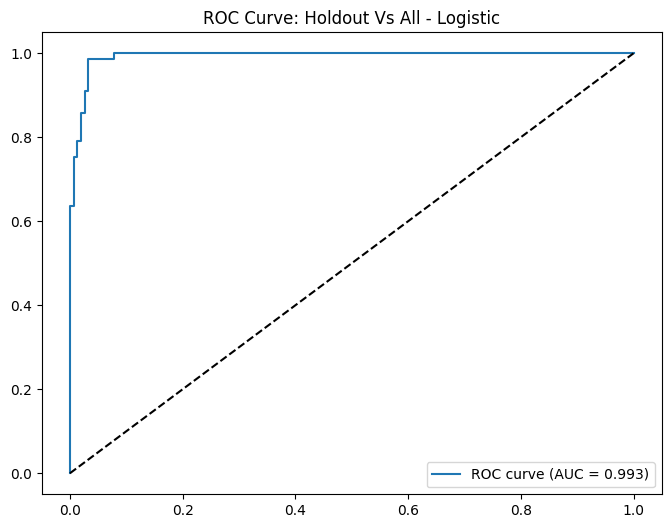

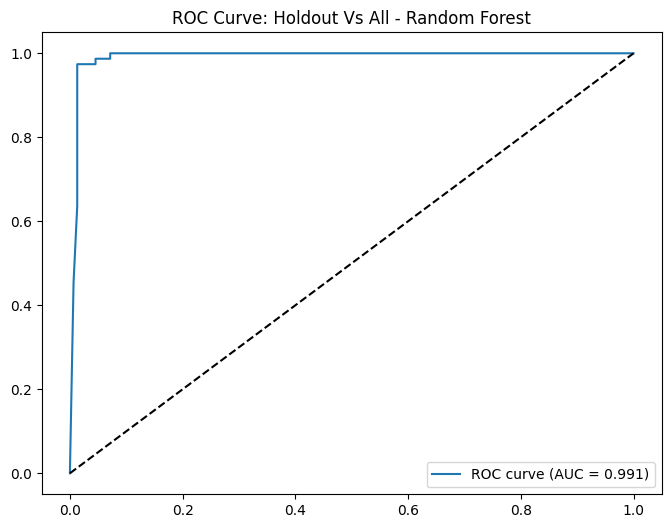

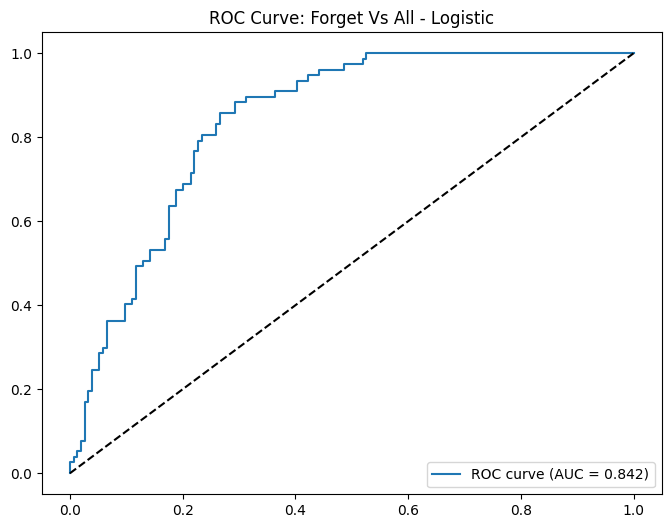

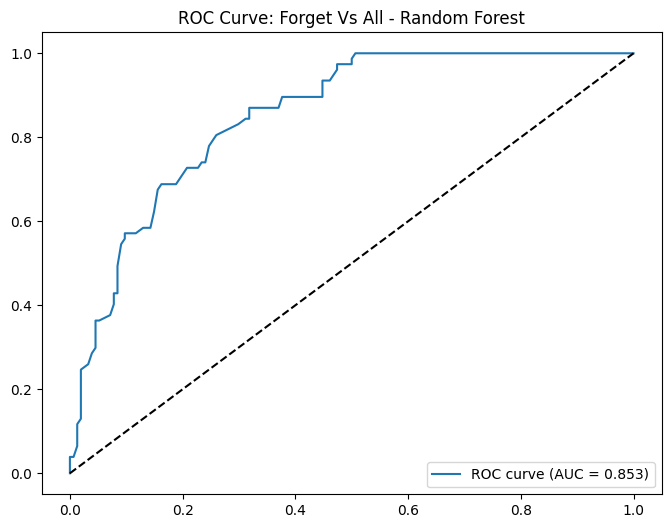

Rephrasing Methods:  33%|███▎      | 1/3 [01:26<02:53, 86.63s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/forget.json already exists. Skipping generation.
Loaded 512 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/120 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/retain.json already exists. Skipping generation.
Loaded 535 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/126 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/holdout.json already exists. Skipping generation.
Loaded 940 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/221 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([512, 15]), retain torch.Size([512, 15]), holdout torch.Size([512, 15])
Training predictors...


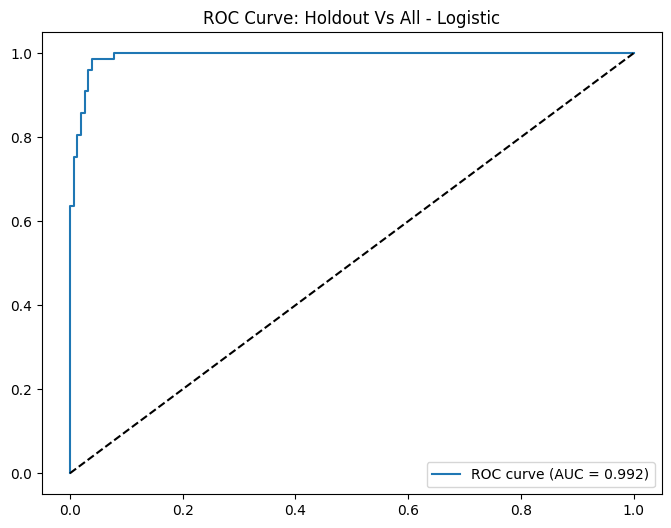

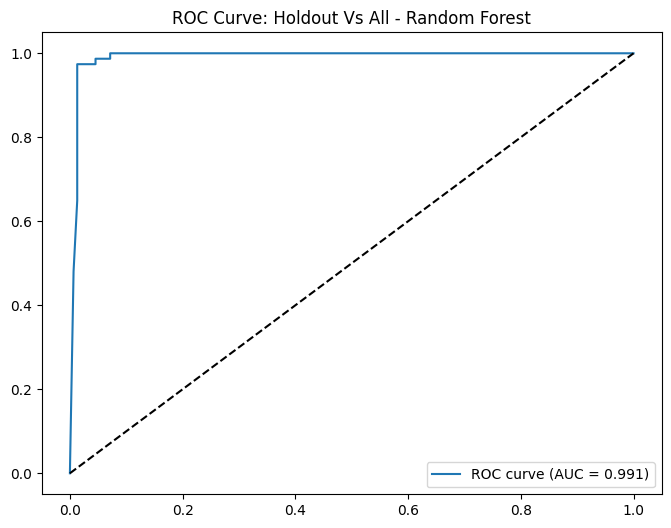

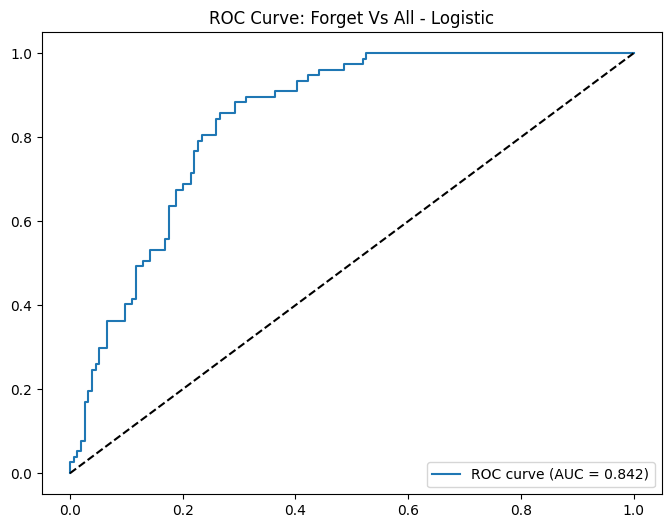

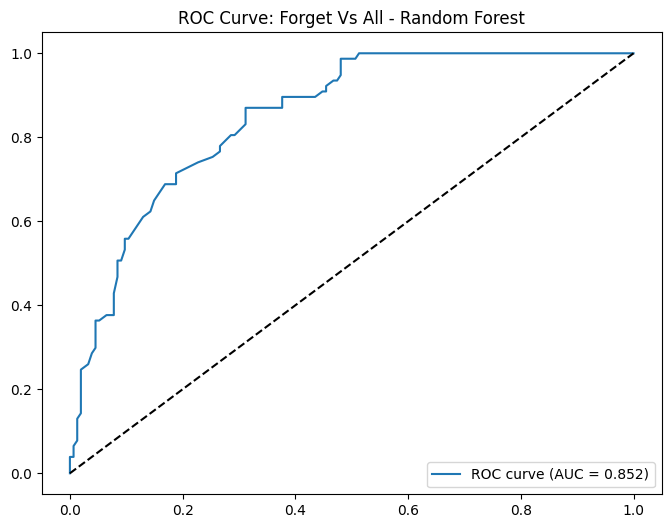

Rephrasing Methods:  67%|██████▋   | 2/3 [02:53<01:27, 87.05s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/forget.json already exists. Skipping generation.
Loaded 512 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/120 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/retain.json already exists. Skipping generation.
Loaded 535 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/126 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/holdout.json already exists. Skipping generation.
Loaded 940 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-WMDP-zephyr-7b-beta/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_wmdp_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/221 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([512, 15]), retain torch.Size([512, 15]), holdout torch.Size([512, 15])
Training predictors...


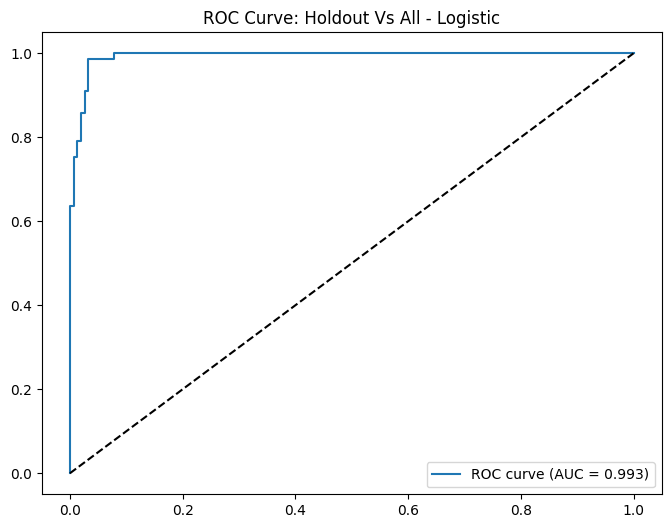

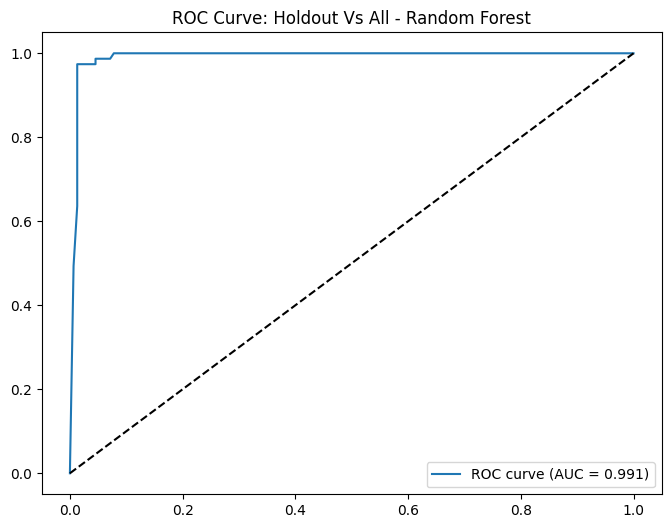

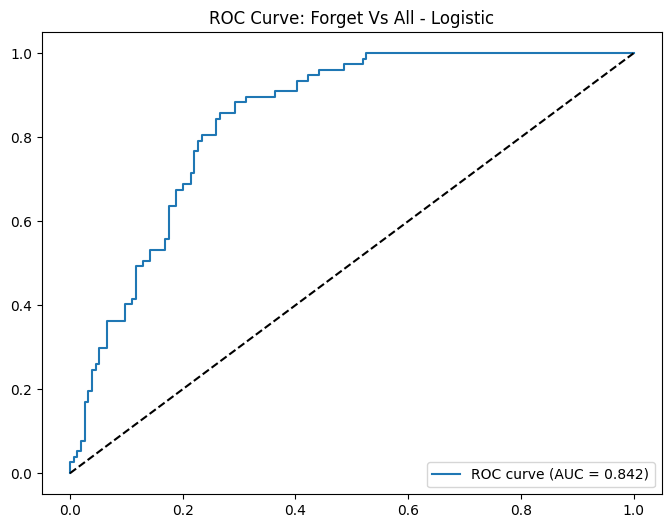

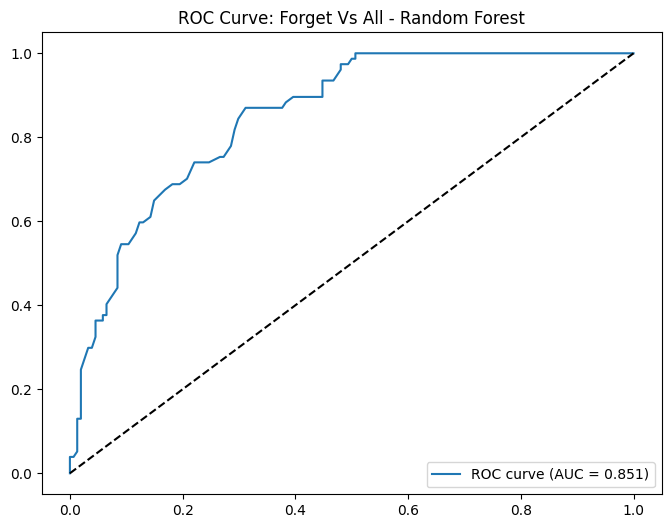

Rephrasing Methods: 100%|██████████| 3/3 [04:20<00:00, 86.71s/it]


Computing baseline metrics...
✅ Evaluation completed for OPTML-Group/SimNPO-WMDP-zephyr-7b-beta on WMDP
💾 Individual result saved to: result_OPTML_Group_SimNPO_WMDP_zephyr_7b_beta_WMDP.json
   Model: OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat
   Benchmark: TOFU

Evaluating OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat on TOFU
Loading model: OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded successfully on device: cuda:0
Loading TOFU data...
TOFU data loaded: 400 forget, 1000 retain, 400 holdout


Rephrasing Methods:   0%|          | 0/3 [00:00<?, ?it/s]

...

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([400, 15]), retain torch.Size([400, 15]), holdout torch.Size([400, 15])
Training predictors...


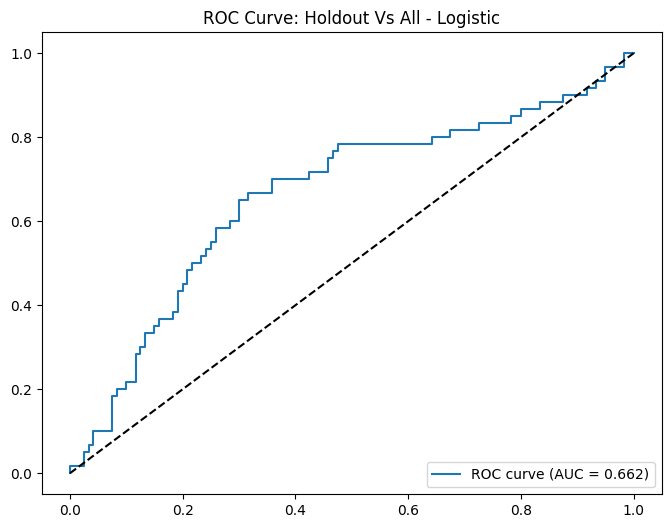

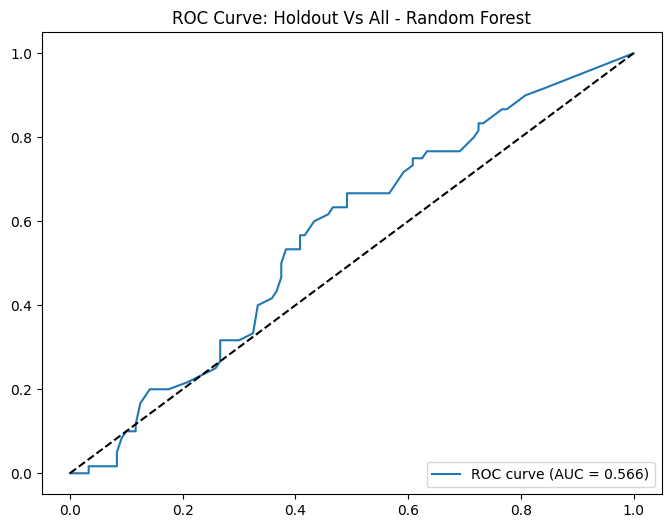

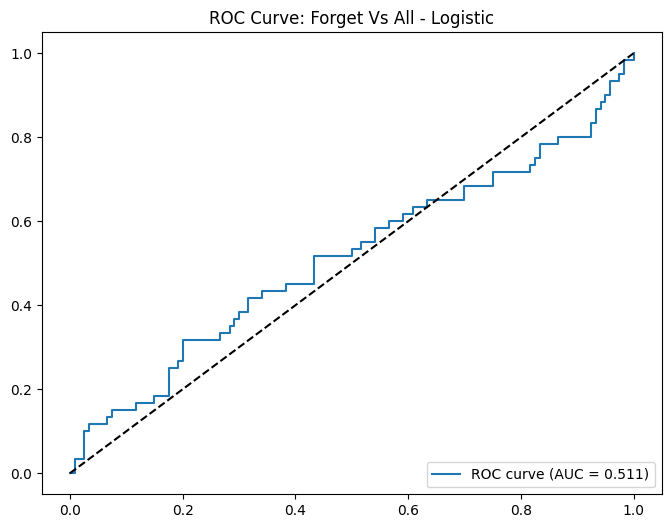

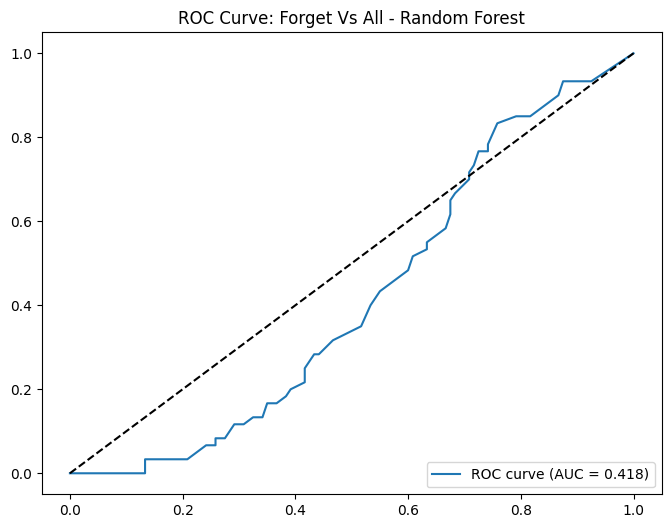

Rephrasing Methods:  33%|███▎      | 1/3 [00:45<01:31, 45.88s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([400, 15]), retain torch.Size([400, 15]), holdout torch.Size([400, 15])
Training predictors...


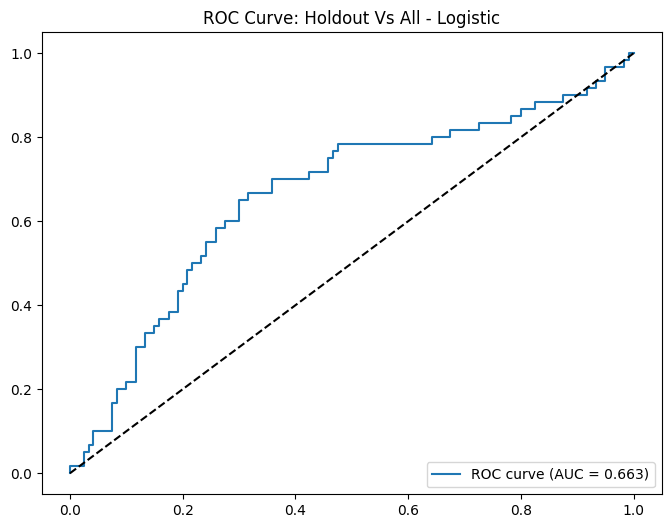

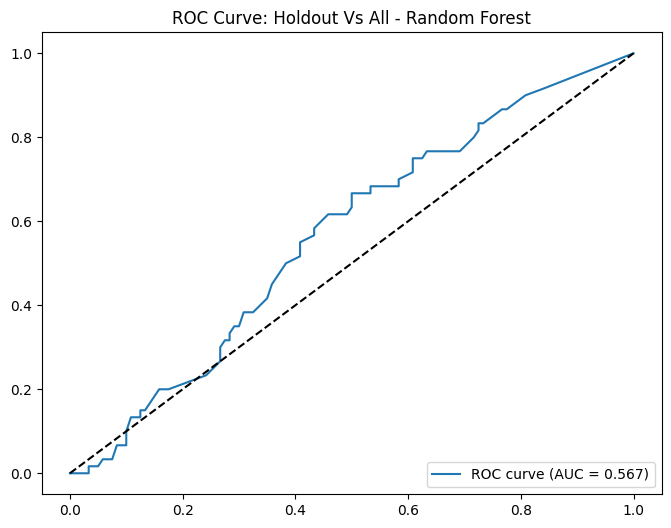

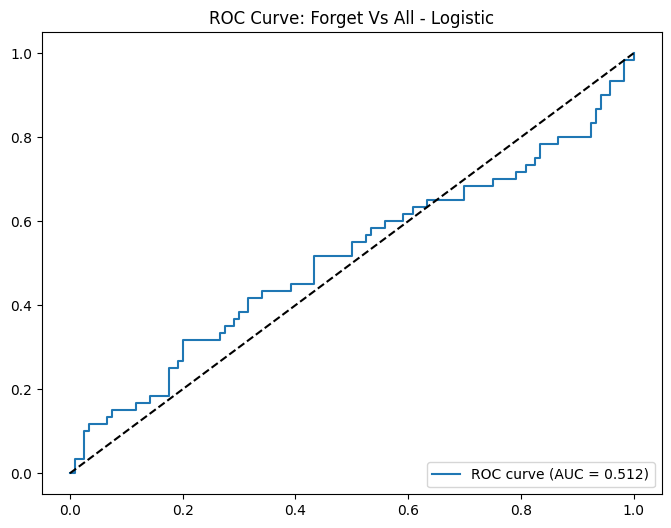

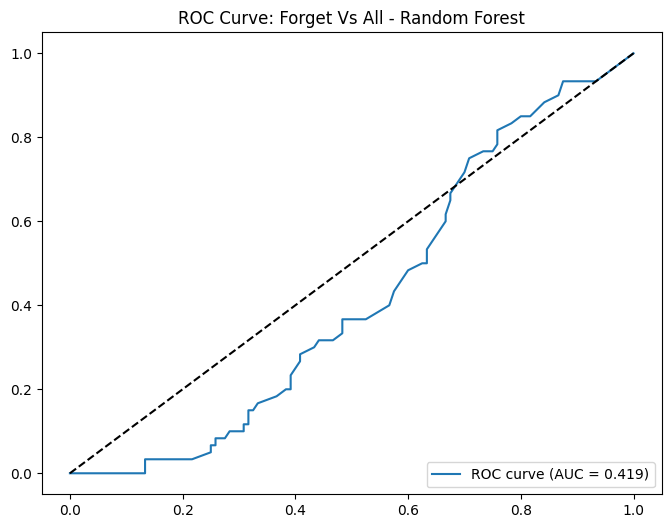

Rephrasing Methods:  67%|██████▋   | 2/3 [01:31<00:45, 45.45s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget05-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([400, 15]), retain torch.Size([400, 15]), holdout torch.Size([400, 15])
Training predictors...


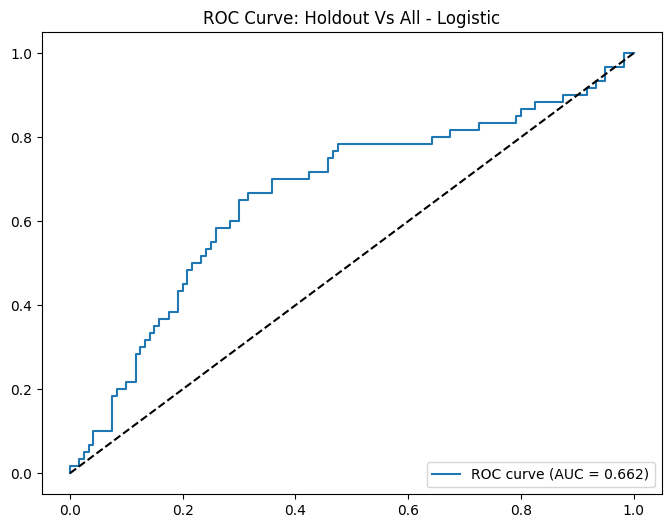

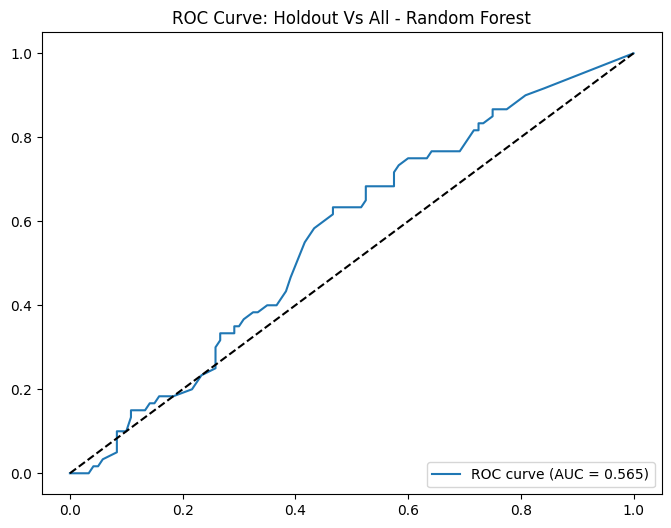

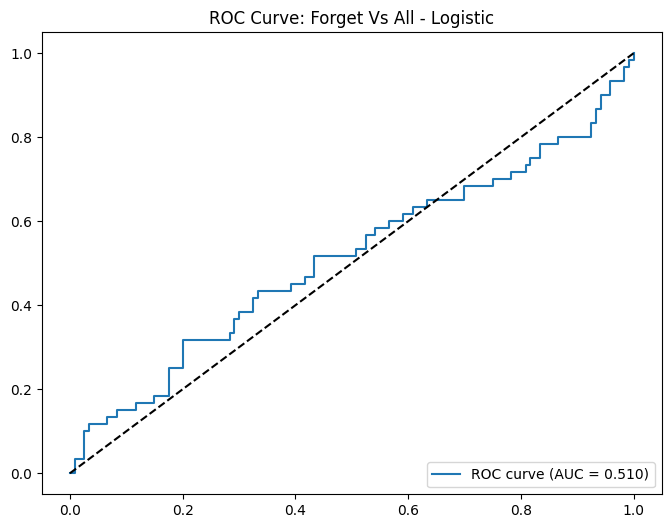

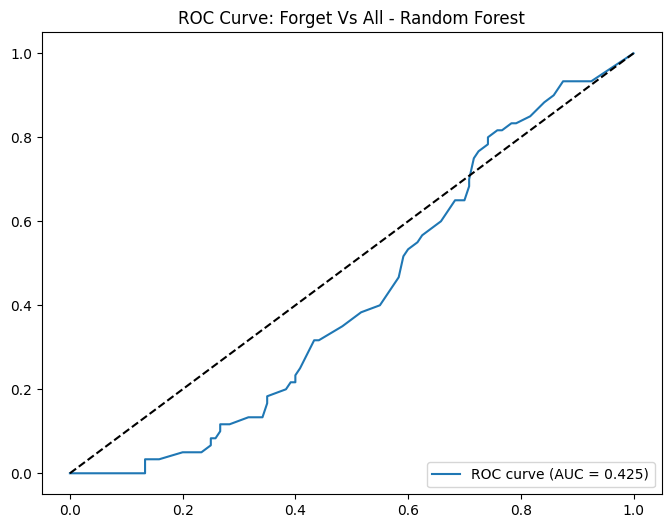

Rephrasing Methods: 100%|██████████| 3/3 [02:17<00:00, 45.70s/it]


Computing baseline metrics...
✅ Evaluation completed for OPTML-Group/SimNPO-TOFU-forget05-Llama-2-7b-chat on TOFU
💾 Individual result saved to: result_OPTML_Group_SimNPO_TOFU_forget05_Llama_2_7b_chat_TOFU.json
   Model: OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat
   Benchmark: TOFU

Evaluating OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat on TOFU
Loading model: OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded successfully on device: cuda:0
Loading TOFU data...
TOFU data loaded: 400 forget, 1000 retain, 400 holdout


Rephrasing Methods:   0%|          | 0/3 [00:00<?, ?it/s]

...

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([400, 15]), retain torch.Size([400, 15]), holdout torch.Size([400, 15])
Training predictors...


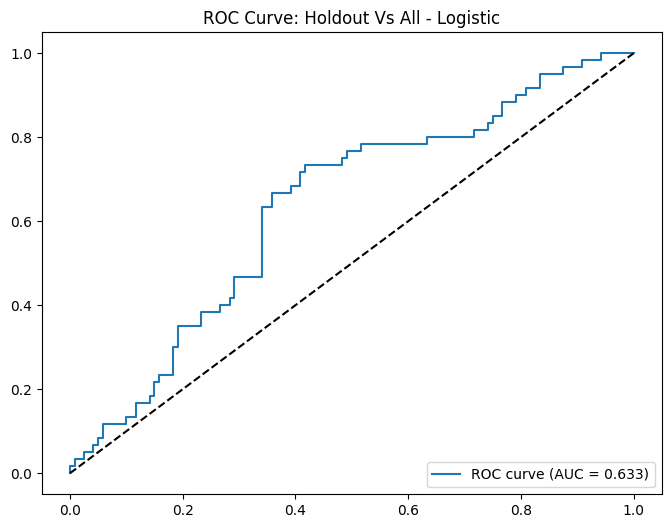

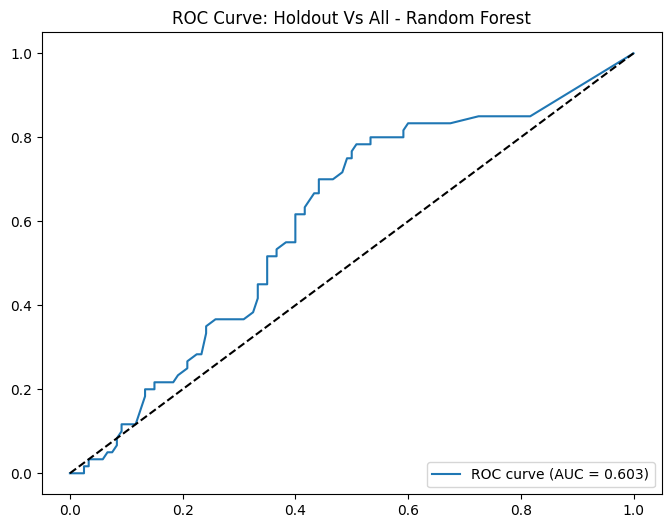

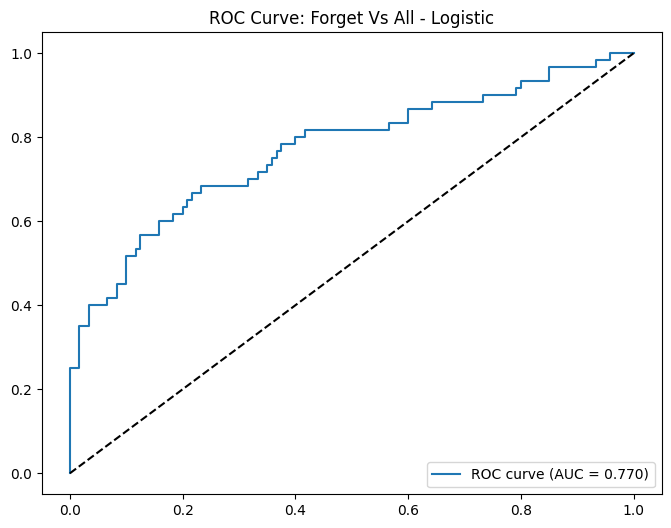

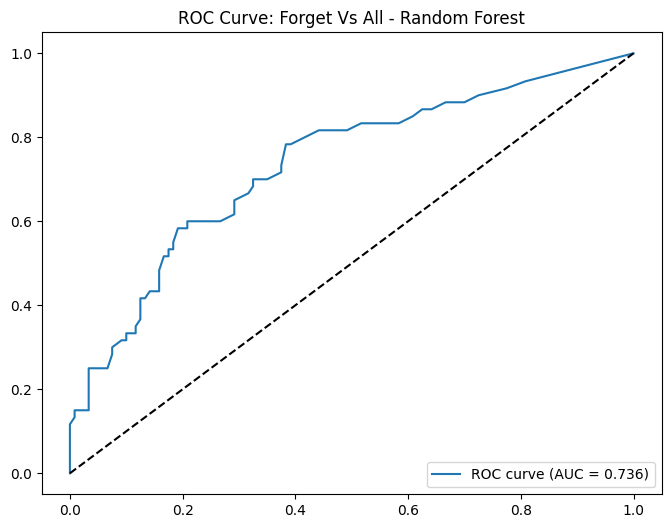

Rephrasing Methods:  33%|███▎      | 1/3 [00:46<01:32, 46.37s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([400, 15]), retain torch.Size([400, 15]), holdout torch.Size([400, 15])
Training predictors...


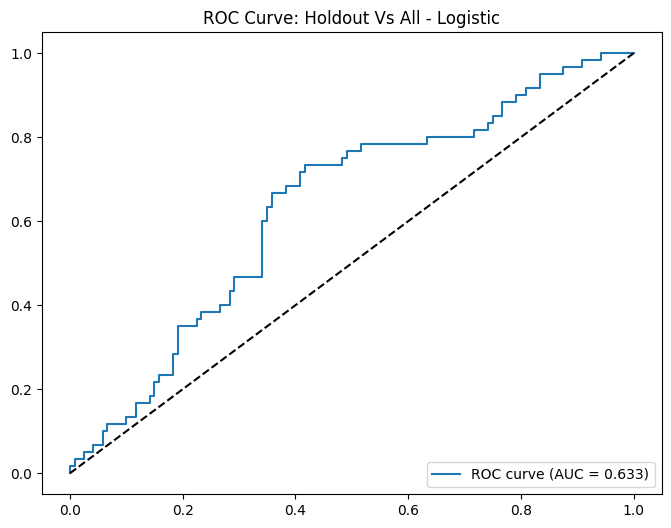

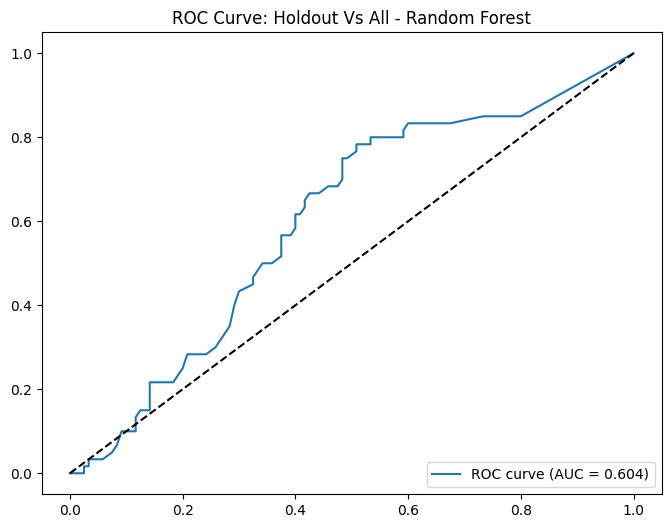

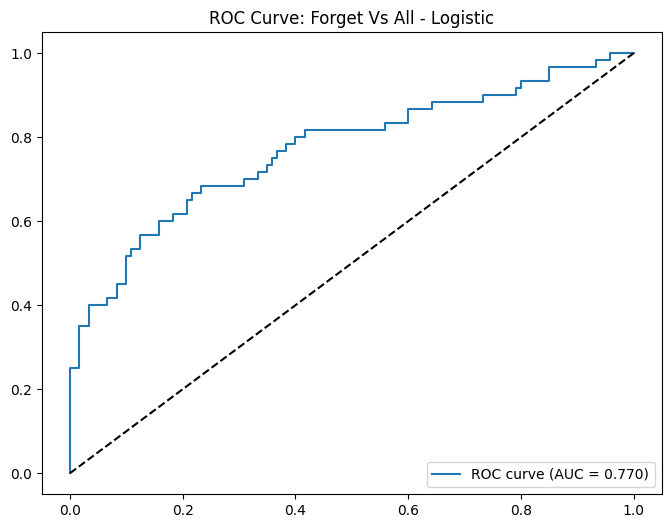

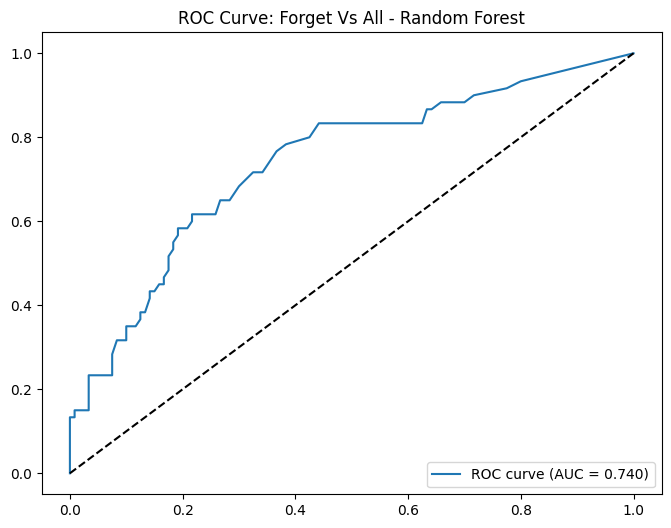

Rephrasing Methods:  67%|██████▋   | 2/3 [01:32<00:45, 46.00s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 400 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([400, 15]), retain torch.Size([400, 15]), holdout torch.Size([400, 15])
Training predictors...


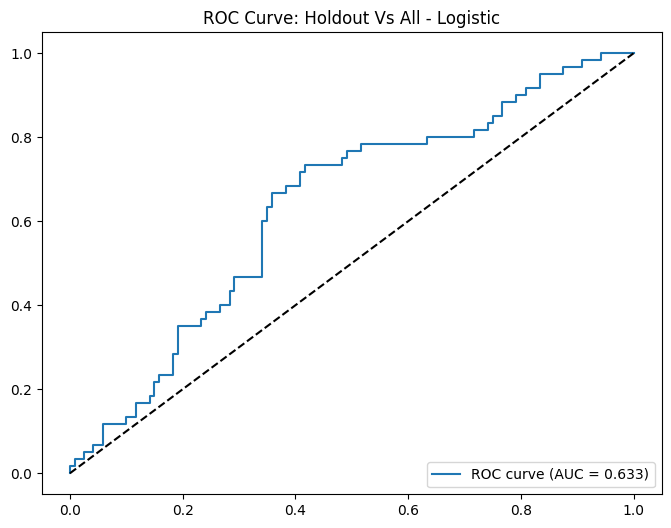

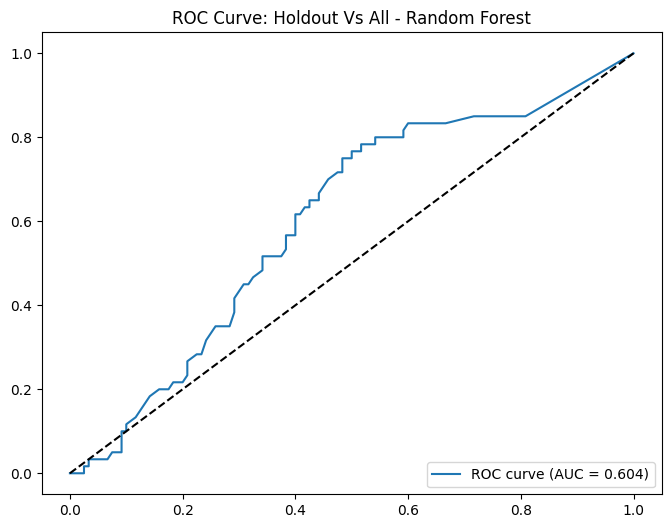

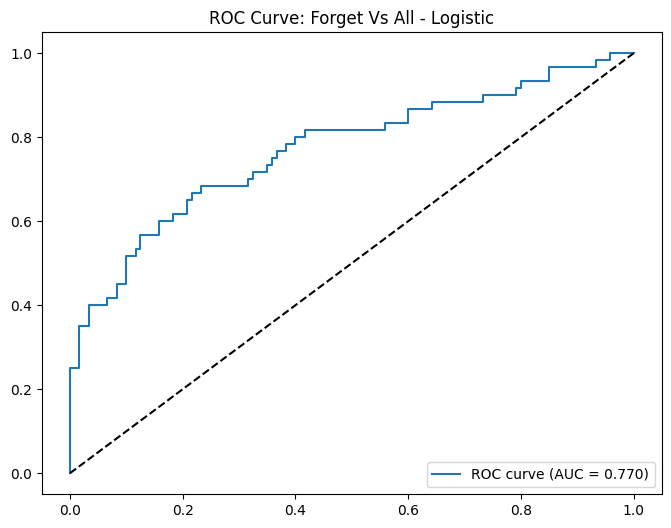

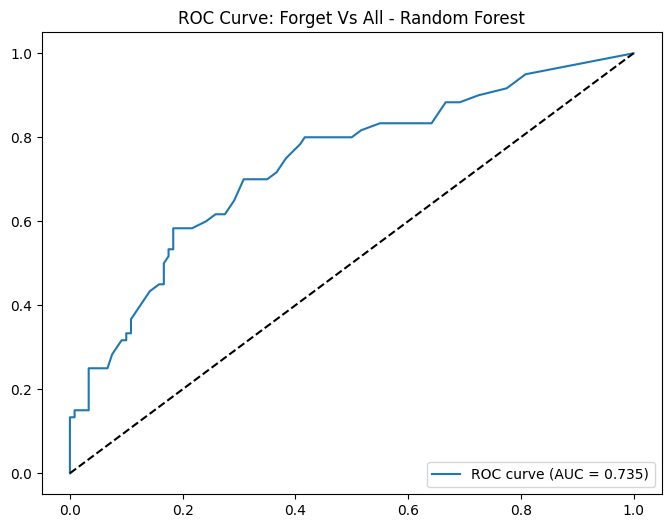

Rephrasing Methods: 100%|██████████| 3/3 [02:19<00:00, 46.40s/it]


Computing baseline metrics...
✅ Evaluation completed for OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat on TOFU
💾 Individual result saved to: result_OPTML_Group_SimNPO_TOFU_forget10_Llama_2_7b_chat_TOFU.json
   Model: OPTML-Group/SimNPO-MUSE-News-llama-2-7b
   Benchmark: MUSE

Evaluating OPTML-Group/SimNPO-MUSE-News-llama-2-7b on MUSE
Loading model: OPTML-Group/SimNPO-MUSE-News-llama-2-7b


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded successfully on device: cuda:0
Loading MUSE data...
MUSE data loaded: 889 forget, 1000 retain, 1000 holdout


Rephrasing Methods:   0%|          | 0/3 [00:00<?, ?it/s]

...

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([888, 15]), retain torch.Size([888, 15]), holdout torch.Size([888, 15])
Training predictors...


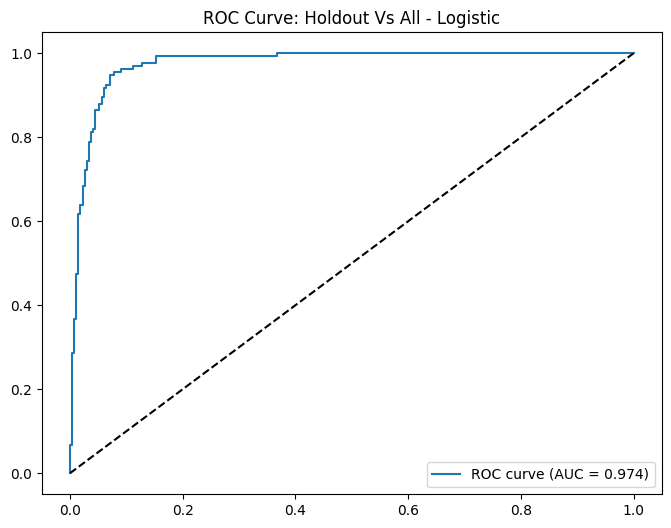

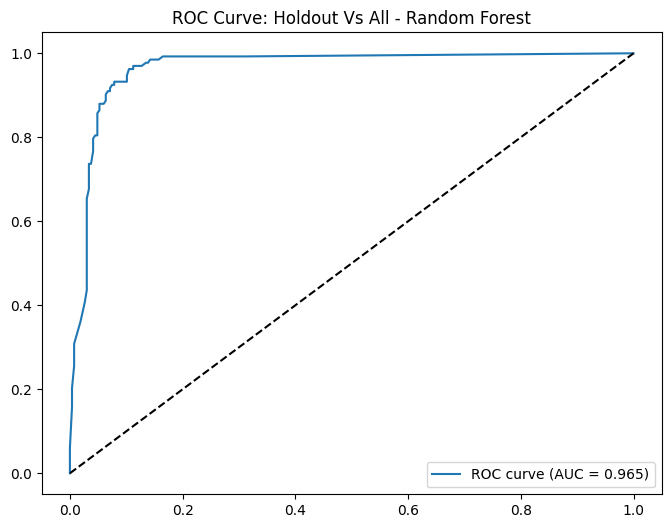

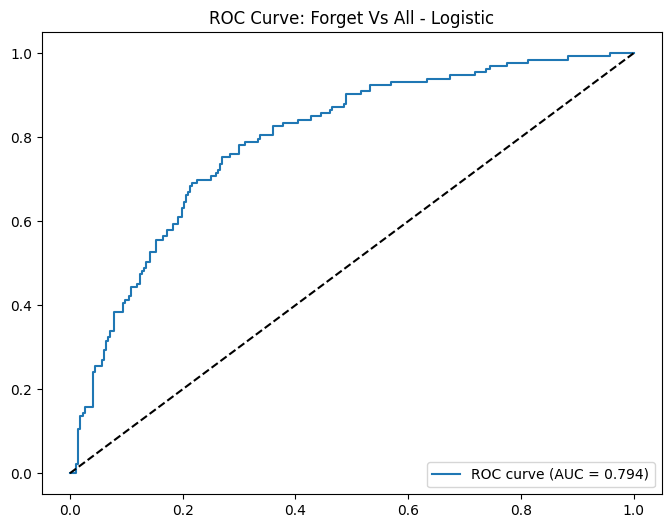

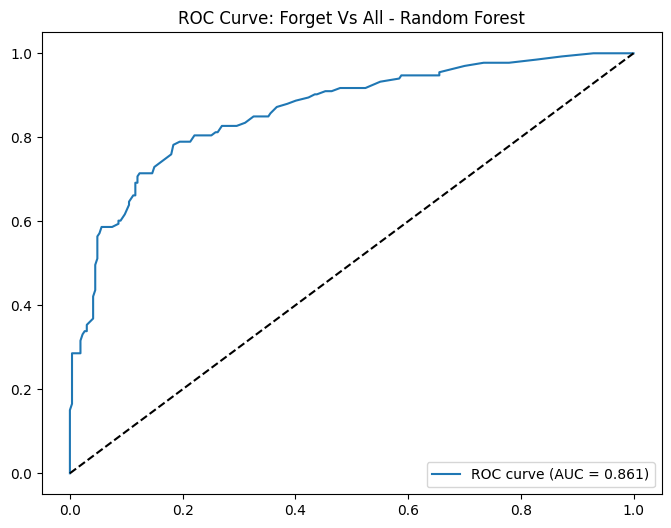

Rephrasing Methods:  33%|███▎      | 1/3 [01:54<03:49, 114.84s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json already exists. Skipping generation.
Loaded 888 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([888, 15]), retain torch.Size([888, 15]), holdout torch.Size([888, 15])
Training predictors...


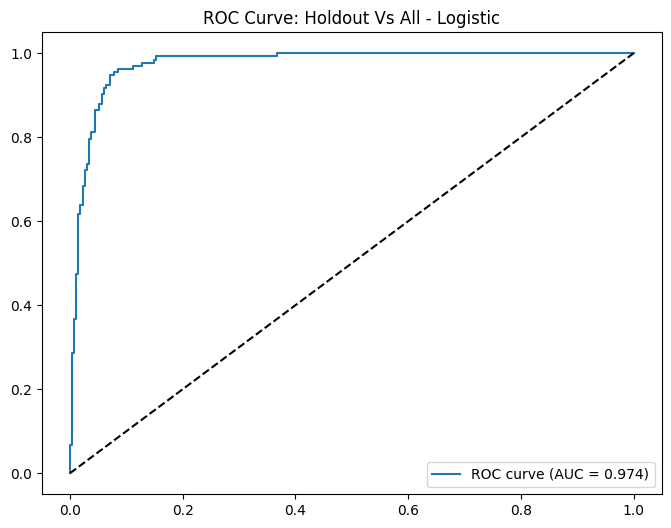

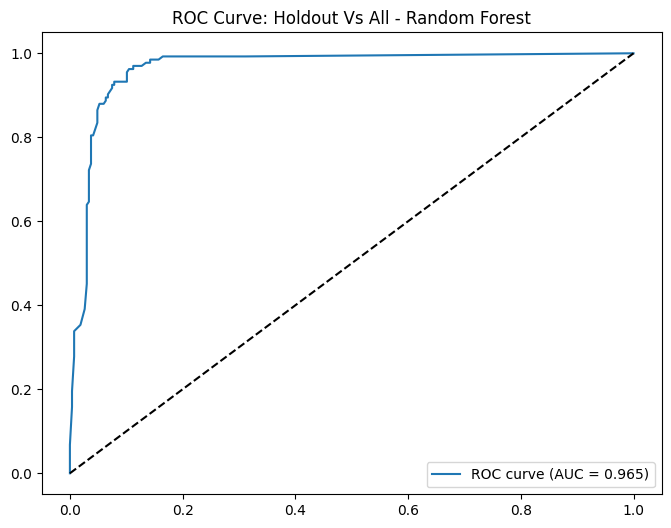

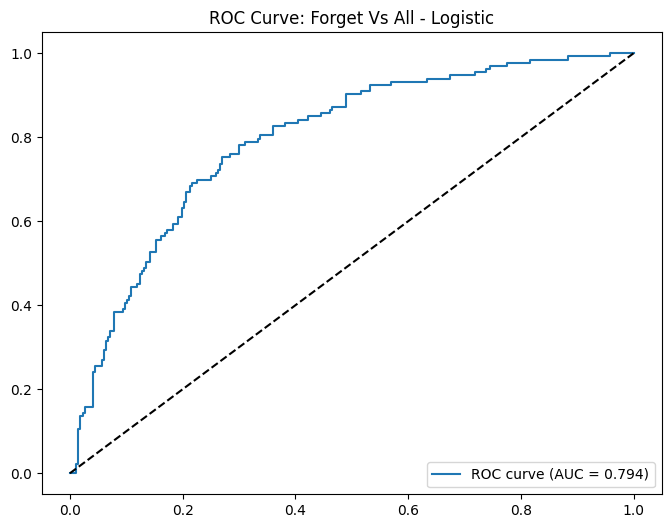

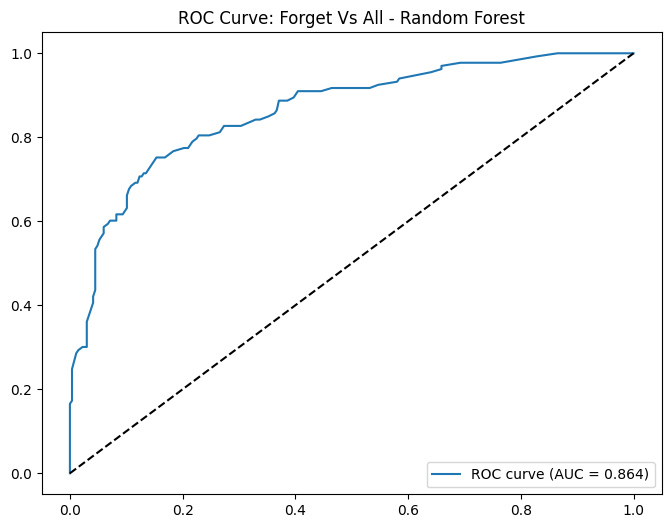

Rephrasing Methods:  67%|██████▋   | 2/3 [03:49<01:54, 114.78s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json already exists. Skipping generation.
Loaded 888 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([888, 15]), retain torch.Size([888, 15]), holdout torch.Size([888, 15])
Training predictors...


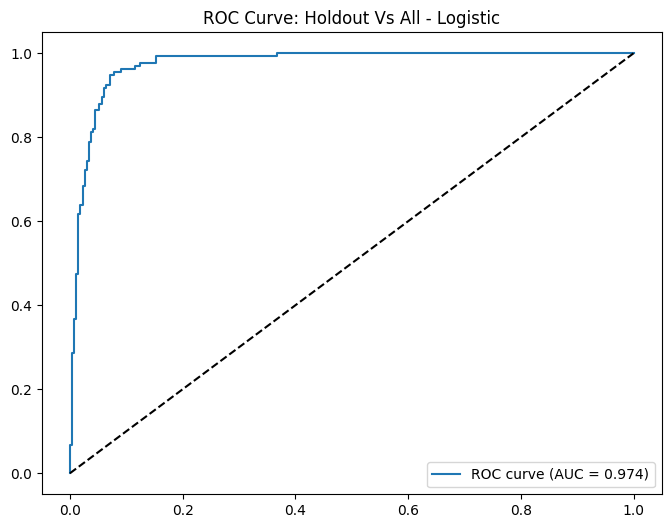

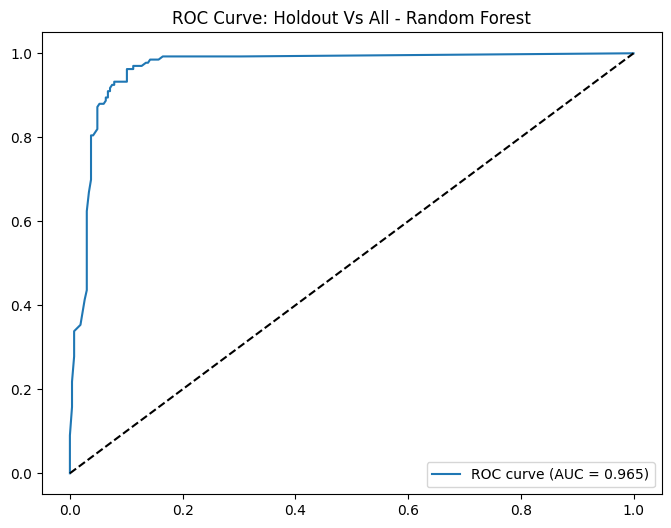

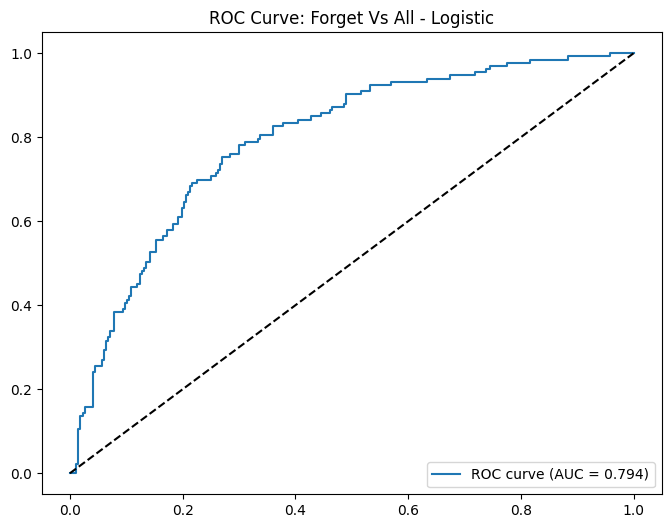

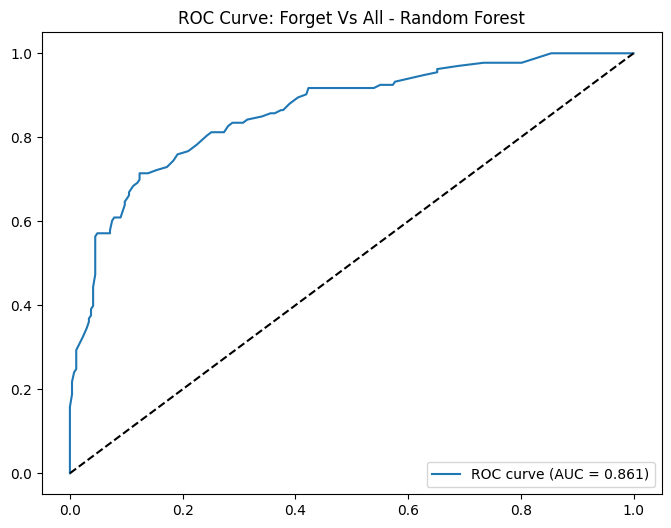

Rephrasing Methods: 100%|██████████| 3/3 [05:45<00:00, 115.17s/it]


Map:   0%|          | 0/889 [00:00<?, ? examples/s]

Filter:   0%|          | 0/889 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/227 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([888, 15]), retain torch.Size([888, 15]), holdout torch.Size([888, 15])
Training predictors...


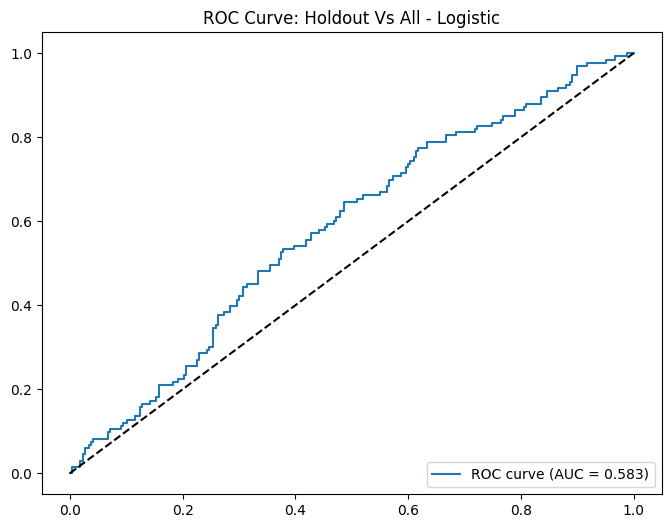

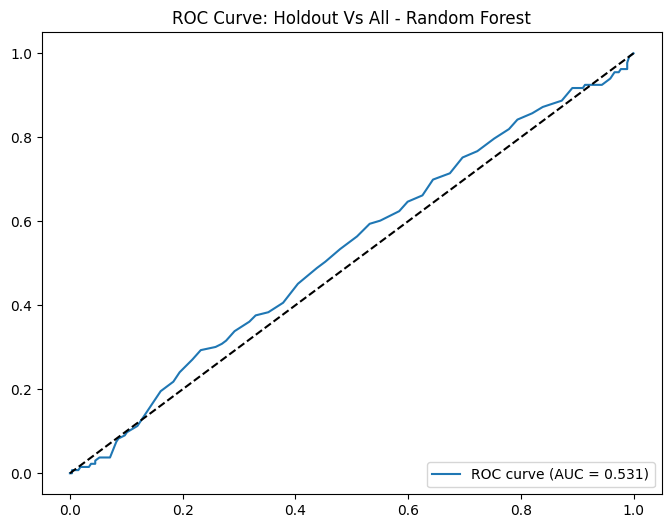

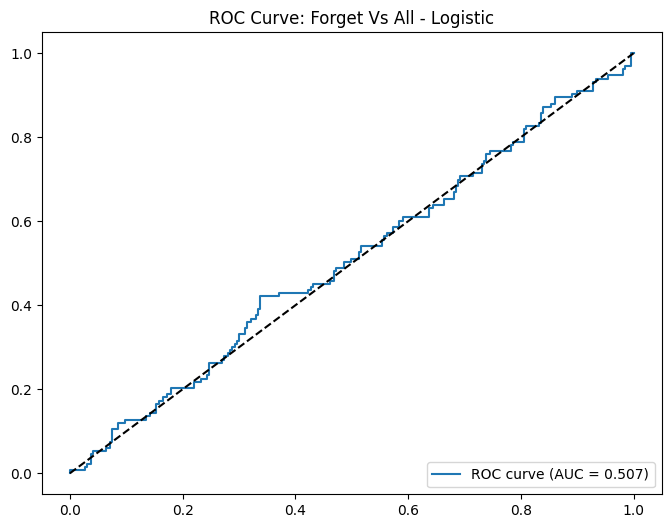

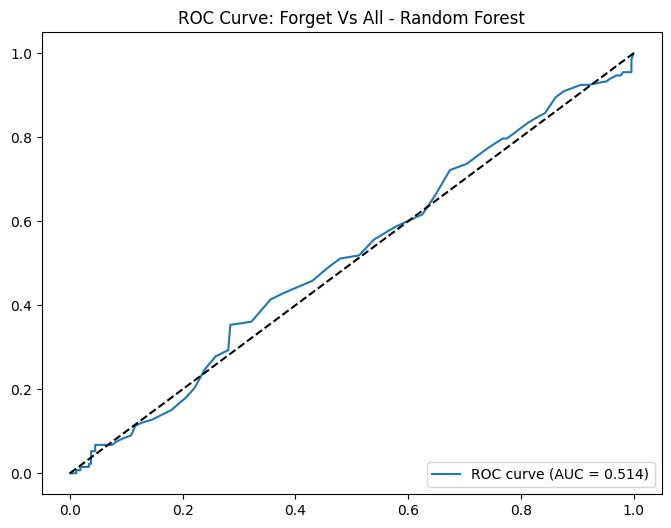

Rephrasing Methods:  33%|███▎      | 1/3 [01:59<03:58, 119.35s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json already exists. Skipping generation.
Loaded 888 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/227 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([888, 15]), retain torch.Size([888, 15]), holdout torch.Size([888, 15])
Training predictors...


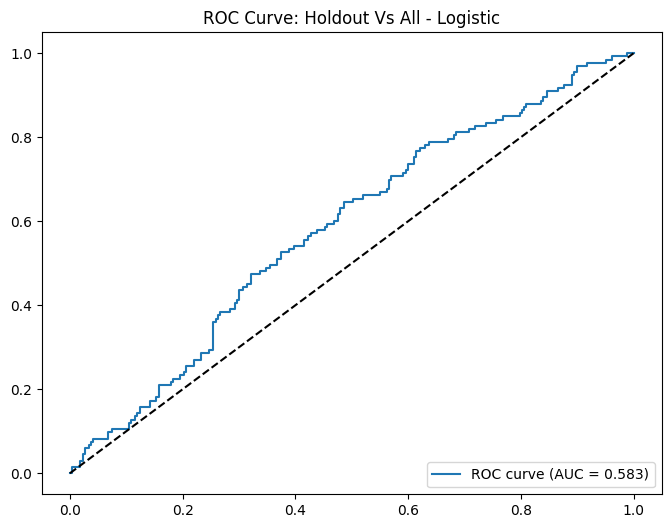

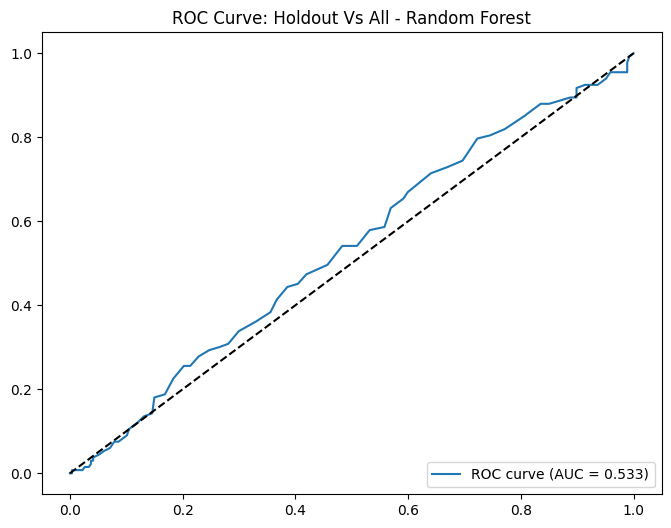

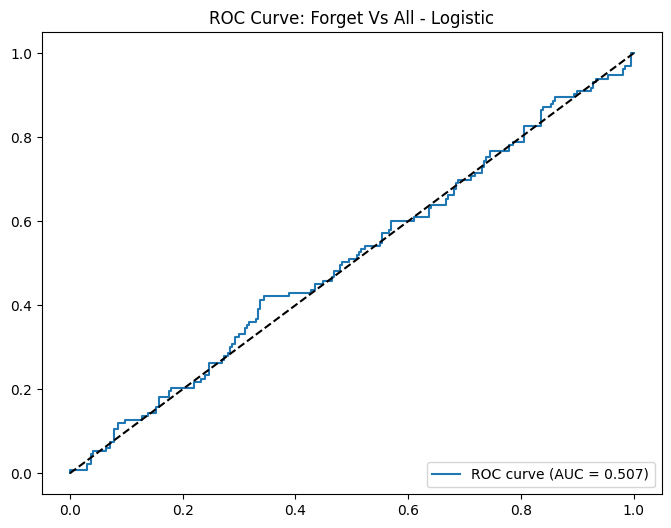

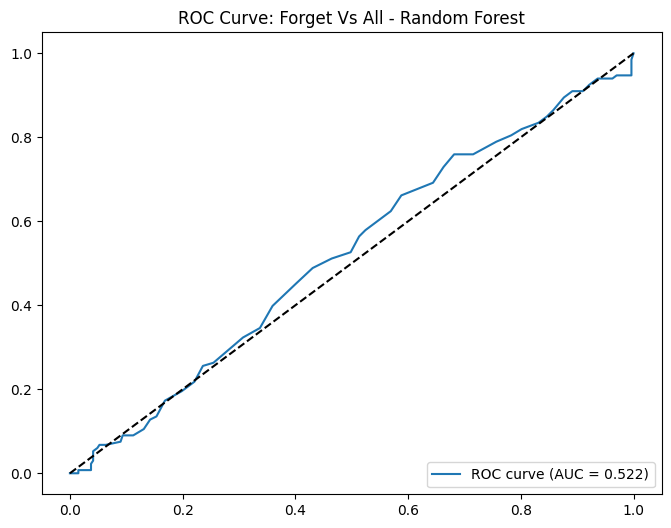

Rephrasing Methods:  67%|██████▋   | 2/3 [03:56<01:58, 118.34s/it]

Running ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json already exists. Skipping generation.
Loaded 888 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/225 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-Books-llama-2-7b/top_k_20_n_tokens_0.1_k_neighbors_15_token_embedding_proximity/exp_muse_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/227 [00:00<?, ?it/s]

Feature tensors: forget torch.Size([888, 15]), retain torch.Size([888, 15]), holdout torch.Size([888, 15])
Training predictors...


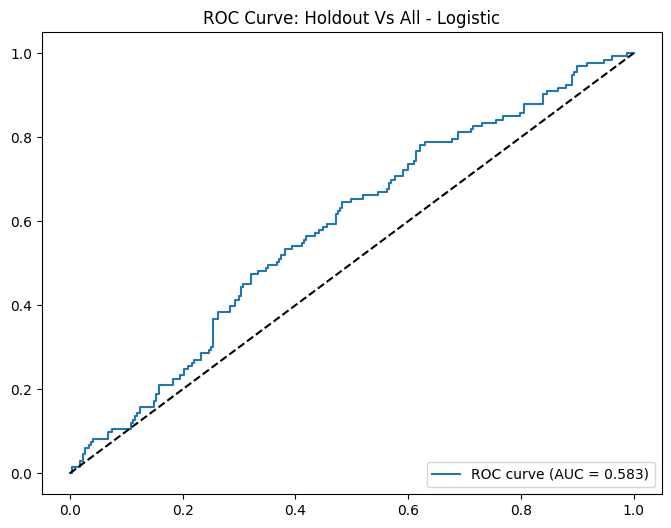

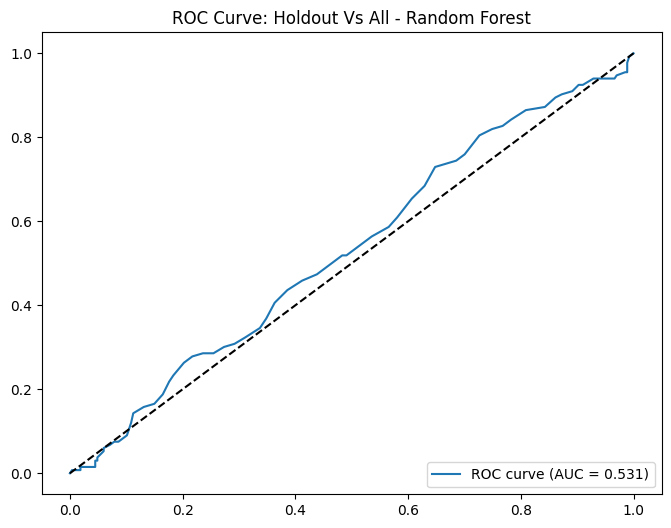

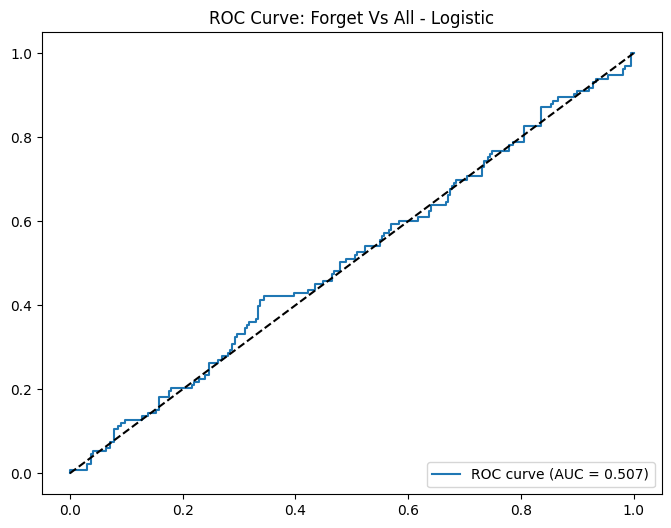

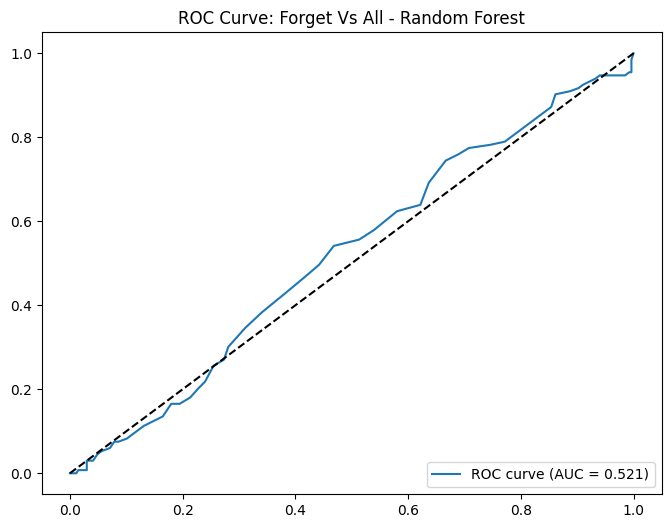

Rephrasing Methods: 100%|██████████| 3/3 [05:55<00:00, 118.66s/it]


Map:   0%|          | 0/889 [00:00<?, ? examples/s]

Filter:   0%|          | 0/889 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Computing baseline metrics...
✅ Evaluation completed for OPTML-Group/SimNPO-MUSE-Books-llama-2-7b on MUSE
💾 Individual result saved to: result_OPTML_Group_SimNPO_MUSE_Books_llama_2_7b_MUSE.json

🎉 Comprehensive experiments completed!
   Successful evaluations: 6/18
   Loaded from cache: 1
   Newly evaluated: 5
Experiment results saved to: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/all_experiment_results.json


[{'model_name': 'LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8',
  'benchmark': 'WMDP',
  'method': 'ELM',
  'rephrasing_results': [{'neighbor_method': 'token_embedding_proximity',
    'classifier': 'logistic',
    'Retain vs All AUC': 0.9875534981221068,
    'Holdout vs All AUC': 1.0,
    'Forget vs All AUC': 0.9525722770547645,
    'Multi-class AUC': 0.9948923906653375,
    'Retain_vs_All_auc_at_1_fp': 0.8691588785046729,
    'Forget_vs_All_auc_at_1_fp': 0.6448598130841121,
    'Holdout_vs_All_auc_at_1_fp': 1.0,
    'binary_feature_importance': {'holdout_vs_all_logistic': '                feature  importance\n3     min_neighbor_loss    0.203383\n1    mean_neighbor_loss    0.199598\n0         original_loss    0.183361\n2     max_neighbor_loss    0.178665\n7    max_loss_increment    0.039975\n12      loss_volatility    0.038669\n5              loss_std    0.034122\n11    gradient_variance    0.027473\n6   mean_loss_increment    0.027224\n10         max_gradient    0.024667\n4         lo

In [22]:
# Run the comprehensive experiments
print("🚀 Starting comprehensive evaluation across all models and benchmarks...")
print("This may take some time depending on available computational resources.")

# Configure experiment parameters
MAX_MODELS_PER_FAMILY = 5  # Limit for computational efficiency

print(f"Configuration:")
print(f"  Max models per family: {MAX_MODELS_PER_FAMILY}")
print(f"  Dataset subset size: {SUBSET_SIZE}")
print(f"  Expected total evaluations: ~{MAX_MODELS_PER_FAMILY * 3 * 2}")  # families * benchmarks * classifiers

# Run experiments with DataManager
all_results = run_comprehensive_experiments(
    max_models_per_family=MAX_MODELS_PER_FAMILY,
    subset_size=SUBSET_SIZE,
    force_rerun= DEBUG,  # Set to True to rerun all experiments
    data_manager=dm
)
all_results

In [23]:
# Alternative: Load existing results if experiments were already run
print("💡 Alternative options:")
print("   1. Run with force_rerun=True to rerun all experiments")
print("   2. Load existing individual results from DataManager")
print("   3. Run a subset of models for testing")

# Example: Load existing results if available
existing_results = dm.load_all_individual_results()
if len(existing_results) > 0:
    print(f"\n✅ Found {len(existing_results)} existing results!")
    print("   You can use these for analysis or run additional experiments")
    
    # Optionally use existing results instead of running new experiments
    # all_results = existing_results
else:
    print("\n📝 No existing results found. Will run new experiments.")

# Example: Load specific model result
# specific_result = dm.load_individual_result("LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8", "WMDP")
# if specific_result:
#     print(f"Loaded specific result: {specific_result['model_name']} on {specific_result['benchmark']}")

💡 Alternative options:
   1. Run with force_rerun=True to rerun all experiments
   2. Load existing individual results from DataManager
   3. Run a subset of models for testing
Found 6 individual result files
  ✅ Loaded: result_LLM_GAT_llama_3_8b_instruct_elm_checkpoint_8_WMDP.json
  ✅ Loaded: result_OPTML_Group_SimNPO_MUSE_Books_llama_2_7b_MUSE.json
  ✅ Loaded: result_OPTML_Group_SimNPO_MUSE_News_llama_2_7b_MUSE.json
  ✅ Loaded: result_OPTML_Group_SimNPO_TOFU_forget05_Llama_2_7b_chat_TOFU.json
  ✅ Loaded: result_OPTML_Group_SimNPO_TOFU_forget10_Llama_2_7b_chat_TOFU.json
  ✅ Loaded: result_OPTML_Group_SimNPO_WMDP_zephyr_7b_beta_WMDP.json
Successfully loaded 6 individual results

✅ Found 6 existing results!
   You can use these for analysis or run additional experiments


In [24]:
def run_or_load_experiments(force_rerun=False, max_models_per_family=5, subset_size=1000):
    """
    Convenience function to either run new experiments or load existing results.
    
    Args:
        force_rerun: If True, run experiments even if results exist
        max_models_per_family: Maximum models to test per family
        subset_size: Dataset subset size
        
    Returns:
        list: All experiment results
    """
    print(f"🔧 Experiment Manager")
    print(f"   Force rerun: {force_rerun}")
    print(f"   Max models per family: {max_models_per_family}")
    print(f"   Subset size: {subset_size}")
    
    if not force_rerun:
        # Try to load existing results first
        existing_results = dm.load_all_individual_results()
        if len(existing_results) > 0:
            print(f"\n✅ Found {len(existing_results)} existing results!")
            
            # Calculate how many experiments we expect
            expected_total = sum(len(models[:max_models_per_family]) for models in MODEL_CONFIGS.values())
            print(f"   Expected total experiments: {expected_total}")
            print(f"   Found: {len(existing_results)}")
            
            if len(existing_results) >= expected_total:
                print("   📋 All experiments appear to be complete. Using existing results.")
                return existing_results
            else:
                print(f"   ⚠️ Only {len(existing_results)}/{expected_total} experiments found.")
                print("   🚀 Running remaining experiments...")
    
    # Run experiments (new or remaining)
    all_results = run_comprehensive_experiments(
        max_models_per_family=max_models_per_family,
        subset_size=subset_size,
        force_rerun=force_rerun,
        data_manager=dm
    )
    
    return all_results

# Example usage:
# all_results = run_or_load_experiments(force_rerun=False, max_models_per_family=2, subset_size=100)
print("✅ Experiment management function defined")

✅ Experiment management function defined


In [25]:
def display_tables(analysis_results):
    """
    Display formatted tables for analysis results
    
    Args:
        analysis_results: Dictionary containing table dataframes and analysis
    """
    print("=" * 80)
    print("📊 TABLE 2: AGGREGATE COMPARISON OF UNLEARNING EVALUATION METRICS")
    print("=" * 80)
    
    # Format Table 2 for display
    table2 = analysis_results['table2']
    
    # Create a more readable format
    print("\nMethod Comparison (AUC Scores):")
    print("-" * 70)
    print(f"{'Method':<25} {'Retain vs All':<15} {'Forget vs All':<15} {'Multi-class':<15}")
    print("-" * 70)
    
    for _, row in table2.iterrows():
        method = row['Method']
        retain_auc = f"{row['Retain_vs_All_AUC']:.3f}"
        forget_auc = f"{row['Forget_vs_All_AUC']:.3f}" 
        multi_auc = f"{row['Multi_class_AUC']:.3f}"
        print(f"{method:<25} {retain_auc:<15} {forget_auc:<15} {multi_auc:<15}")
    
    print("\n" + "=" * 80)
    print("📊 TABLE 3: MODEL FAMILY COMPARISON")
    print("=" * 80)
    
    # Format Table 3 for display
    table3 = analysis_results['table3']
    
    print("\nModel Family Performance Breakdown:")
    print("-" * 120)
    print(f"{'Family':<15} {'Method':<20} {'Classifier':<12} {'AUC':<8} {'Accuracy':<10} {'F1':<8} {'Retain vs All':<12} {'Multi-class':<12}")
    print("-" * 120)
    
    for (family, method, classifier), row in table3.iterrows():
        auc = f"{row['AUC']:.3f}"
        acc = f"{row['Accuracy']:.3f}"
        f1 = f"{row['F1']:.3f}"
        retain = f"{row['Retain_vs_All']:.3f}"
        multi = f"{row['Multi_class']:.3f}"
        print(f"{family:<15} {method:<20} {classifier:<12} {auc:<8} {acc:<10} {f1:<8} {retain:<12} {multi:<12}")
    
    print("\n" + "=" * 80)
    print("📊 TABLE 4: DETAILED INDIVIDUAL RESULTS")
    print("=" * 80)
    
    # Format Table 4 for display (showing top 20 results)
    table4 = analysis_results['table4'].sort_values('AUC', ascending=False)
    
    print("\nTop Individual Model Results:")
    print("-" * 140)
    print(f"{'Model':<40} {'Benchmark':<10} {'Method':<15} {'Classifier':<12} {'AUC':<8} {'F1':<8} {'Retain vs All':<12} {'Multi-class':<12}")
    print("-" * 140)
    
    for _, row in table4.head(20).iterrows():
        model = row['Model'][:37] + "..." if len(row['Model']) > 40 else row['Model']
        benchmark = row['Benchmark']
        method = row['Method']
        classifier = row['Classifier']
        auc = f"{row['AUC']:.3f}"
        f1 = f"{row['F1']:.3f}"
        retain = f"{row['Retain_vs_All']:.3f}"
        multi = f"{row['Multi_class']:.3f}"
        print(f"{model:<40} {benchmark:<10} {method:<15} {classifier:<12} {auc:<8} {f1:<8} {retain:<12} {multi:<12}")
    
    # Summary statistics
    print("\n" + "=" * 80)
    print("📈 SUMMARY STATISTICS")
    print("=" * 80)
    
    stats = analysis_results['summary_stats']
    print(f"Total Evaluations: {stats['total_evaluations']}")
    print(f"Unique Models: {stats['unique_models']}")
    print(f"Unique Benchmarks: {stats['unique_benchmarks']}")
    print(f"Average AUC (LogReg): {stats['avg_auc_logreg']:.3f}")
    print(f"Average AUC (Tree): {stats['avg_auc_tree']:.3f}")
    
    # Performance comparison
    detailed_df = analysis_results['detailed_results']
    
    print(f"\nBest Performance by Classifier:")
    best_logreg = detailed_df[detailed_df['Classifier']=='LogReg']['AUC'].max()
    best_tree = detailed_df[detailed_df['Classifier']=='Tree']['AUC'].max()
    print(f"  LogReg Best AUC: {best_logreg:.3f}")
    print(f"  Tree Best AUC: {best_tree:.3f}")
    
    print(f"\nPerformance by Benchmark:")
    for benchmark in detailed_df['Benchmark'].unique():
        bench_data = detailed_df[detailed_df['Benchmark'] == benchmark]
        avg_auc = bench_data['AUC'].mean()
        print(f"  {benchmark}: {avg_auc:.3f}")
    
    print(f"\nPerformance by Method:")
    for method in detailed_df['Method'].unique():
        method_data = detailed_df[detailed_df['Method'] == method]
        avg_auc = method_data['AUC'].mean()
        count = len(method_data)
        print(f"  {method}: {avg_auc:.3f} (n={count})")
    
    print("\n" + "=" * 80)

In [26]:
all_results

[{'model_name': 'LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8',
  'benchmark': 'WMDP',
  'method': 'ELM',
  'rephrasing_results': [{'neighbor_method': 'token_embedding_proximity',
    'classifier': 'logistic',
    'Retain vs All AUC': 0.9875534981221068,
    'Holdout vs All AUC': 1.0,
    'Forget vs All AUC': 0.9525722770547645,
    'Multi-class AUC': 0.9948923906653375,
    'Retain_vs_All_auc_at_1_fp': 0.8691588785046729,
    'Forget_vs_All_auc_at_1_fp': 0.6448598130841121,
    'Holdout_vs_All_auc_at_1_fp': 1.0,
    'binary_feature_importance': {'holdout_vs_all_logistic': '                feature  importance\n3     min_neighbor_loss    0.203383\n1    mean_neighbor_loss    0.199598\n0         original_loss    0.183361\n2     max_neighbor_loss    0.178665\n7    max_loss_increment    0.039975\n12      loss_volatility    0.038669\n5              loss_std    0.034122\n11    gradient_variance    0.027473\n6   mean_loss_increment    0.027224\n10         max_gradient    0.024667\n4         lo

In [40]:
# Debug: Check for problematic values in the data
print("Checking data types and sample values...")
print(f"all_results length: {len(all_results)}")
print(f"First result keys: {list(all_results[0].keys())}")

# Check for any string 'N/A' values in the first result
for key, value in all_results[0].items():
    if isinstance(value, dict):
        for k, v in value.items():
            if isinstance(v, str) and v == 'N/A':
                print(f"Found N/A string in {key}.{k}")
            elif isinstance(v, dict):
                for k2, v2 in v.items():
                    if isinstance(v2, str) and v2 == 'N/A':
                        print(f"Found N/A string in {key}.{k}.{k2}")
    elif isinstance(value, str) and value == 'N/A':
        print(f"Found N/A string in {key}")

# Let's also check the baselines structure
if 'baselines' in all_results[0]:
    print("Baseline structure:")
    for method, data in all_results[0]['baselines'].items():
        if isinstance(data, dict):
            print(f"  {method}: {list(data.keys())}")
            for k, v in data.items():
                if isinstance(v, str) and ('N/A' in str(v)):
                    print(f"    Found problematic value: {k}={v}")
        else:
            print(f"  {method}: {data} (not computed)")

Checking data types and sample values...
all_results length: 6
First result keys: ['model_name', 'benchmark', 'method', 'rephrasing_results', 'binary_comparisons', 'feature_importance', 'baselines']
Baseline structure:
  zlib_compression: 0 (not computed)
  min_k_percent: 0 (not computed)
  min_k_pp_percent: 0 (not computed)
  rouge_l_f1: 0 (not computed)


In [41]:
def display_tables(analysis_results):
    """
    Display formatted tables for analysis results
    
    Args:
        analysis_results: Dictionary containing table dataframes and analysis
    """
    print("=" * 80)
    print("📊 TABLE 2: AGGREGATE COMPARISON OF UNLEARNING EVALUATION METRICS")
    print("=" * 80)
    
    # Format Table 2 for display
    table2 = analysis_results['table2']
    
    # Create a more readable format
    print("\nMethod Comparison (AUC Scores):")
    print("-" * 70)
    print(f"{'Method':<25} {'Retain vs All':<15} {'Forget vs All':<15} {'Multi-class':<15}")
    print("-" * 70)
    
    for _, row in table2.iterrows():
        method = row['Method']
        retain_auc = f"{row['Retain_vs_All_AUC']:.3f}"
        forget_auc = f"{row['Forget_vs_All_AUC']:.3f}" 
        multi_auc = f"{row['Multi_class_AUC']:.3f}"
        print(f"{method:<25} {retain_auc:<15} {forget_auc:<15} {multi_auc:<15}")
    
    print("\n" + "=" * 80)
    print("📊 TABLE 3: MODEL FAMILY COMPARISON")
    print("=" * 80)
    
    # Format Table 3 for display
    table3 = analysis_results['table3']
    
    print("\nModel Family Performance Breakdown:")
    print("-" * 120)
    print(f"{'Family':<15} {'Method':<20} {'Classifier':<12} {'AUC':<8} {'Accuracy':<10} {'F1':<8} {'Retain vs All':<12} {'AUC (Multi-class)':<15}")
    print("-" * 120)
    
    for (family, method, classifier), row in table3.iterrows():
        auc = f"{row['AUC']:.3f}"
        acc = f"{row['Accuracy']:.3f}"
        f1 = f"{row['F1']:.3f}"
        retain = f"{row['Retain_vs_All']:.3f}"
        # Use 'AUC' instead of 'Multi_class' since columns were renamed
        multi = f"{row['AUC']:.3f}"  # This is the multi-class AUC after renaming
        print(f"{family:<15} {method:<20} {classifier:<12} {auc:<8} {acc:<10} {f1:<8} {retain:<12} {multi:<15}")
    
    print("\n" + "=" * 80)
    print("📊 TABLE 4: DETAILED INDIVIDUAL RESULTS")
    print("=" * 80)
    
    # Format Table 4 for display (showing top 20 results)
    table4 = analysis_results['table4'].sort_values('AUC', ascending=False)
    
    print("\nTop Individual Model Results:")
    print("-" * 140)
    print(f"{'Model':<40} {'Benchmark':<10} {'Method':<15} {'Classifier':<12} {'AUC':<8} {'F1':<8} {'Retain vs All':<12} {'AUC (Multi-class)':<15}")
    print("-" * 140)
    
    for _, row in table4.head(20).iterrows():
        model = row['Model'][:37] + "..." if len(row['Model']) > 40 else row['Model']
        benchmark = row['Benchmark']
        method = row['Method']
        classifier = row['Classifier']
        auc = f"{row['AUC']:.3f}"
        f1 = f"{row['F1']:.3f}"
        retain = f"{row['Retain_vs_All']:.3f}"
        # Use 'AUC' instead of 'Multi_class' since columns were renamed
        multi = f"{row['AUC']:.3f}"  # This is the multi-class AUC after renaming
        print(f"{model:<40} {benchmark:<10} {method:<15} {classifier:<12} {auc:<8} {f1:<8} {retain:<12} {multi:<15}")
    
    # Summary statistics
    print("\n" + "=" * 80)
    print("📈 SUMMARY STATISTICS")
    print("=" * 80)
    
    stats = analysis_results['summary_stats']
    print(f"Total Evaluations: {stats['total_evaluations']}")
    print(f"Unique Models: {stats['unique_models']}")
    print(f"Unique Benchmarks: {stats['unique_benchmarks']}")
    print(f"Average AUC (LogReg): {stats['avg_auc_logreg']:.3f}")
    print(f"Average AUC (Tree): {stats['avg_auc_tree']:.3f}")
    
    # Performance comparison
    detailed_df = analysis_results['detailed_results']
    
    print(f"\nBest Performance by Classifier:")
    best_logreg = detailed_df[detailed_df['Classifier']=='LogReg']['AUC'].max()
    best_tree = detailed_df[detailed_df['Classifier']=='Tree']['AUC'].max()
    print(f"  LogReg Best AUC: {best_logreg:.3f}")
    print(f"  Tree Best AUC: {best_tree:.3f}")
    
    print(f"\nPerformance by Benchmark:")
    for benchmark in detailed_df['Benchmark'].unique():
        bench_data = detailed_df[detailed_df['Benchmark'] == benchmark]
        avg_auc = bench_data['AUC'].mean()
        print(f"  {benchmark}: {avg_auc:.3f}")
    
    print(f"\nPerformance by Method:")
    for method in detailed_df['Method'].unique():
        method_data = detailed_df[detailed_df['Method'] == method]
        avg_auc = method_data['AUC'].mean()
        count = len(method_data)
        print(f"  {method}: {avg_auc:.3f} (n={count})")
    
    print("\n" + "=" * 80)

In [42]:
def analyze_results_and_generate_tables(all_results):
    """
    Process all_results to generate formatted analysis tables.
    
    Args:
        all_results: List of evaluation results from experiments
        
    Returns:
        dict: Dictionary containing table2, table3, table4, detailed_results, and summary_stats
    """
    
    print(f"\n📊 Processing {len(all_results)} experimental results...\n")
    
    # Generate the comprehensive detailed results
    detailed_df = create_comprehensive_detailed_results(all_results)
    
    # Clean the data: Convert 'N/A' strings and any concatenations (e.g., 'N/AN/A') to np.nan for numeric operations
    numeric_columns = ['Multi_class_AUC', 'Accuracy', 'F1', 'Retain_vs_All_AUC', 'Forget_vs_All_AUC', 'Holdout_vs_All_AUC', 'AUC_at_1_FP']
    for col in numeric_columns:
        if col in detailed_df.columns:
            # Replace any string containing 'N/A' (including concatenations like 'N/AN/A') with np.nan
            detailed_df[col] = detailed_df[col].astype(str).replace(r'.*N/A.*', np.nan, regex=True)
            # Convert to numeric, coercing errors to NaN
            detailed_df[col] = pd.to_numeric(detailed_df[col], errors='coerce')
    
    # Rename columns for consistency AFTER cleaning
    column_mapping = {
        'Multi_class_AUC': 'AUC',
        'Evaluation_Method': 'Method',
        'Retain_vs_All_AUC': 'Retain_vs_All',
        'Forget_vs_All_AUC': 'Forget_vs_All',
        'Holdout_vs_All_AUC': 'Holdout_vs_All'
    }
    detailed_df = detailed_df.rename(columns=column_mapping)
    
    # Calculate baseline averages for Table 2
    baseline_methods = ['Zlib Compression', 'MIN-K%', 'MIN-K%++', 'ROUGE-L F1']
    baseline_avg_data = {}
    
    for method in baseline_methods:
        method_data = detailed_df[detailed_df['Method'] == method]
        if not method_data.empty:
            baseline_avg_data[method] = {
                'Retain_vs_All': method_data['Retain_vs_All'].mean(),
                'Forget_vs_All': method_data['Forget_vs_All'].mean(),
                'Holdout_vs_All': method_data['Holdout_vs_All'].mean(),
                'AUC': method_data['AUC'].mean(),
                'AUC_at_1_FP': method_data['AUC_at_1_FP'].mean()
            }
        else:
            baseline_avg_data[method] = {
                'Retain_vs_All': np.nan,
                'Forget_vs_All': np.nan,
                'Holdout_vs_All': np.nan,
                'AUC': np.nan,
                'AUC_at_1_FP': np.nan
            }
    
    # Calculate EPP-UE average results for Table 2
    epp_ue_data = detailed_df[detailed_df['Method'] == 'EPP-UE']
    if not epp_ue_data.empty:
        epp_ue_results = epp_ue_data.groupby('Classifier').agg({
            'AUC': 'mean',
            'Accuracy': 'mean', 
            'F1': 'mean',
            'Retain_vs_All': 'mean',
            'Forget_vs_All': 'mean',
            'Holdout_vs_All': 'mean',
            'AUC_at_1_FP': 'mean'
        }).round(3)
    else:
        # Create empty results if no EPP-UE data
        epp_ue_results = pd.DataFrame({
            'AUC': [np.nan, np.nan],
            'Accuracy': [np.nan, np.nan],
            'F1': [np.nan, np.nan],
            'Retain_vs_All': [np.nan, np.nan],
            'Forget_vs_All': [np.nan, np.nan],
            'Holdout_vs_All': [np.nan, np.nan],
            'AUC_at_1_FP': [np.nan, np.nan]
        }, index=['LogReg', 'Tree'])
    
    # Table 2: Aggregate Method Comparison
    print("📊 Generating Table 2: Aggregate Method Comparison...\n")
    
    table2_data = {
        'Method': ['Zlib Compression', 'MIN-K%', 'MIN-K%++', 'ROUGE-L F1', 'EPP-UE - LogReg (ours)', 'EPP-UE - Tree (ours)'],
        'Retain_vs_All_AUC': [
            baseline_avg_data.get('Zlib Compression', {}).get('Retain_vs_All', np.nan),
            baseline_avg_data.get('MIN-K%', {}).get('Retain_vs_All', np.nan),
            baseline_avg_data.get('MIN-K%++', {}).get('Retain_vs_All', np.nan),
            baseline_avg_data.get('ROUGE-L F1', {}).get('Retain_vs_All', np.nan),
            epp_ue_results.loc['LogReg', 'Retain_vs_All'] if 'LogReg' in epp_ue_results.index else np.nan,
            epp_ue_results.loc['Tree', 'Retain_vs_All'] if 'Tree' in epp_ue_results.index else np.nan
        ],
        'Forget_vs_All_AUC': [
            baseline_avg_data.get('Zlib Compression', {}).get('Forget_vs_All', np.nan),
            baseline_avg_data.get('MIN-K%', {}).get('Forget_vs_All', np.nan),
            baseline_avg_data.get('MIN-K%++', {}).get('Forget_vs_All', np.nan),
            baseline_avg_data.get('ROUGE-L F1', {}).get('Forget_vs_All', np.nan),
            epp_ue_results.loc['LogReg', 'Forget_vs_All'] if 'LogReg' in epp_ue_results.index else np.nan,
            epp_ue_results.loc['Tree', 'Forget_vs_All'] if 'Tree' in epp_ue_results.index else np.nan
        ],
        'Holdout_vs_All_AUC': [
            baseline_avg_data.get('Zlib Compression', {}).get('Holdout_vs_All', np.nan),
            baseline_avg_data.get('MIN-K%', {}).get('Holdout_vs_All', np.nan),
            baseline_avg_data.get('MIN-K%++', {}).get('Holdout_vs_All', np.nan),
            baseline_avg_data.get('ROUGE-L F1', {}).get('Holdout_vs_All', np.nan),
            epp_ue_results.loc['LogReg', 'Holdout_vs_All'] if 'LogReg' in epp_ue_results.index else np.nan,
            epp_ue_results.loc['Tree', 'Holdout_vs_All'] if 'Tree' in epp_ue_results.index else np.nan
        ],
        'Multi_class_AUC': [
            baseline_avg_data.get('Zlib Compression', {}).get('AUC', np.nan),
            baseline_avg_data.get('MIN-K%', {}).get('AUC', np.nan),
            baseline_avg_data.get('MIN-K%++', {}).get('AUC', np.nan),
            baseline_avg_data.get('ROUGE-L F1', {}).get('AUC', np.nan),
            epp_ue_results.loc['LogReg', 'AUC'] if 'LogReg' in epp_ue_results.index else np.nan,
            epp_ue_results.loc['Tree', 'AUC'] if 'Tree' in epp_ue_results.index else np.nan
        ],
        'AUC_at_1_FP': [
            baseline_avg_data.get('Zlib Compression', {}).get('AUC_at_1_FP', np.nan),
            baseline_avg_data.get('MIN-K%', {}).get('AUC_at_1_FP', np.nan),
            baseline_avg_data.get('MIN-K%++', {}).get('AUC_at_1_FP', np.nan),
            baseline_avg_data.get('ROUGE-L F1', {}).get('AUC_at_1_FP', np.nan),
            epp_ue_results.loc['LogReg', 'AUC_at_1_FP'] if 'LogReg' in epp_ue_results.index else np.nan,
            epp_ue_results.loc['Tree', 'AUC_at_1_FP'] if 'Tree' in epp_ue_results.index else np.nan
        ]
    }
    table2_df = pd.DataFrame(table2_data)

    # Table 3: Model Family Comparison
    print("📊 Generating Table 3: Model Family Comparison...\n")
    def get_model_family(model_name):
        if 'llama-3' in model_name.lower():
            return 'LLaMA-3-8B'
        elif 'llama-2' in model_name.lower():
            return 'LLaMA-2-7B'
        elif 'zephyr' in model_name.lower():
            return 'Zephyr-7B'
        else:
            return 'Other'

    detailed_df['Model_Family'] = detailed_df['Model'].apply(get_model_family)
    
    # Filter out baseline methods with 'N/A' classifier for family analysis
    family_df = detailed_df[detailed_df['Classifier'] != 'N/A'].copy()
    
    # Ensure all numeric columns are properly converted
    numeric_columns_renamed = ['AUC', 'Accuracy', 'F1', 'Retain_vs_All', 'Forget_vs_All', 'Holdout_vs_All', 'AUC_at_1_FP']
    for col in numeric_columns_renamed:
        if col in family_df.columns:
            family_df[col] = pd.to_numeric(family_df[col], errors='coerce')
    
    if not family_df.empty:
        family_results = family_df.groupby(['Model_Family', 'Method', 'Classifier']).agg({
            'AUC': 'mean',
            'Accuracy': 'mean',
            'F1': 'mean',
            'Retain_vs_All': 'mean',
            'Forget_vs_All': 'mean',
            'Holdout_vs_All': 'mean',
            'AUC_at_1_FP': 'mean'
        }).round(3)
    else:
        # Create empty family results if no data
        family_results = pd.DataFrame()

    # Table 4: Detailed Individual Results
    print("📊 Generating Table 4: Detailed Individual Results...\n")
    table4_df = detailed_df.copy()

    # Calculate summary statistics safely
    logreg_data = detailed_df[detailed_df['Classifier'] == 'LogReg']
    tree_data = detailed_df[detailed_df['Classifier'] == 'Tree']
    
    avg_auc_logreg = logreg_data['AUC'].mean() if not logreg_data.empty else np.nan
    avg_auc_tree = tree_data['AUC'].mean() if not tree_data.empty else np.nan

    return {
        'table2': table2_df,
        'table3': family_results,
        'table4': table4_df,
        'detailed_results': detailed_df,
        'summary_stats': {
            'total_evaluations': len(all_results),
            'unique_models': detailed_df['Model'].nunique(),
            'unique_benchmarks': detailed_df['Benchmark'].nunique(),
            'avg_auc_logreg': avg_auc_logreg,
            'avg_auc_tree': avg_auc_tree
        }
    }

In [43]:
# Analyze results and generate tables
if len(all_results) > 0:
    print(f"\n📊 Analyzing {len(all_results)} experimental results...\n")

    # Generate analysis and tables
    analysis_results = analyze_results_and_generate_tables(all_results)

    # Display formatted tables
    display_tables(analysis_results)

    # Save results using DataManager
    print(f"\n💾 Saving analysis results using DataManager...\n")
    
    saved_files = dm.save_analysis_results(analysis_results)
    
    # Also save to the legacy format for compatibility
    print(f"\n💾 Also saving to legacy format in results directory...\n")

    # Save each table as a separate CSV and print absolute path
    table2_path = os.path.abspath(f"{results_dir}/table2_aggregate_comparison.csv")
    table3_path = os.path.abspath(f"{results_dir}/table3_model_family_comparison.csv")
    table4_path = os.path.abspath(f"{results_dir}/table4_detailed_results.csv")
    detailed_path = os.path.abspath(f"{results_dir}/all_detailed_results.csv")
    json_path = os.path.abspath(f"{results_dir}/complete_results.json")

    analysis_results['table2'].to_csv(table2_path, index=False)
    print(f"Table 2 saved to: {table2_path}")

    analysis_results['table3'].to_csv(table3_path)
    print(f"Table 3 saved to: {table3_path}")

    analysis_results['table4'].to_csv(table4_path, index=False)
    print(f"Table 4 saved to: {table4_path}")

    analysis_results['detailed_results'].to_csv(detailed_path, index=False)
    print(f"All detailed results saved to: {detailed_path}")

    # Save complete results as JSON for further analysis
    import json

    def make_json_serializable(obj):
        if isinstance(obj, (dict)):
            return {k: make_json_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, (list, tuple)):
            return [make_json_serializable(v) for v in obj]
        elif isinstance(obj, (str, int, float, bool, type(None))):
            return obj
        else:
            return str(obj)

    with open(json_path, 'w') as f:
        serializable_results = [make_json_serializable(result) for result in all_results]
        json.dump({
            'experiment_results': serializable_results,
            'summary_statistics': make_json_serializable(analysis_results['summary_stats']),
            'configuration': {
                'max_models_per_family': MAX_MODELS_PER_FAMILY,
                'subset_size': SUBSET_SIZE
            }
        }, f, indent=2)
    print(f"Complete results JSON saved to: {json_path}")
    
    print(f"\n📁 Files saved via DataManager:")
    for file_type, file_path in saved_files.items():
        print(f"  {file_type}: {file_path}")

else:
    print("❌ No results to analyze. Check if experiments ran successfully.")


📊 Analyzing 6 experimental results...


📊 Processing 6 experimental results...


📋 Creating comprehensive detailed results from 6 evaluations...
✅ Created comprehensive detailed results:
   Total rows: 36
   EPP-UE results: 36
   Baseline results: 0
   Unique models: 6
   Unique benchmarks: 3
   Evaluation methods: ['EPP-UE']
📊 Generating Table 2: Aggregate Method Comparison...

📊 Generating Table 3: Model Family Comparison...

📊 Generating Table 4: Detailed Individual Results...

📊 TABLE 2: AGGREGATE COMPARISON OF UNLEARNING EVALUATION METRICS

Method Comparison (AUC Scores):
----------------------------------------------------------------------
Method                    Retain vs All   Forget vs All   Multi-class    
----------------------------------------------------------------------
Zlib Compression          nan             nan             nan            
MIN-K%                    nan             nan             nan            
MIN-K%++                  nan             nan      


📈 Creating visualizations...
📊 Overview plot saved as PNG: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/performance_overview.png
📊 Overview plot saved as PDF: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/performance_overview.pdf
📊 Overview plot saved as SVG: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/performance_overview.svg


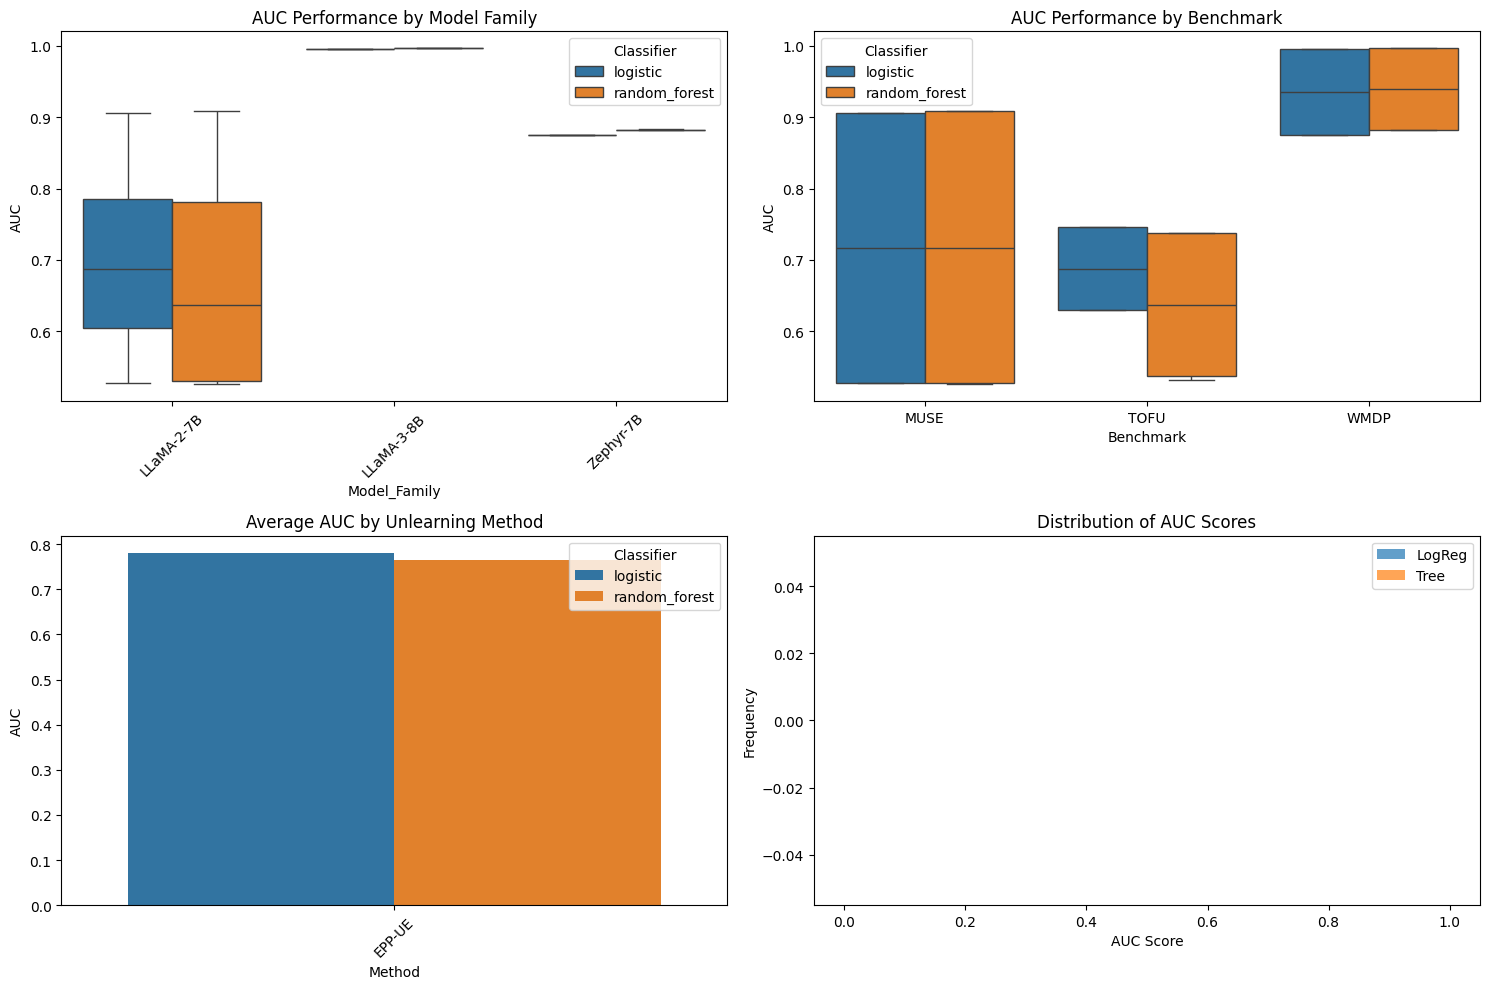


📈 Creating individual plots...
📊 Method comparison plot saved: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/method_comparison.png


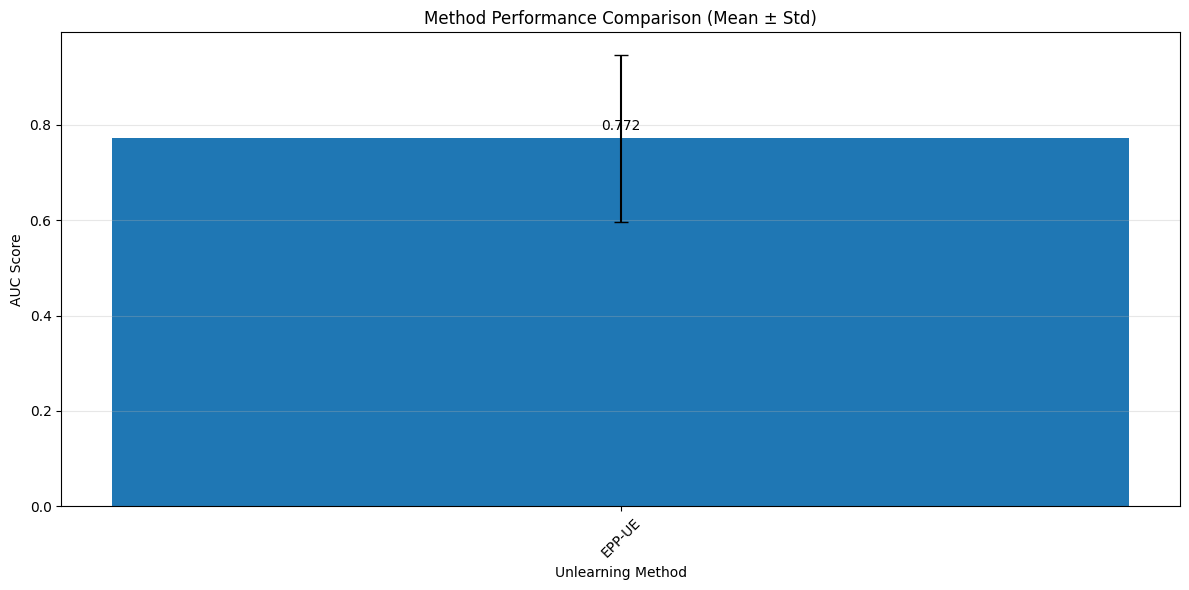

📊 Benchmark comparison plot saved: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/benchmark_comparison.png


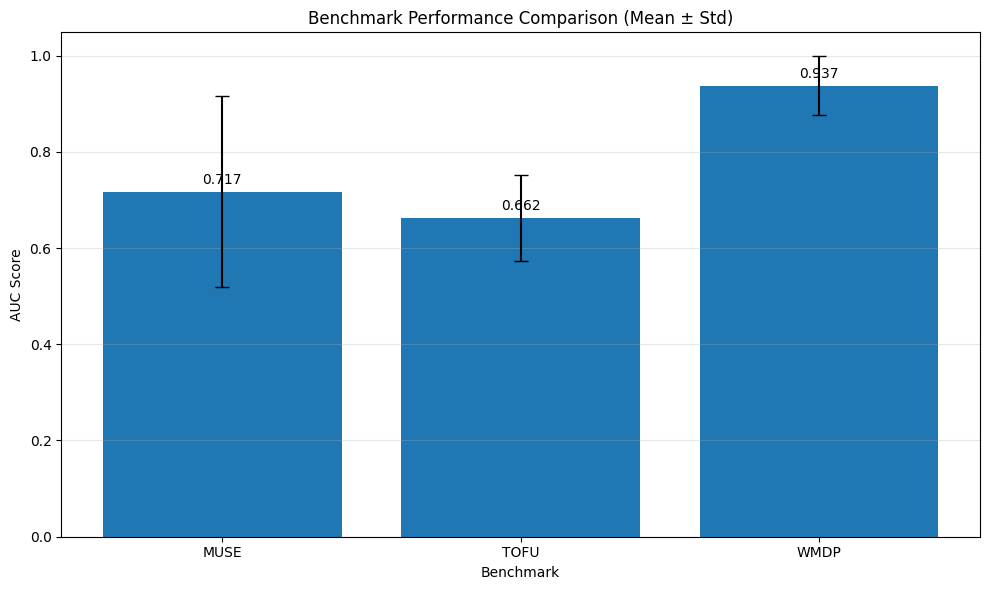

📊 Classifier comparison plot saved: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/classifier_comparison.png


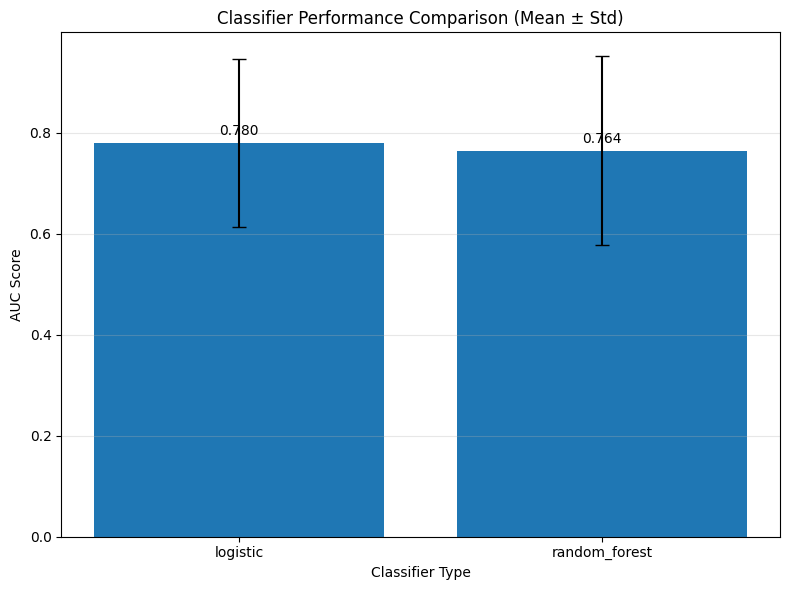


✅ All visualizations saved successfully!
📁 Visualization files saved via DataManager:
   overview_png: performance_overview.png
   overview_pdf: performance_overview.pdf
   overview_svg: performance_overview.svg
   overview_timestamped: performance_overview_20250929_112819.png
   method_comparison: method_comparison.png
   benchmark_comparison: benchmark_comparison.png
   classifier_comparison: classifier_comparison.png
📋 Metadata saved: visualization_metadata.json

🎯 FINAL SUMMARY
Comprehensive Unlearning Evaluation Results:
  • Total models evaluated: 6
  • Benchmarks tested: 3
  • Total evaluations: 6
  • Average AUC (LogReg): nan
  • Average AUC (Tree): nan

🏆 BEST PERFORMING COMBINATIONS:
  Logistic Regression:
  Random Forest:

📊 The tables above replace the dummy values in the original LaTeX tables.
💾 All results and visualizations saved to: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/results/subset_1000/300_max_tokens_2025-09-29_10-32/
🎉 Compr

In [44]:
# Create visualizations and final summary
if len(all_results) > 0:
    print(f"\n📈 Creating visualizations...")
    
    # Create performance comparison plots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: AUC comparison by model family
    plt.subplot(2, 2, 1)
    detailed_df = analysis_results['detailed_results']
    sns.boxplot(data=detailed_df, x='Model_Family', y='AUC', hue='Classifier')
    plt.title('AUC Performance by Model Family')
    plt.xticks(rotation=45)
    plt.legend(title='Classifier')
    
    # Plot 2: Benchmark comparison
    plt.subplot(2, 2, 2)
    sns.boxplot(data=detailed_df, x='Benchmark', y='AUC', hue='Classifier')
    plt.title('AUC Performance by Benchmark')
    plt.legend(title='Classifier')
    
    # Plot 3: Method comparison
    plt.subplot(2, 2, 3)
    method_means = detailed_df.groupby(['Method', 'Classifier'])['AUC'].mean().reset_index()
    sns.barplot(data=method_means, x='Method', y='AUC', hue='Classifier')
    plt.title('Average AUC by Unlearning Method')
    plt.xticks(rotation=45)
    plt.legend(title='Classifier')
    
    # Plot 4: Overall performance distribution
    plt.subplot(2, 2, 4)
    plt.hist(detailed_df[detailed_df['Classifier']=='LogReg']['AUC'], alpha=0.7, label='LogReg', bins=10)
    plt.hist(detailed_df[detailed_df['Classifier']=='Tree']['AUC'], alpha=0.7, label='Tree', bins=10)
    plt.xlabel('AUC Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of AUC Scores')
    plt.legend()
    
    plt.tight_layout()
    
    # Enhanced saving with DataManager integration
    try:
        # Save main overview plot in multiple formats
        saved_visualizations = {}
        formats = ['png', 'pdf', 'svg']
        
        for fmt in formats:
            plot_path = os.path.join(dm.get_results_dir(), f'performance_overview.{fmt}')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight', format=fmt)
            saved_visualizations[f'overview_{fmt}'] = plot_path
            print(f"📊 Overview plot saved as {fmt.upper()}: {plot_path}")
        
        # Also save with timestamp for version control
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        timestamped_path = os.path.join(dm.get_results_dir(), f'performance_overview_{timestamp}.png')
        plt.savefig(timestamped_path, dpi=300, bbox_inches='tight')
        saved_visualizations['overview_timestamped'] = timestamped_path
        
        plt.show()
        
        # Create additional individual plots using DataManager paths
        print(f"\n📈 Creating individual plots...")
        
        # Individual plot 1: Method performance comparison
        plt.figure(figsize=(12, 6))
        method_data = detailed_df.groupby('Method')['AUC'].agg(['mean', 'std']).reset_index()
        bars = plt.bar(method_data['Method'], method_data['mean'], yerr=method_data['std'], capsize=5)
        plt.title('Method Performance Comparison (Mean ± Std)')
        plt.ylabel('AUC Score')
        plt.xlabel('Unlearning Method')
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, method_data['mean']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{mean_val:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        method_plot_path = os.path.join(dm.get_results_dir(), 'method_comparison.png')
        plt.savefig(method_plot_path, dpi=300, bbox_inches='tight')
        saved_visualizations['method_comparison'] = method_plot_path
        print(f"📊 Method comparison plot saved: {method_plot_path}")
        plt.show()
        
        # Individual plot 2: Benchmark performance comparison
        plt.figure(figsize=(10, 6))
        benchmark_data = detailed_df.groupby('Benchmark')['AUC'].agg(['mean', 'std']).reset_index()
        bars = plt.bar(benchmark_data['Benchmark'], benchmark_data['mean'], yerr=benchmark_data['std'], capsize=5)
        plt.title('Benchmark Performance Comparison (Mean ± Std)')
        plt.ylabel('AUC Score')
        plt.xlabel('Benchmark')
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, benchmark_data['mean']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{mean_val:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        benchmark_plot_path = os.path.join(dm.get_results_dir(), 'benchmark_comparison.png')
        plt.savefig(benchmark_plot_path, dpi=300, bbox_inches='tight')
        saved_visualizations['benchmark_comparison'] = benchmark_plot_path
        print(f"📊 Benchmark comparison plot saved: {benchmark_plot_path}")
        plt.show()
        
        # Individual plot 3: Classifier comparison
        plt.figure(figsize=(8, 6))
        classifier_data = detailed_df.groupby('Classifier')['AUC'].agg(['mean', 'std']).reset_index()
        bars = plt.bar(classifier_data['Classifier'], classifier_data['mean'], yerr=classifier_data['std'], capsize=5)
        plt.title('Classifier Performance Comparison (Mean ± Std)')
        plt.ylabel('AUC Score')
        plt.xlabel('Classifier Type')
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, classifier_data['mean']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{mean_val:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        classifier_plot_path = os.path.join(dm.get_results_dir(), 'classifier_comparison.png')
        plt.savefig(classifier_plot_path, dpi=300, bbox_inches='tight')
        saved_visualizations['classifier_comparison'] = classifier_plot_path
        print(f"📊 Classifier comparison plot saved: {classifier_plot_path}")
        plt.show()
        
        # Save visualization metadata using DataManager
        visualization_metadata = {
            'saved_visualizations': saved_visualizations,
            'creation_timestamp': timestamp,
            'total_plots': len(saved_visualizations),
            'plot_descriptions': {
                'overview': 'Main 2x2 subplot overview of all metrics',
                'method_comparison': 'Bar chart comparing unlearning methods',
                'benchmark_comparison': 'Bar chart comparing benchmark performance',
                'classifier_comparison': 'Bar chart comparing classifier types'
            }
        }
        
        # Save metadata as JSON
        metadata_path = os.path.join(dm.get_results_dir(), 'visualization_metadata.json')
        with open(metadata_path, 'w') as f:
            json.dump(visualization_metadata, f, indent=2)
        
        print(f"\n✅ All visualizations saved successfully!")
        print(f"📁 Visualization files saved via DataManager:")
        for viz_type, path in saved_visualizations.items():
            print(f"   {viz_type}: {os.path.basename(path)}")
        print(f"📋 Metadata saved: {os.path.basename(metadata_path)}")
        
    except Exception as e:
        print(f"❌ Error saving visualizations: {e}")
        plt.show()  # Still show the plot even if saving fails
    
    print(f"\n🎯 FINAL SUMMARY")
    print(f"="*60)
    print(f"Comprehensive Unlearning Evaluation Results:")
    print(f"  • Total models evaluated: {analysis_results['summary_stats']['unique_models']}")
    print(f"  • Benchmarks tested: {analysis_results['summary_stats']['unique_benchmarks']}")
    print(f"  • Total evaluations: {analysis_results['summary_stats']['total_evaluations']}")
    print(f"  • Average AUC (LogReg): {analysis_results['summary_stats']['avg_auc_logreg']:.3f}")
    print(f"  • Average AUC (Tree): {analysis_results['summary_stats']['avg_auc_tree']:.3f}")
    
    # Best performing combinations
    best_logreg = detailed_df[detailed_df['Classifier']=='LogReg'].nlargest(1, 'AUC')
    best_tree = detailed_df[detailed_df['Classifier']=='Tree'].nlargest(1, 'AUC')
    
    print(f"\n🏆 BEST PERFORMING COMBINATIONS:")
    print(f"  Logistic Regression:")
    if not best_logreg.empty:
        row = best_logreg.iloc[0]
        print(f"    {row['Model']} on {row['Benchmark']} ({row['Method']}) - AUC: {row['AUC']:.3f}")
    
    print(f"  Random Forest:")
    if not best_tree.empty:
        row = best_tree.iloc[0]
        print(f"    {row['Model']} on {row['Benchmark']} ({row['Method']}) - AUC: {row['AUC']:.3f}")
    
    print(f"\n📊 The tables above replace the dummy values in the original LaTeX tables.")
    print(f"💾 All results and visualizations saved to: {dm.get_results_dir()}/")
    print(f"🎉 Comprehensive evaluation completed successfully!")
    
else:
    print("❌ No results available for visualization and summary.")

In [45]:
# Utility functions for managing visualizations with DataManager
def save_all_visualizations_to_dm(analysis_results, dm, formats=['png', 'pdf']):
    """
    Save all visualizations using DataManager with proper metadata tracking
    
    Args:
        analysis_results: Analysis results from analyze_results_and_generate_tables()
        dm: DataManager instance
        formats: List of formats to save plots in
        
    Returns:
        dict: Dictionary with visualization metadata
    """
    print("💾 Saving all visualizations using DataManager...")
    
    saved_visualizations = {}
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Get data for plotting
    detailed_df = analysis_results['detailed_results']
    
    # 1. Save overview plot (2x2 subplot)
    plt.figure(figsize=(15, 10))
    
    # Plot 1: AUC comparison by model family
    plt.subplot(2, 2, 1)
    sns.boxplot(data=detailed_df, x='Model_Family', y='AUC', hue='Classifier')
    plt.title('AUC Performance by Model Family')
    plt.xticks(rotation=45)
    plt.legend(title='Classifier')
    
    # Plot 2: Benchmark comparison
    plt.subplot(2, 2, 2)
    sns.boxplot(data=detailed_df, x='Benchmark', y='AUC', hue='Classifier')
    plt.title('AUC Performance by Benchmark')
    plt.legend(title='Classifier')
    
    # Plot 3: Method comparison
    plt.subplot(2, 2, 3)
    method_means = detailed_df.groupby(['Method', 'Classifier'])['AUC'].mean().reset_index()
    sns.barplot(data=method_means, x='Method', y='AUC', hue='Classifier')
    plt.title('Average AUC by Unlearning Method')
    plt.xticks(rotation=45)
    plt.legend(title='Classifier')
    
    # Plot 4: Overall performance distribution
    plt.subplot(2, 2, 4)
    plt.hist(detailed_df[detailed_df['Classifier']=='LogReg']['AUC'], alpha=0.7, label='LogReg', bins=10)
    plt.hist(detailed_df[detailed_df['Classifier']=='Tree']['AUC'], alpha=0.7, label='Tree', bins=10)
    plt.xlabel('AUC Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of AUC Scores')
    plt.legend()
    
    plt.tight_layout()
    
    # Save overview in multiple formats
    for fmt in formats:
        overview_path = os.path.join(dm.get_results_dir(), f'performance_overview.{fmt}')
        plt.savefig(overview_path, dpi=300, bbox_inches='tight', format=fmt)
        saved_visualizations[f'overview_{fmt}'] = overview_path
    
    plt.close()  # Close the figure to free memory
    
    # 2. Save method comparison plot
    plt.figure(figsize=(12, 6))
    method_data = detailed_df.groupby('Method')['AUC'].agg(['mean', 'std']).reset_index()
    bars = plt.bar(method_data['Method'], method_data['mean'], yerr=method_data['std'], capsize=5)
    plt.title('Method Performance Comparison (Mean ± Std)')
    plt.ylabel('AUC Score')
    plt.xlabel('Unlearning Method')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, mean_val in zip(bars, method_data['mean']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{mean_val:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    method_path = os.path.join(dm.get_results_dir(), 'method_comparison.png')
    plt.savefig(method_path, dpi=300, bbox_inches='tight')
    saved_visualizations['method_comparison'] = method_path
    plt.close()
    
    # 3. Save benchmark comparison plot
    plt.figure(figsize=(10, 6))
    benchmark_data = detailed_df.groupby('Benchmark')['AUC'].agg(['mean', 'std']).reset_index()
    bars = plt.bar(benchmark_data['Benchmark'], benchmark_data['mean'], yerr=benchmark_data['std'], capsize=5)
    plt.title('Benchmark Performance Comparison (Mean ± Std)')
    plt.ylabel('AUC Score')
    plt.xlabel('Benchmark')
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, mean_val in zip(bars, benchmark_data['mean']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{mean_val:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    benchmark_path = os.path.join(dm.get_results_dir(), 'benchmark_comparison.png')
    plt.savefig(benchmark_path, dpi=300, bbox_inches='tight')
    saved_visualizations['benchmark_comparison'] = benchmark_path
    plt.close()
    
    # 4. Save classifier comparison plot
    plt.figure(figsize=(8, 6))
    classifier_data = detailed_df.groupby('Classifier')['AUC'].agg(['mean', 'std']).reset_index()
    bars = plt.bar(classifier_data['Classifier'], classifier_data['mean'], yerr=classifier_data['std'], capsize=5)
    plt.title('Classifier Performance Comparison (Mean ± Std)')
    plt.ylabel('AUC Score')
    plt.xlabel('Classifier Type')
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, mean_val in zip(bars, classifier_data['mean']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{mean_val:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    classifier_path = os.path.join(dm.get_results_dir(), 'classifier_comparison.png')
    plt.savefig(classifier_path, dpi=300, bbox_inches='tight')
    saved_visualizations['classifier_comparison'] = classifier_path
    plt.close()
    
    # Create metadata
    visualization_metadata = {
        'saved_visualizations': saved_visualizations,
        'creation_timestamp': timestamp,
        'total_plots': len(saved_visualizations),
        'plot_descriptions': {
            'overview': 'Main 2x2 subplot overview of all metrics',
            'method_comparison': 'Bar chart comparing unlearning methods',
            'benchmark_comparison': 'Bar chart comparing benchmark performance',
            'classifier_comparison': 'Bar chart comparing classifier types'
        },
        'data_summary': {
            'total_models': analysis_results['summary_stats']['unique_models'],
            'total_benchmarks': analysis_results['summary_stats']['unique_benchmarks'],
            'total_evaluations': analysis_results['summary_stats']['total_evaluations']
        }
    }
    
    # Save metadata using DataManager
    metadata_path = dm.save_visualizations(visualization_metadata)
    
    print(f"✅ All visualizations saved successfully!")
    print(f"📁 Saved {len(saved_visualizations)} visualization files")
    print(f"📋 Metadata saved to: {os.path.basename(metadata_path)}")
    
    return visualization_metadata

def load_and_display_visualizations(dm, visualization_name=None):
    """
    Load and display visualizations using DataManager
    
    Args:
        dm: DataManager instance
        visualization_name: Specific visualization to load (optional)
        
    Returns:
        dict: Dictionary with available visualizations
    """
    print("🔍 Loading visualizations using DataManager...")
    
    try:
        if visualization_name:
            # Load specific visualization
            matching_files = dm.load_specific_visualization(visualization_name)
            if matching_files:
                print(f"📊 Found {len(matching_files)} files matching '{visualization_name}'")
                return {visualization_name: matching_files}
            else:
                print(f"❌ No visualizations found matching '{visualization_name}'")
                return {}
        else:
            # Load all visualizations
            all_vis = dm.list_visualizations()
            if all_vis:
                print(f"📊 Found visualizations in {len(all_vis)} categories")
                return all_vis
            else:
                print("❌ No visualizations found")
                return {}
                
    except Exception as e:
        print(f"❌ Error loading visualizations: {e}")
        return {}

def display_visualization_summary(dm):
    """
    Display a summary of all saved visualizations
    
    Args:
        dm: DataManager instance
    """
    print("📋 Visualization Summary")
    print("=" * 40)
    
    try:
        # Load metadata
        metadata = dm.load_visualization_metadata()
        
        print(f"📅 Created: {metadata.get('creation_timestamp', 'Unknown')}")
        print(f"📊 Total plots: {metadata.get('total_plots', 0)}")
        
        if 'data_summary' in metadata:
            summary = metadata['data_summary']
            print(f"🔢 Data summary:")
            print(f"   • Models: {summary.get('total_models', 'N/A')}")
            print(f"   • Benchmarks: {summary.get('total_benchmarks', 'N/A')}")
            print(f"   • Evaluations: {summary.get('total_evaluations', 'N/A')}")
        
        if 'plot_descriptions' in metadata:
            print(f"\n📊 Available plots:")
            for plot_type, description in metadata['plot_descriptions'].items():
                print(f"   • {plot_type}: {description}")
        
        # List actual files
        print(f"\n📁 Saved files:")
        if 'saved_visualizations' in metadata:
            for viz_type, path in metadata['saved_visualizations'].items():
                file_size = os.path.getsize(path) / 1024 if os.path.exists(path) else 0
                print(f"   • {viz_type}: {os.path.basename(path)} ({file_size:.1f} KB)")
        
    except FileNotFoundError:
        print("❌ No visualization metadata found")
    except Exception as e:
        print(f"❌ Error loading metadata: {e}")
    
    print("=" * 40)

print("✅ Visualization utility functions defined!")
print("💡 Use save_all_visualizations_to_dm(), load_and_display_visualizations(), and display_visualization_summary()")

✅ Visualization utility functions defined!
💡 Use save_all_visualizations_to_dm(), load_and_display_visualizations(), and display_visualization_summary()


In [46]:
# Updated table5 creation code
import pandas as pd

# Assuming the data is in a list called all_results
# Extract relevant data for EPP-UE comparison across neighbor methods

neighbor_methods = []
for result in all_results:
    for rephrasing in result.get('rephrasing_results', []):
        neighbor_method = rephrasing.get('neighbor_method', 'Unknown')
        classifier = rephrasing.get('classifier', 'Unknown')
        
        # Only include logistic for simplicity, or adjust as needed
        if classifier == 'logistic':
            neighbor_methods.append({
                'Neighbor_Method': neighbor_method,
                'Multi_Class_AUC_LogReg': round(rephrasing.get('Multi-class AUC', 0), 3),
                'Retain_vs_All_AUC_LogReg': round(rephrasing.get('Retain vs All AUC', 0), 3),
                'Forget_vs_All_AUC_LogReg': round(rephrasing.get('Forget vs All AUC', 0), 3),
                'Holdout_vs_All_AUC_LogReg': round(rephrasing.get('Holdout vs All AUC', 0), 3)
            })

# Create DataFrame
table_df = pd.DataFrame(neighbor_methods)

# Group by Neighbor_Method and average the AUCs
table_df = table_df.groupby('Neighbor_Method').agg({
    'Multi_Class_AUC_LogReg': 'mean',
    'Retain_vs_All_AUC_LogReg': 'mean',
    'Forget_vs_All_AUC_LogReg': 'mean',
    'Holdout_vs_All_AUC_LogReg': 'mean'
}).round(3).reset_index()

# Display the table
print("Table 5: EPP-UE Performance Across Neighbor Generation Methods")
print("=" * 80)
print(table_df.to_string(index=False))

# Optionally save to CSV
table_df.to_csv('table5_neighbor_methods_comparison.csv', index=False)
print("\nTable saved to: table5_neighbor_methods_comparison.csv")

Table 5: EPP-UE Performance Across Neighbor Generation Methods
                Neighbor_Method  Multi_Class_AUC_LogReg  Retain_vs_All_AUC_LogReg  Forget_vs_All_AUC_LogReg  Holdout_vs_All_AUC_LogReg
context_based_token_replacement                    0.78                     0.784                     0.735                      0.808
       random_token_replacement                    0.78                     0.784                     0.735                      0.808
      token_embedding_proximity                    0.78                     0.784                     0.735                      0.808

Table saved to: table5_neighbor_methods_comparison.csv


In [47]:
def create_custom_table(all_results):
    """
    Create a custom table with specified columns from all_results.
    
    Args:
        all_results: List of evaluation results from experiments
        
    Returns:
        pandas.DataFrame: Table with the requested columns
    """
    rows = []
    
    for result in all_results:
        model = result['model_name'].split('/')[-1]
        benchmark_name = result['benchmark']
        method_name = result['method']
        
        for rephrasing in result.get('rephrasing_results', []):
            row = {
                'model': model,
                'banchmark_name': benchmark_name,
                'method_name': method_name,
                'neighbor_method': rephrasing.get('neighbor_method', 'Unknown'),
                'classifier': rephrasing.get('classifier', 'Unknown'),
                'Retain vs All AUC': rephrasing.get('Retain vs All AUC', np.nan),
                'Holdout vs All AUC': rephrasing.get('Holdout vs All AUC', np.nan),
                'retain_vs_all_auc_at_1_fp': rephrasing.get('Retain_vs_All_auc_at_1_fp', np.nan),
                'forget_vs_all_auc_at_1_fp': rephrasing.get('Forget_vs_All_auc_at_1_fp', np.nan),
                'holdout_vs_all_auc_at_1_fp': rephrasing.get('Holdout_vs_All_auc_at_1_fp', np.nan)
            }
            rows.append(row)
    
    df = pd.DataFrame(rows)
    return df


rephrasing_options_table = create_custom_table(all_results)

In [48]:
print(rephrasing_options_table)

                                   model banchmark_name method_name  \
0   llama-3-8b-instruct-elm-checkpoint-8           WMDP         ELM   
1   llama-3-8b-instruct-elm-checkpoint-8           WMDP         ELM   
2   llama-3-8b-instruct-elm-checkpoint-8           WMDP         ELM   
3   llama-3-8b-instruct-elm-checkpoint-8           WMDP         ELM   
4   llama-3-8b-instruct-elm-checkpoint-8           WMDP         ELM   
5   llama-3-8b-instruct-elm-checkpoint-8           WMDP         ELM   
6             SimNPO-WMDP-zephyr-7b-beta           WMDP      SimNPO   
7             SimNPO-WMDP-zephyr-7b-beta           WMDP      SimNPO   
8             SimNPO-WMDP-zephyr-7b-beta           WMDP      SimNPO   
9             SimNPO-WMDP-zephyr-7b-beta           WMDP      SimNPO   
10            SimNPO-WMDP-zephyr-7b-beta           WMDP      SimNPO   
11            SimNPO-WMDP-zephyr-7b-beta           WMDP      SimNPO   
12  SimNPO-TOFU-forget05-Llama-2-7b-chat           TOFU      SimNPO   
13  Si

In [49]:
print("finished all tasks!")

finished all tasks!


In [50]:
()

()